<a href="https://colab.research.google.com/github/mcamacho339-cpu/ESTADISTICA-/blob/main/REGRESIONLINEAL_TALLER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


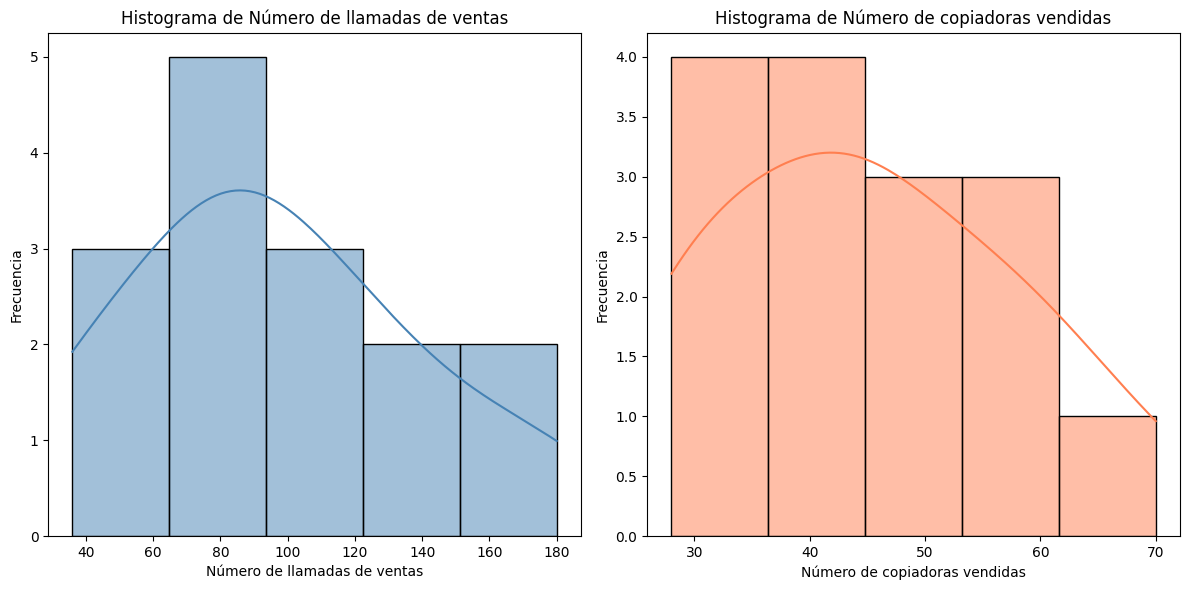

------------------------------
Generating Scatter Plot...


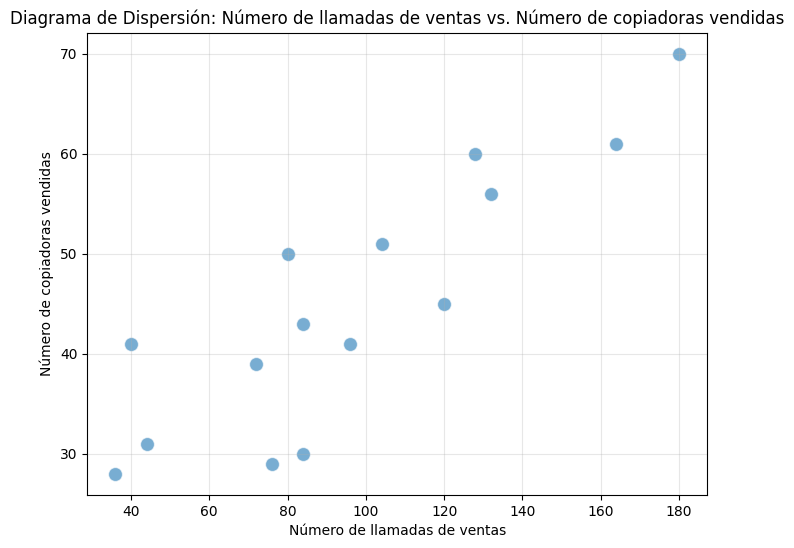

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

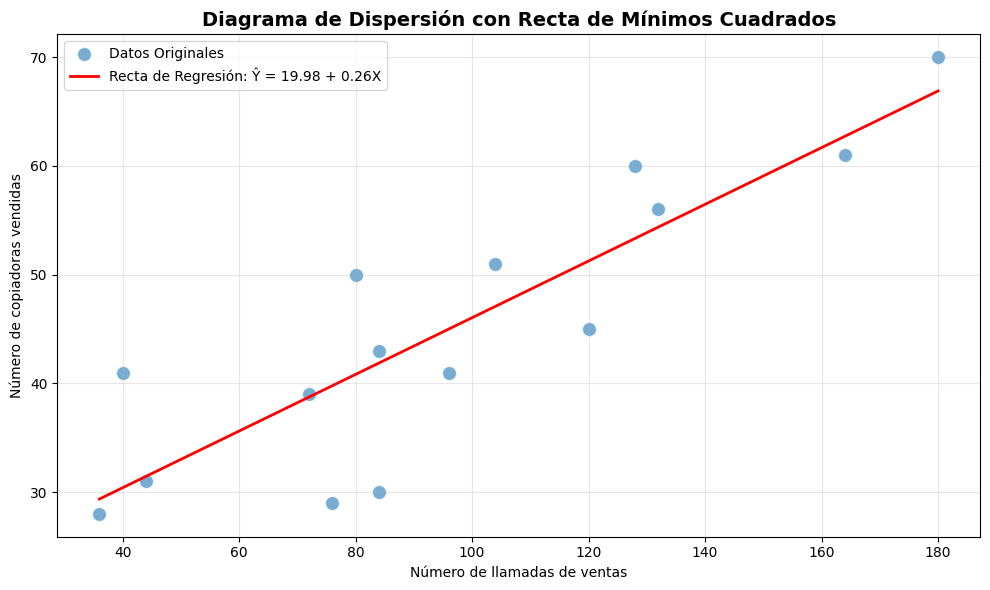


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

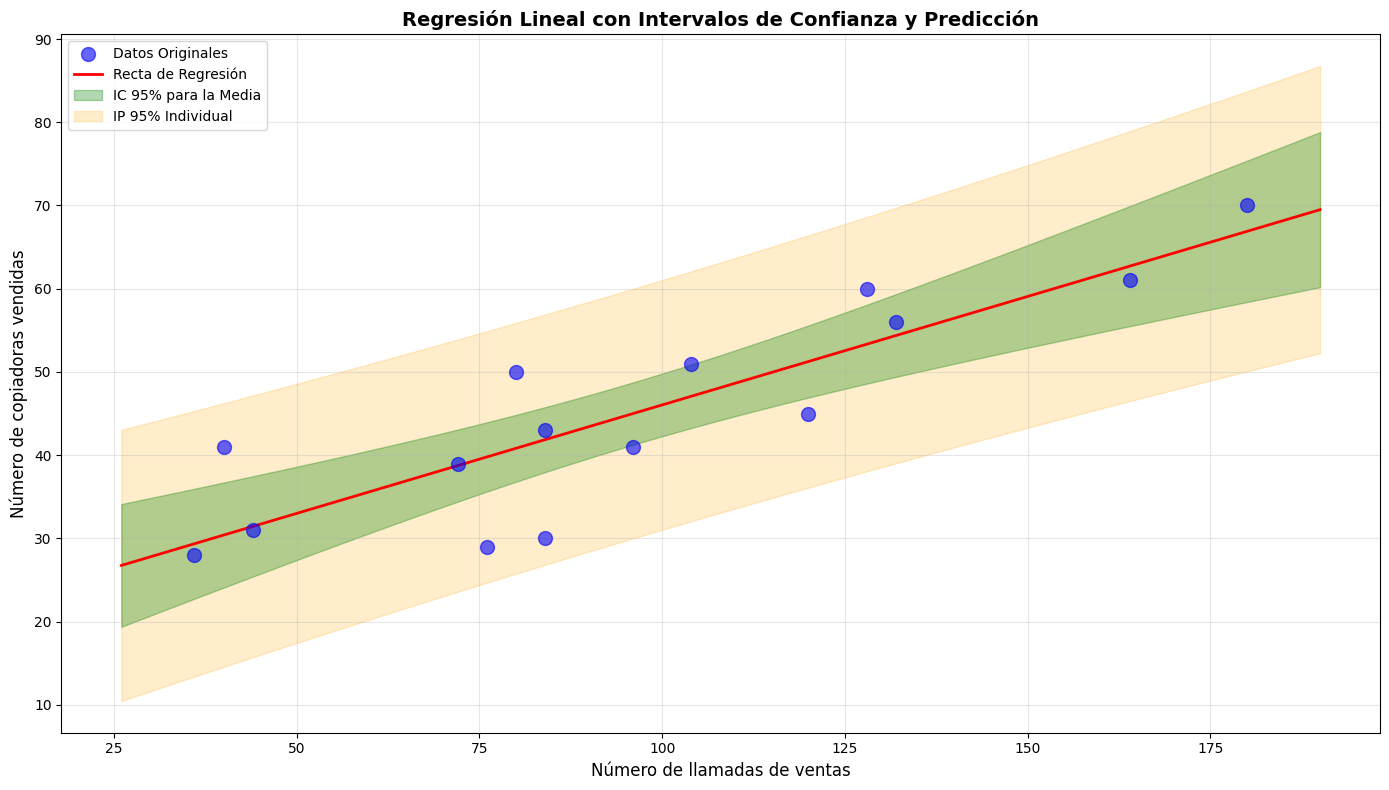

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

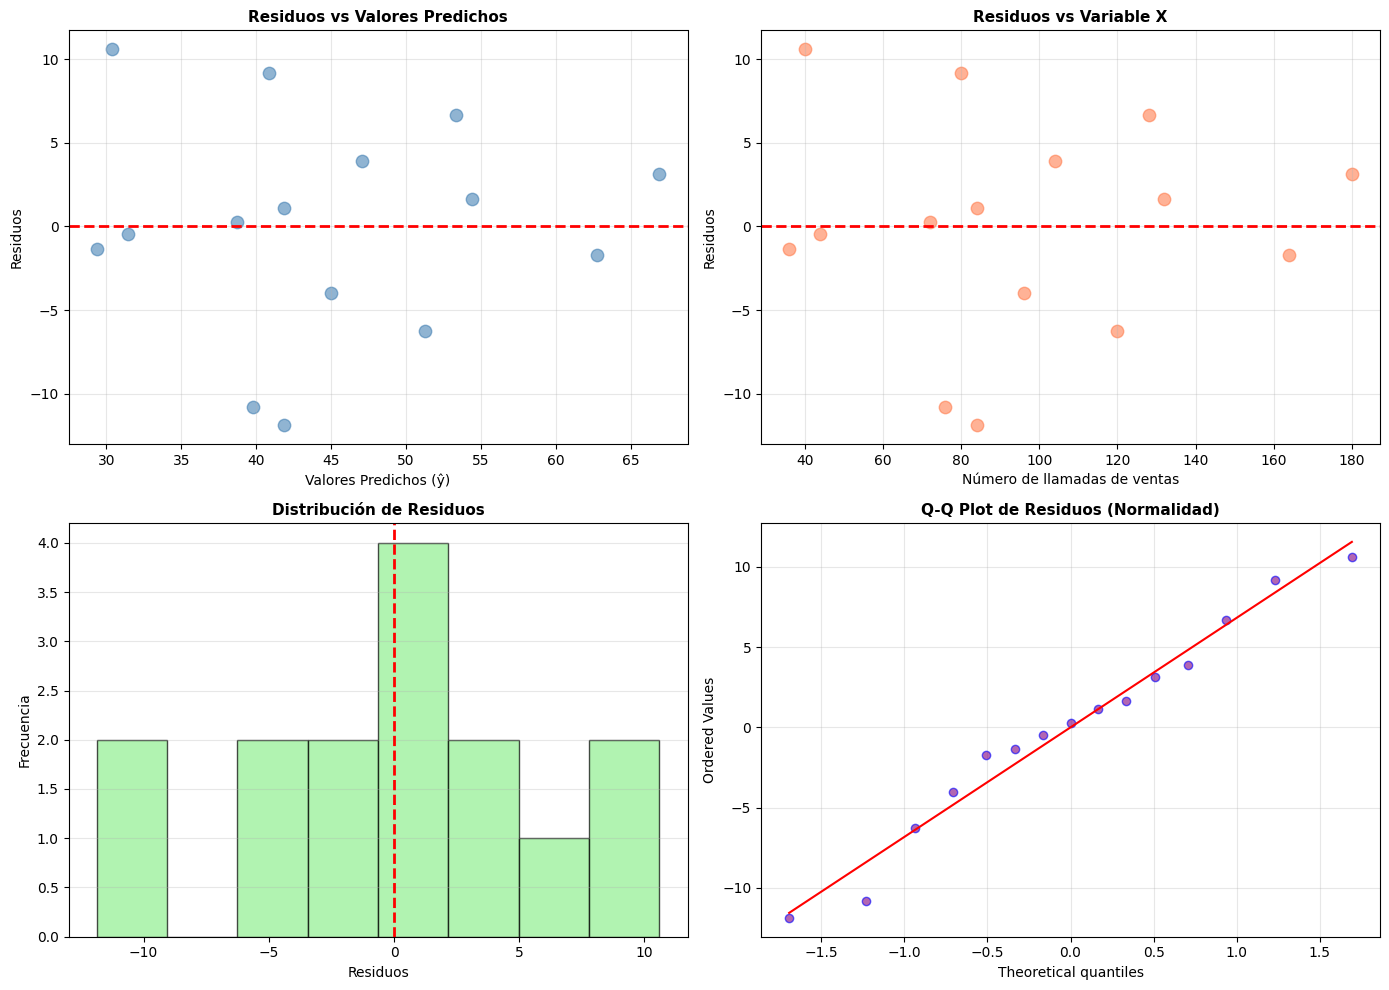


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)


PRIMER EJERCICIO

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Goles de Equipos de Fútbol

Datos cargados: 6 equipos de fútbol
Variable independiente (X): Goles anotados (X)
Variable dependiente (Y): Goles recibidos (Y)
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


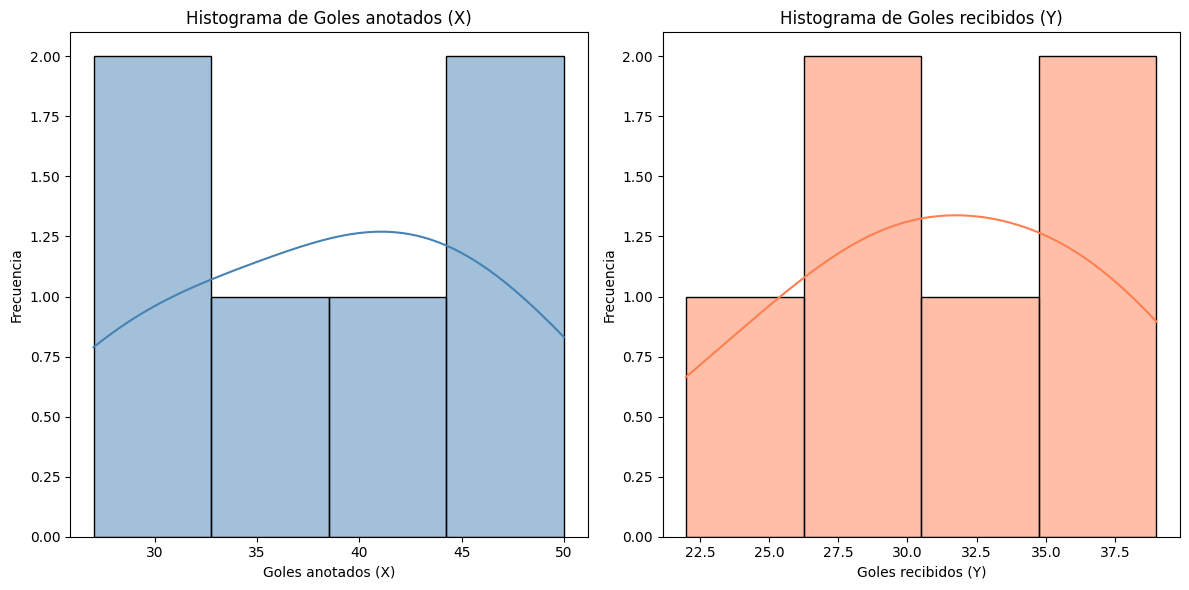

------------------------------
Generating Scatter Plot...


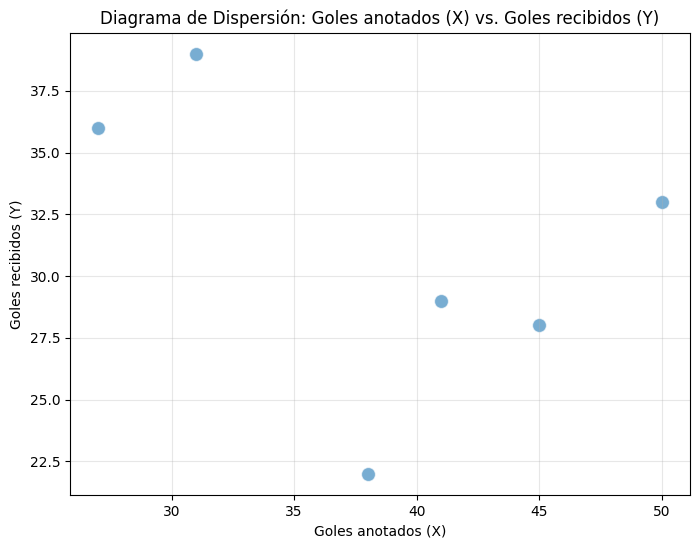

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Goles anotados (X)': Statistics=0.976, p-value=0.928
Shapiro-Wilk test for 'Goles recibidos (Y)': Statistics=0.980, p-value=0.950

Interpretation of normality test results:
✓ The 'Goles anotados (X)' variable appears to be normally distributed (p > 0.05).
✓ The 'Goles recibidos (Y)' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: -0.4365
Kendall correlation coefficient: -0.2000
Spearman correlation coefficient: -0.4286
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (-0.4365) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

Hipótesis:
H0: ρ = 0 (No existe corre

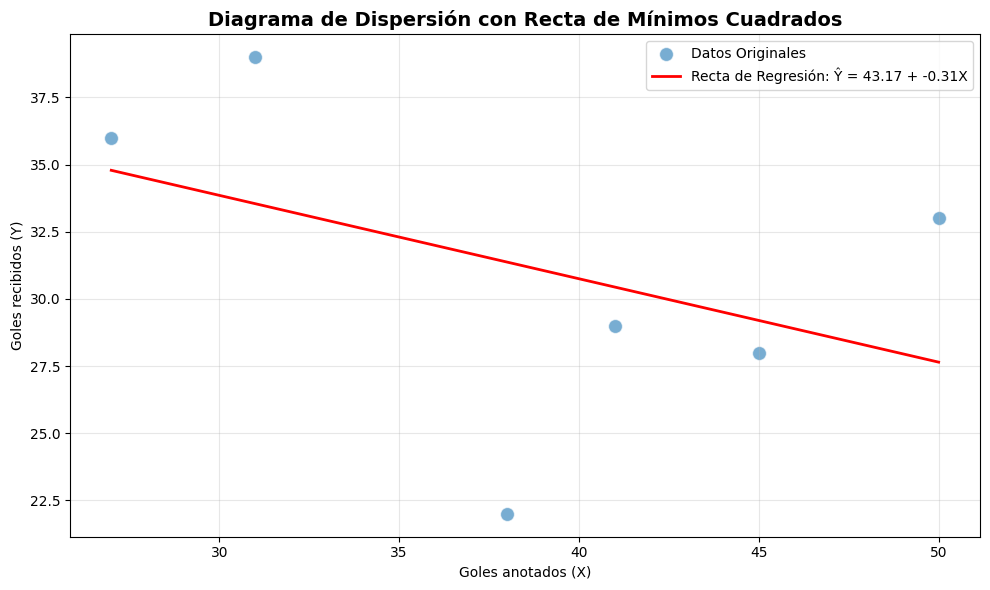


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β < 0 (Existe una relación lineal negativa significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 151.2329
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.1488

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 369.3333
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.3200

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (-0.3105 - 0) / 0.3200
   t calculado = -0.9704

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 4
   Valor crítico (t_0.05,4) = -2.1318
   Valor p (una cola) = 0.1934

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (-0.9704) > t crítico (-2.1318)
valor p (0.1934) ≥ α (0.05)

DECISIÓN: NO RECHAZAR H0
INTERPRETACIÓN: ✗ La pendiente NO es significativamente 

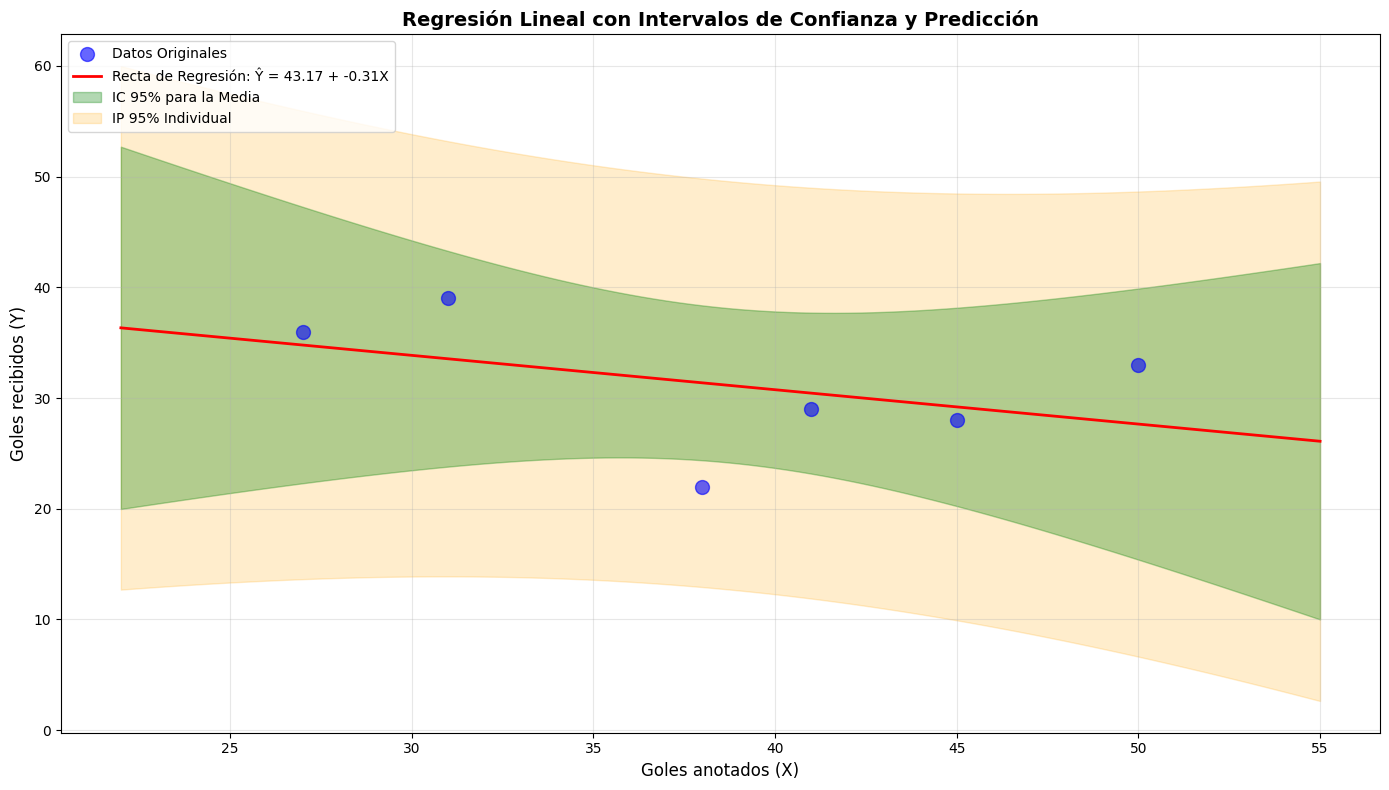

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Equipo             X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Leones             38       22       31.37    -9.37      -1.52     
Águilas            45       28       29.20    -1.20      -0.20     
Tigres             31       39       33.55    5.45       0.89      
Toros              50       33       27.65    5.35       0.87      
Pumas              27       36       34.79    1.21       0.20      
Jaguares           41       29       30.44    -1.44      -0.23     

Estadísticas de los Residuos:
  Media de residuos: -0.0000 (debe ser ≈ 0)
  Desviación estándar: 5.4997
  Residuo mínimo: -9.3736
  Residuo máximo: 5.4531


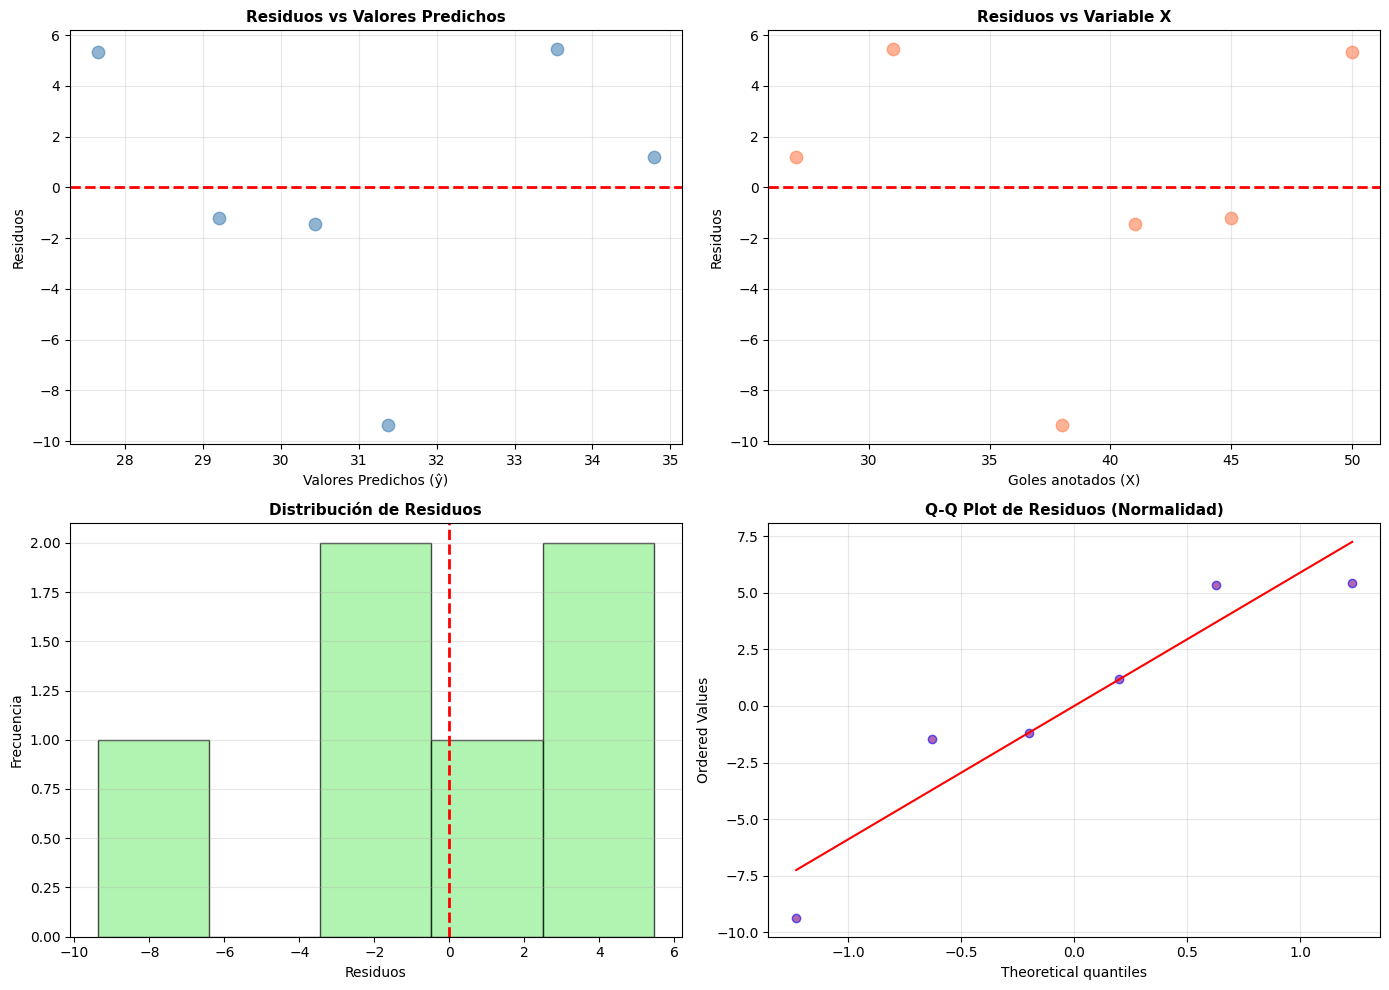


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.8979
  Valor p = 0.3619
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Goles anotados (X): p-value = 0.9283
     ✓ Distribución normal
   • Goles recibidos (Y): p-value = 0.9500
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.3619
     ✓ Distribución normal

3. HOMOCEDASTICIDAD 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- NUEVO DATAFRAME DEL PROBLEMA (GOLES DE EQUIPOS DE FÚTBOL) ---
data = {
    'Equipo': [
        'Leones', 'Águilas', 'Tigres', 'Toros', 'Pumas', 'Jaguares'
    ],
    'Goles anotados (X)': [
        38, 45, 31, 50, 27, 41
    ],
    'Goles recibidos (Y)': [
        22, 28, 39, 33, 36, 29
    ]
}
df = pd.DataFrame(data)

variable_x = 'Goles anotados (X)'
variable_y = 'Goles recibidos (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Goles de Equipos de Fútbol")
print("=" * 70)
print(f"\nDatos cargados: {n} equipos de fútbol")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r**2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Goles anotados) y Y (Goles recibidos)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero) -- Adaptar hipótesis según relación esperada (positiva o negativa)
print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β < 0 (Existe una relación lineal negativa significativa)") # Modificado para relación esperada entre goles anotados y recibidos

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola izquierda para H1: β < 0)
t_critico_pendiente = t.ppf(alfa, gl_pendiente) # Modificado para cola izquierda

# Valor p (prueba de una cola)
valor_p_pendiente = t.cdf(t_calculado_pendiente, gl_pendiente) # Modificado para cola izquierda

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa: # Criterio para cola izquierda
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero (negativa)." # Interpretación ajustada
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de goles anotados tiene un efecto significativo NEGATIVO sobre
    el número de goles recibidos.

    En términos prácticos: Por cada gol anotado adicional, se espera una
    disminución de {-b1:.4f} goles recibidos, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero (negativa)." # Interpretación ajustada
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de goles
    anotados tenga un efecto significativo NEGATIVO sobre el número de goles recibidos.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'<' if t_calculado_pendiente < t_critico_pendiente else '>' if t_calculado_pendiente > t_critico_pendiente else '='} t crítico ({t_critico_pendiente:.4f})") # Comparación ajustada
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  goles recibidos puede ser explicada por el número              │")
print(f"│  de goles anotados por los equipos.                             │") # Interpretación ajustada
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X (goles anotados)
valores_x_ejemplo = [30, 40, 50]  # Ejemplos de goles anotados

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de goles recibidos:\n") # Texto ajustado
print(f"{'X (Goles Anotados)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}") # Encabezado ajustado
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando un equipo anota X goles,") # Interpretación ajustada
print("la MEDIA de goles recibidos para equipos similares estará dentro del intervalo calculado.") # Interpretación ajustada

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para goles recibidos INDIVIDUALES:\n") # Texto ajustado
print(f"{'X (Goles Anotados)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}") # Encabezado ajustado
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando un equipo anota X goles,") # Interpretación ajustada
print("la cantidad de goles recibidos por ese equipo estará dentro del intervalo calculado.") # Interpretación ajustada

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 5, df[variable_x].max() + 5, 100) # Ajustar rango si es necesario
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Equipo':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}") # Encabezado ajustado
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Equipo']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}") # Impresión ajustada


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen') # Ajuste de bins
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Equipos con residuos atípicos:") # Texto ajustado
    for idx, row in outliers.iterrows():
        print(f"     - {row['Equipo']}: residuo std = {row['residuos_estandarizados']:.2f}") # Impresión ajustada

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} goles recibidos cuando se anotan 0 goles. # Interpretación ajustada
   • Por cada gol anotado adicional, se espera que los goles recibidos cambien en {b1:.4f}. # Interpretación ajustada

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} goles

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

# Ajustar la conclusión general basada en la prueba de hipótesis de la pendiente y el modelo ANOVA
if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de goles anotados es un predictor SIGNIFICATIVO del
   número de goles recibidos. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Entender la relación entre el rendimiento ofensivo y defensivo de un equipo.
   • Predecir aproximadamente cuántos goles podría recibir un equipo basándose en sus goles anotados.

   Recomendación: Analizar esta relación como parte de la evaluación del rendimiento del equipo.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre goles anotados y goles recibidos, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos (más equipos o temporadas).
   • Considerar otras variables explicativas (ej. calidad de la defensa, liga, etc.).
   • Realizar análisis adicionales antes de sacar conclusiones firmes.
""")


print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


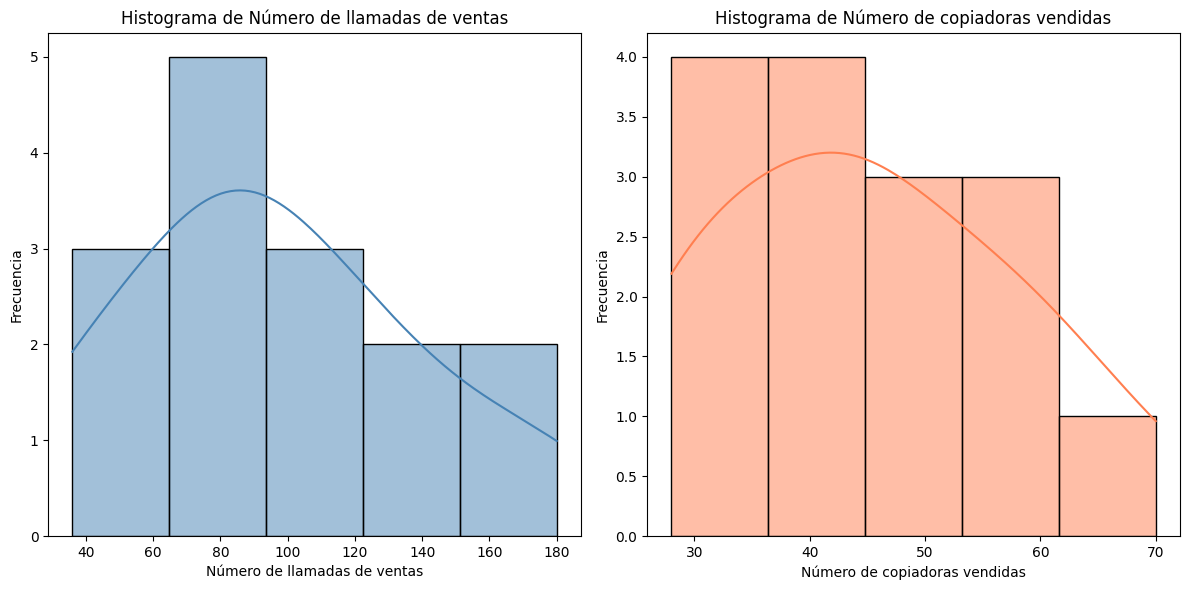

------------------------------
Generating Scatter Plot...


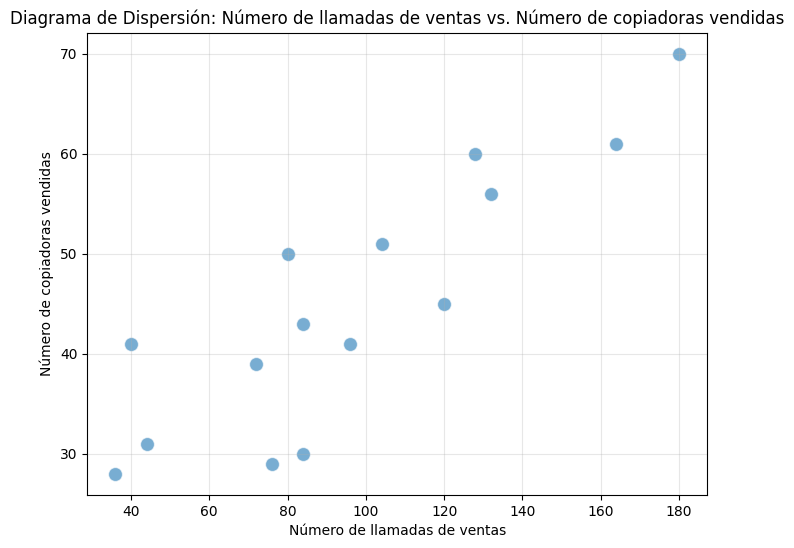

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

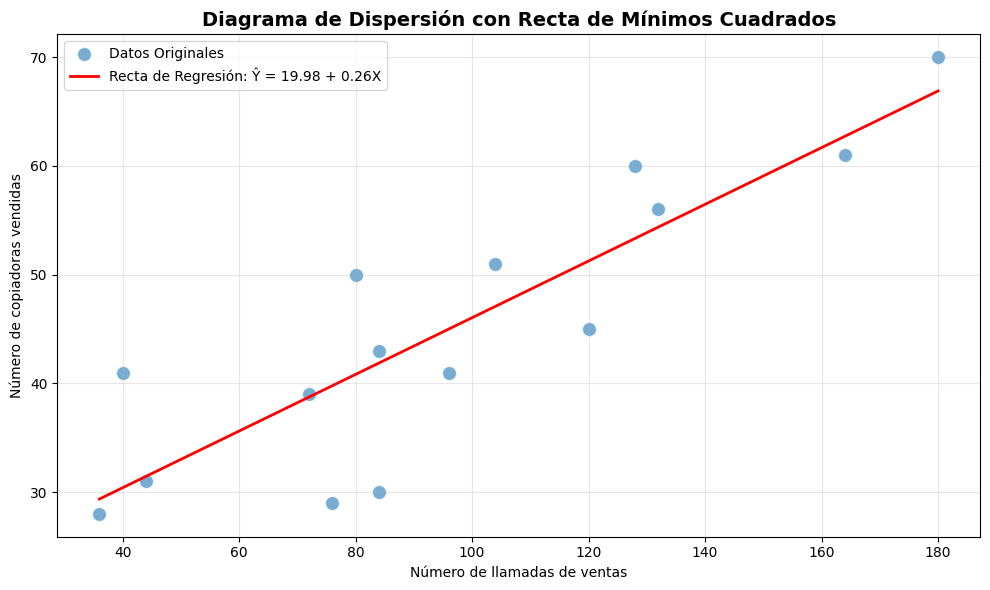


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

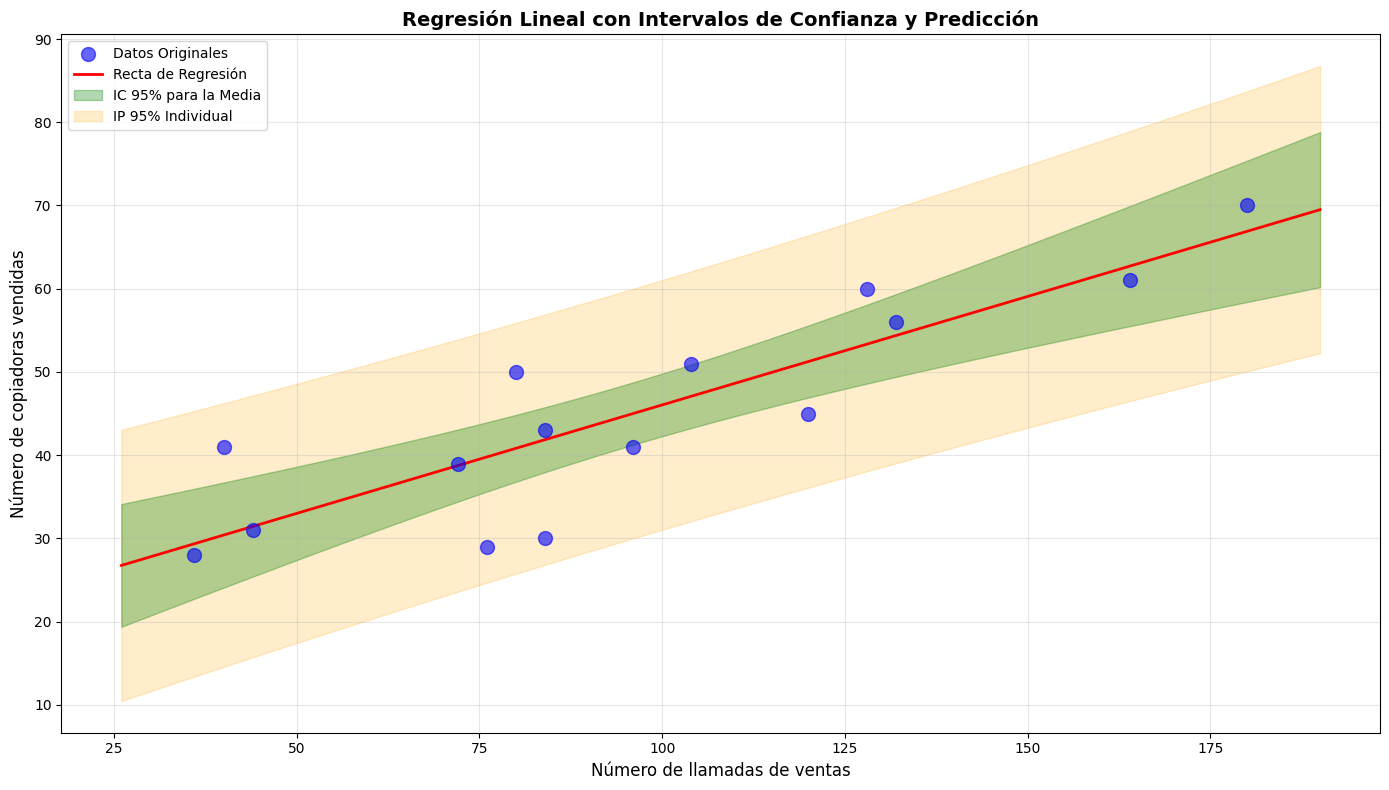

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

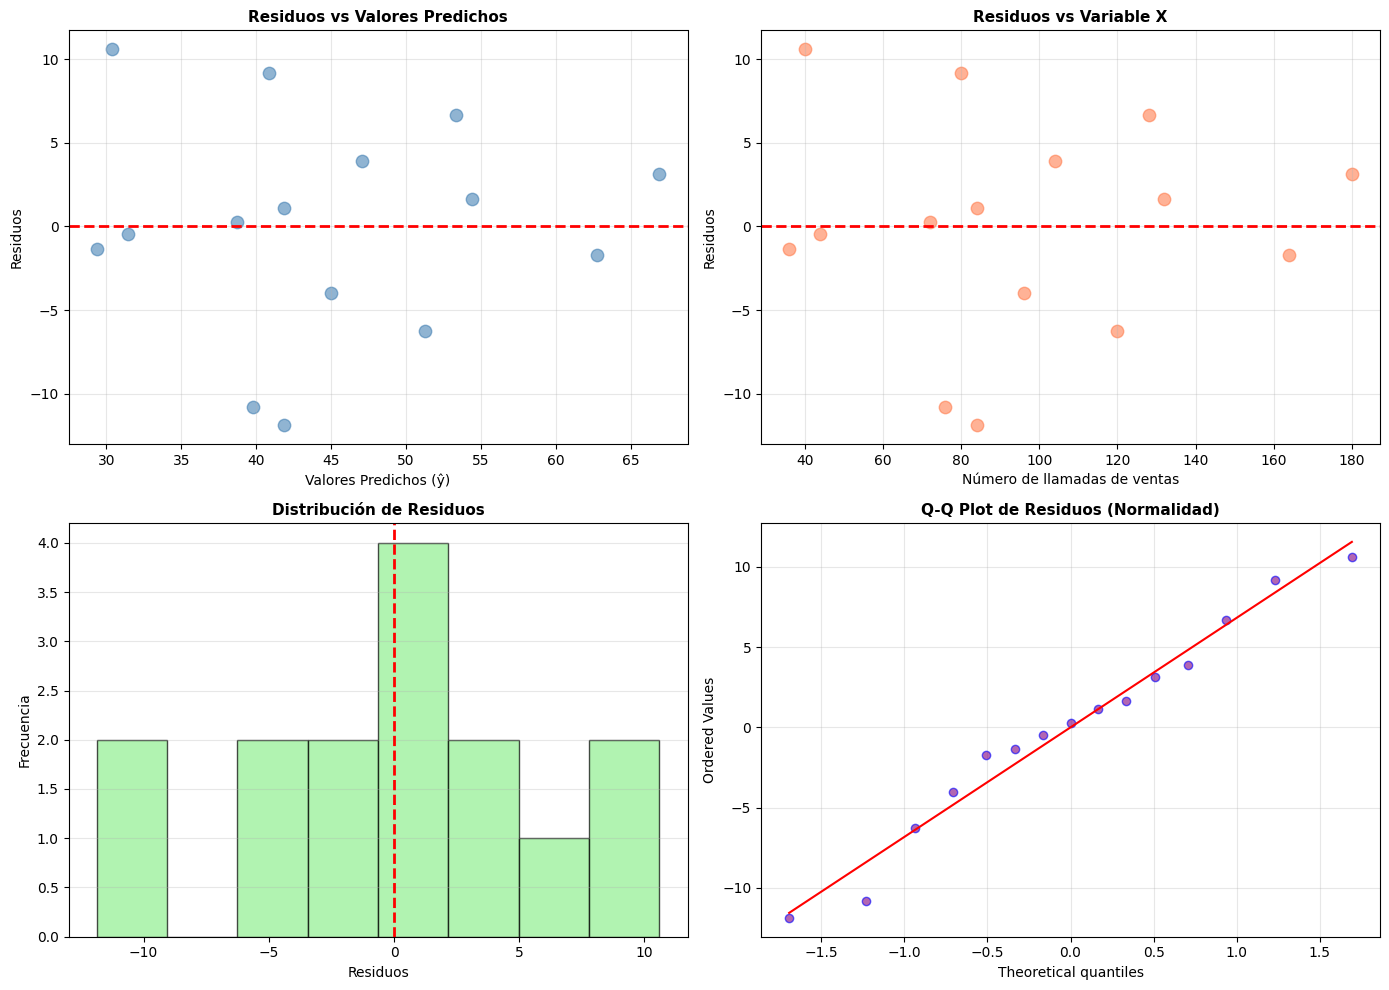


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

SEGUNDO EJERCICIO

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Horas de Estudio vs Calificación Final

Datos cargados: 12 estudiantes
Variable independiente (X): Horas de estudio (X)
Variable dependiente (Y): Calificación final (Y)
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


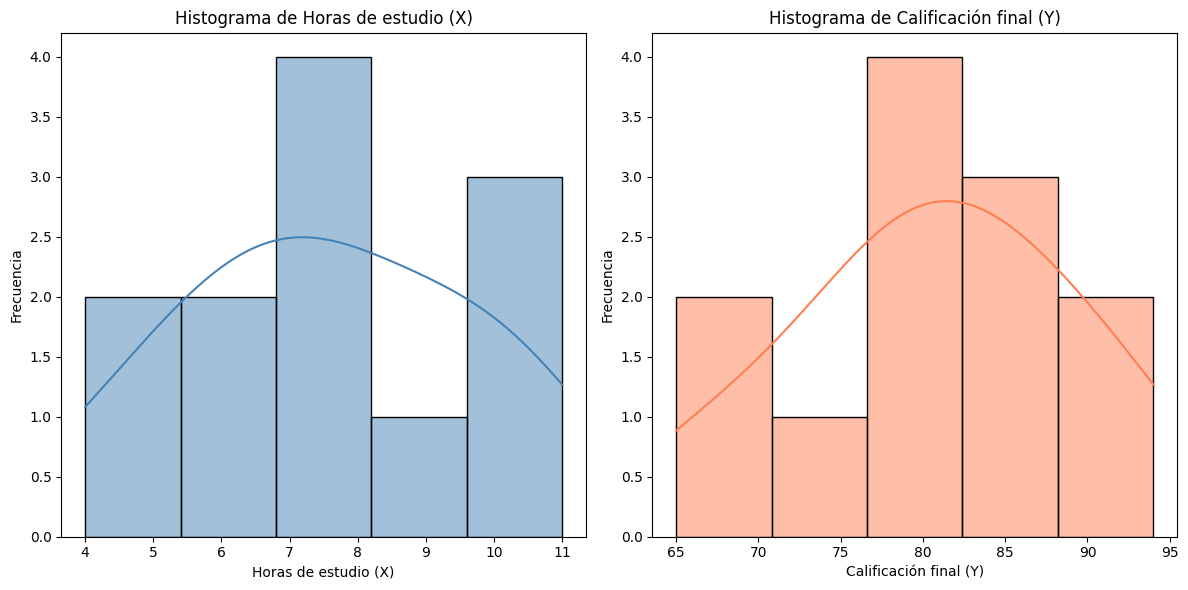

------------------------------
Generating Scatter Plot...


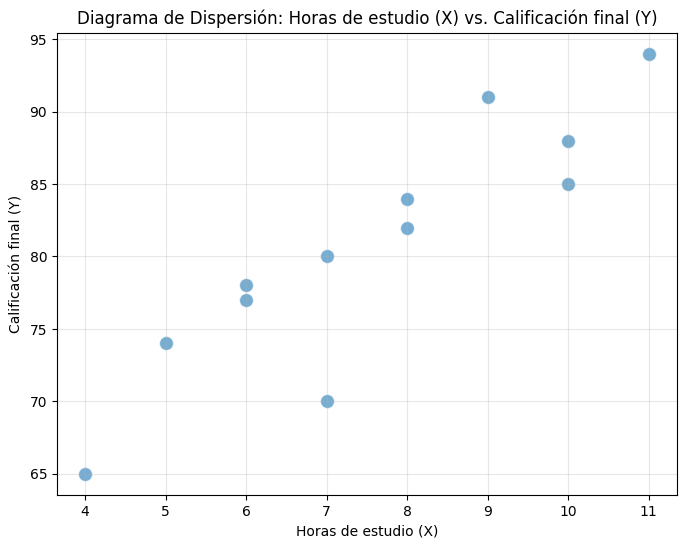

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Horas de estudio (X)': Statistics=0.971, p-value=0.924
Shapiro-Wilk test for 'Calificación final (Y)': Statistics=0.989, p-value=0.999

Interpretation of normality test results:
✓ The 'Horas de estudio (X)' variable appears to be normally distributed (p > 0.05).
✓ The 'Calificación final (Y)' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8965
Kendall correlation coefficient: 0.8129
Spearman correlation coefficient: 0.9190
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8965) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

Hipótesis:
H0: ρ = 0 (No existe

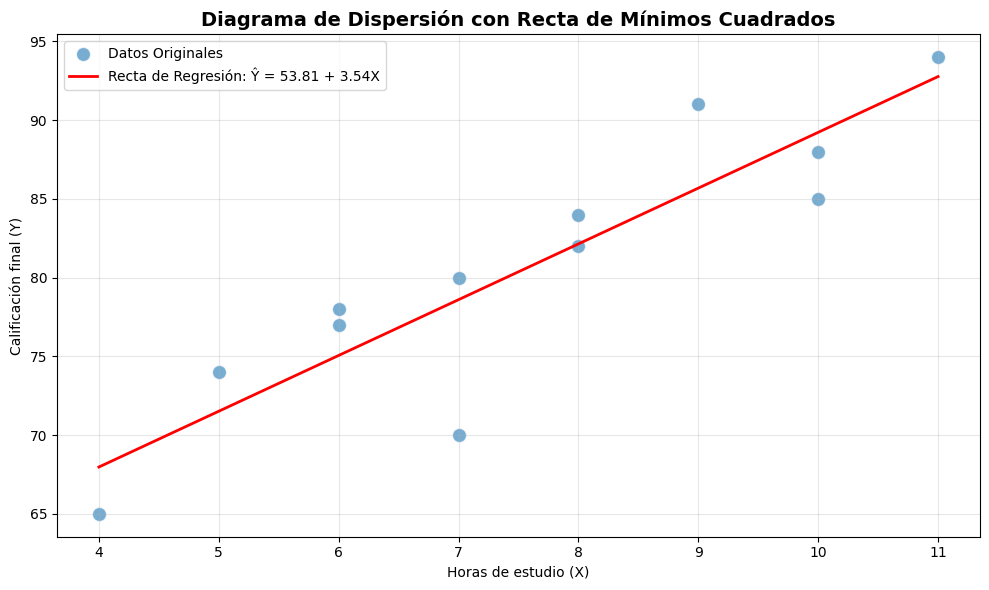


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 155.9738
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 3.9494

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 50.9167
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.5535

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (3.5417 - 0) / 0.5535
   t calculado = 6.3991

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 10
   Valor crítico (t_0.05,10) = 1.8125
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.3991) > t crítico (1.8125)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferente 

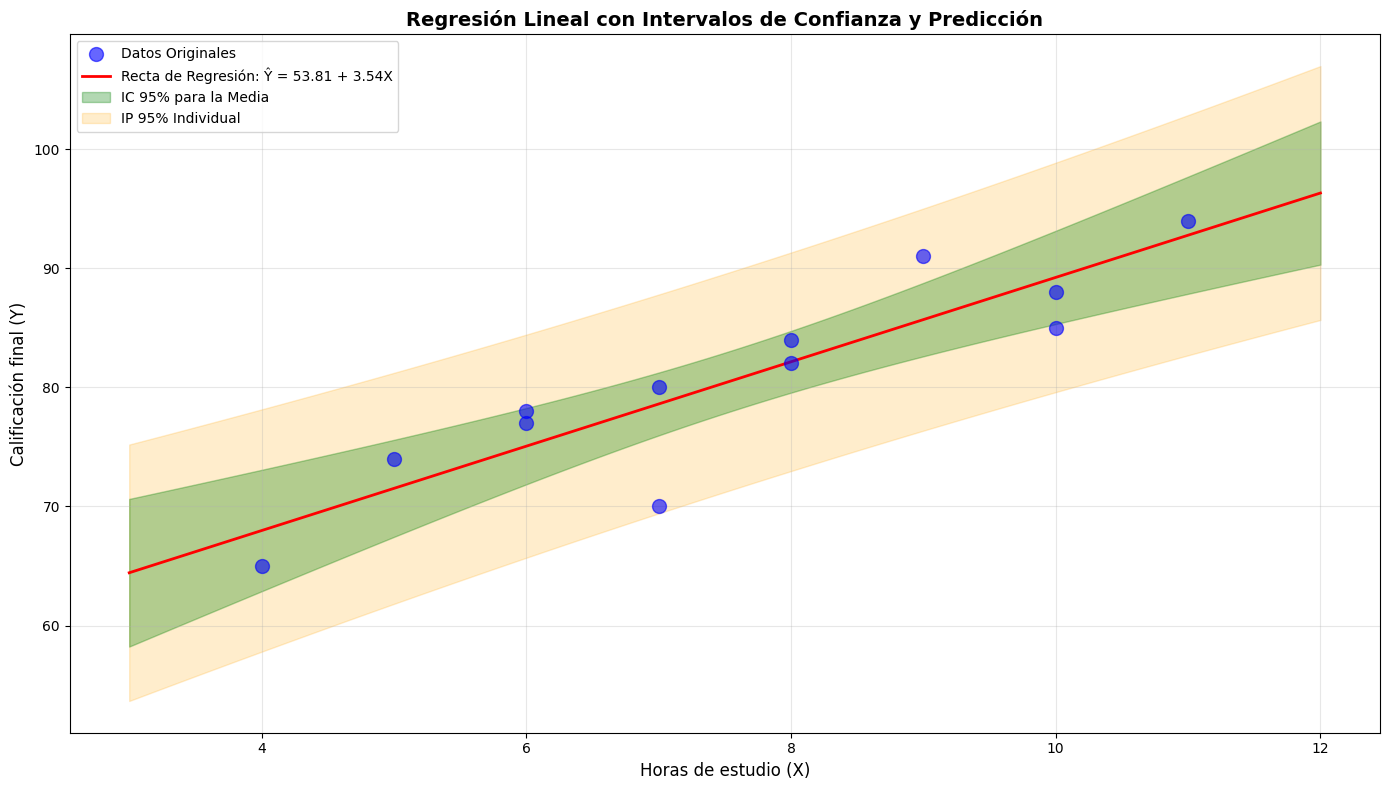

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Estudiante         X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Estudiante 1       4        65       67.98    -2.98      -0.75     
Estudiante 2       7        70       78.60    -8.60      -2.18     
Estudiante 3       10       85       89.23    -4.23      -1.07     
Estudiante 4       6        78       75.06    2.94       0.74      
Estudiante 5       8        82       82.14    -0.14      -0.04     
Estudiante 6       9        91       85.68    5.32       1.35      
Estudiante 7       5        74       71.52    2.48       0.63      
Estudiante 8       11       94       92.77    1.23       0.31      
Estudiante 9       7        80       78.60    1.40       0.35      
Estudiante 10      6        77       75.06    1.94       0.49      
Estudiante 11      8        84       82.14    1.86       0.47      
Estudiante 12      10    

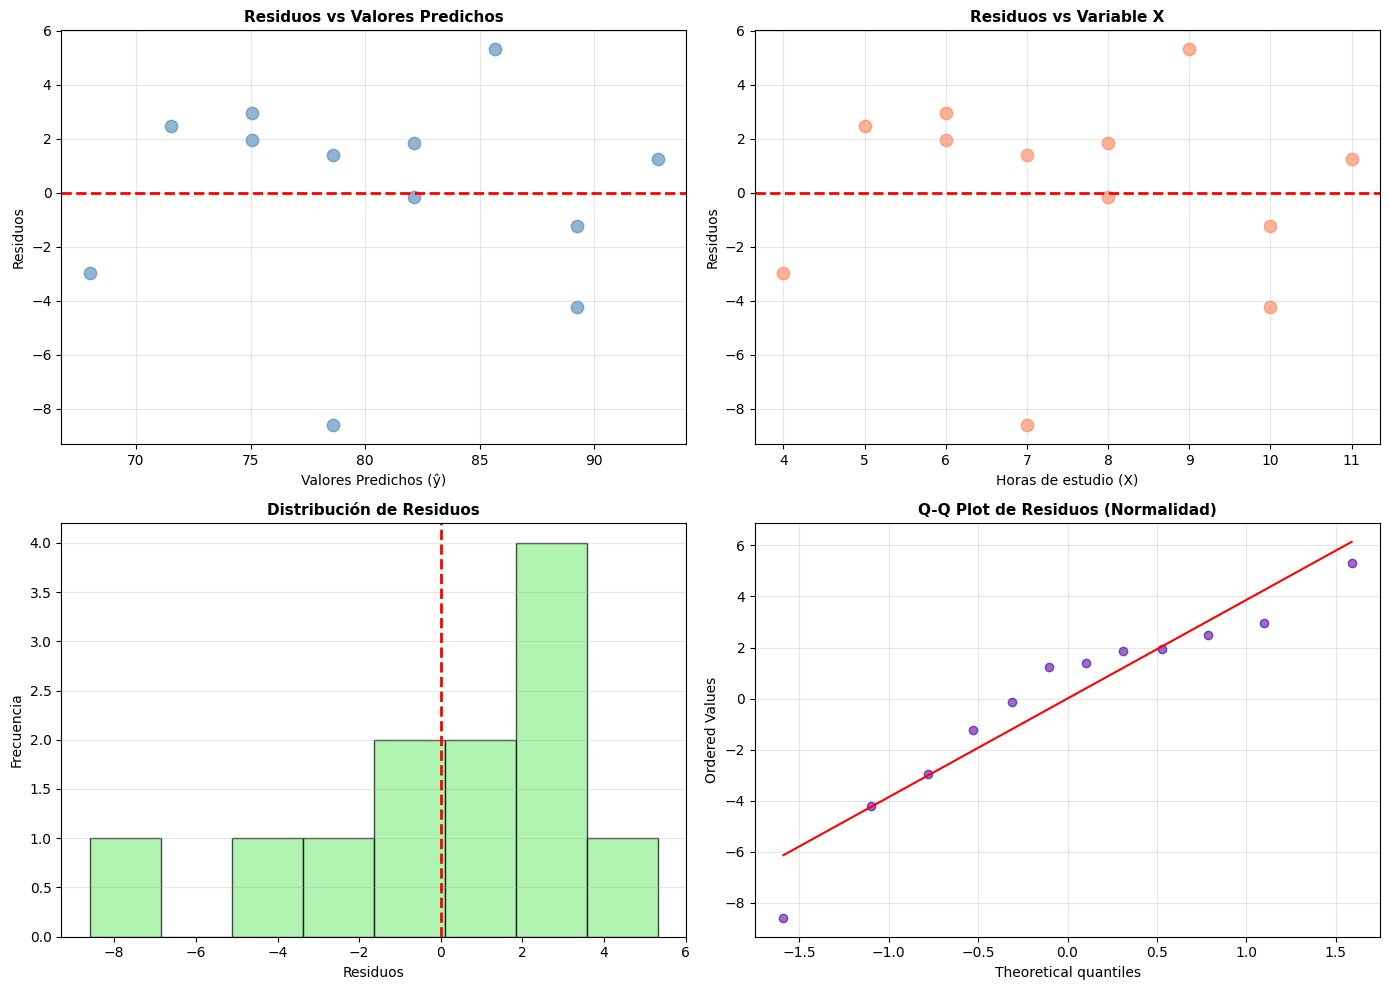


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9194
  Valor p = 0.2811
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Horas de estudio (X): p-value = 0.9239
     ✓ Distribución normal
   • Calificación final (Y): p-value = 0.9994
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.2811
     ✓ Distribución normal

3. HOMOCEDASTIC

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- NUEVO DATAFRAME DEL PROBLEMA (HORAS DE ESTUDIO vs CALIFICACIÓN) ---
data = {
    'Estudiante': [
        f'Estudiante {i+1}' for i in range(12)
    ],
    'Horas de estudio (X)': [
        4, 7, 10, 6, 8, 9, 5, 11, 7, 6, 8, 10
    ],
    'Calificación final (Y)': [
        65, 70, 85, 78, 82, 91, 74, 94, 80, 77, 84, 88
    ]
}
df = pd.DataFrame(data)

variable_x = 'Horas de estudio (X)'
variable_y = 'Calificación final (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Horas de Estudio vs Calificación Final")
print("=" * 70)
print(f"\nDatos cargados: {n} estudiantes")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r**2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Horas de estudio) y Y (Calificación final)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de horas de estudio tiene un efecto significativo POSITIVO sobre
    la calificación final.

    En términos prácticos: Por cada hora de estudio adicional, se espera un
    incremento de {b1:.4f} puntos en la calificación final, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de horas
    de estudio tenga un efecto significativo sobre la calificación final.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en la calificación final │")
print(f"│  puede ser explicada por el número de horas de estudio.        │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X (horas de estudio)
valores_x_ejemplo = [5, 8, 10]  # Ejemplos de horas de estudio

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de calificación final:\n")
print(f"{'X (Horas Estudio)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, para X horas de estudio,")
print("la MEDIA de la calificación final estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para calificación final INDIVIDUAL:\n")
print(f"{'X (Horas Estudio)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, para X horas de estudio,")
print("la calificación final de un estudiante estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 1, df[variable_x].max() + 1, 100) # Ajustar rango si es necesario
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Estudiante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Estudiante']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen') # Ajuste de bins
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Estudiantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Estudiante']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} en la calificación final cuando se estudian 0 horas.
   • Por cada hora de estudio adicional, se espera un incremento de {b1:.4f} puntos en la calificación final.

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} puntos

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de horas de estudio es un predictor SIGNIFICATIVO de la
   calificación final. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir calificaciones esperadas basadas en horas de estudio.
   • Entender la magnitud del impacto de las horas de estudio en el rendimiento académico.

   Recomendación: Fomentar el aumento de las horas de estudio para mejorar las calificaciones.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre horas de estudio y calificación, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos (más estudiantes o diferentes cursos).
   • Considerar otras variables explicativas (ej. asistencia, hábitos de estudio, etc.).
   • Realizar análisis adicionales antes de sacar conclusiones firmes.
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


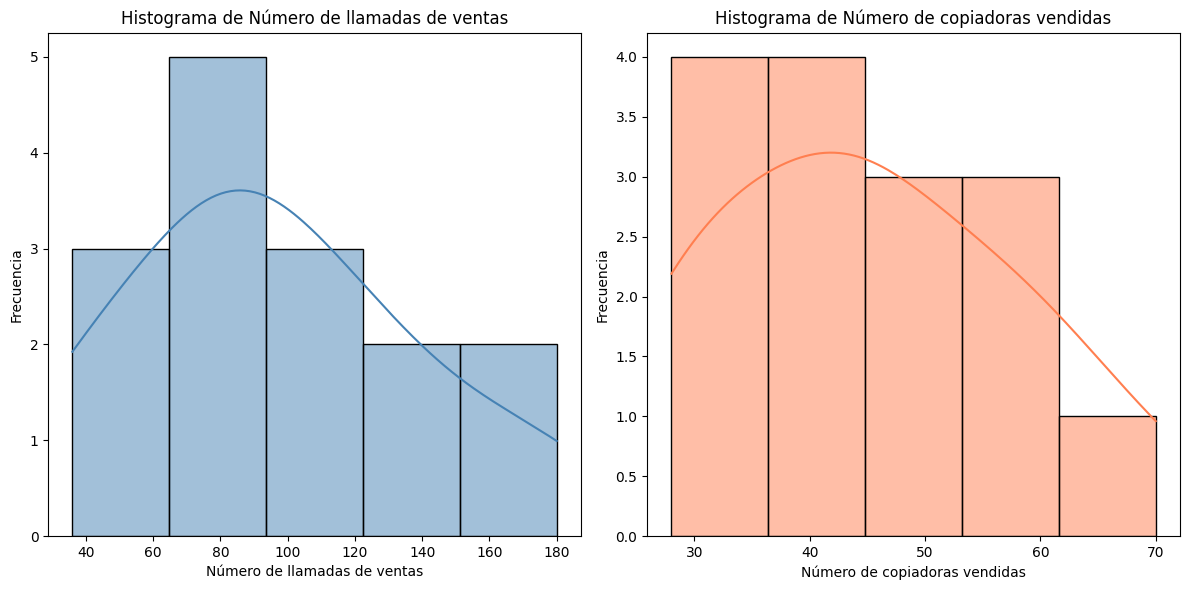

------------------------------
Generating Scatter Plot...


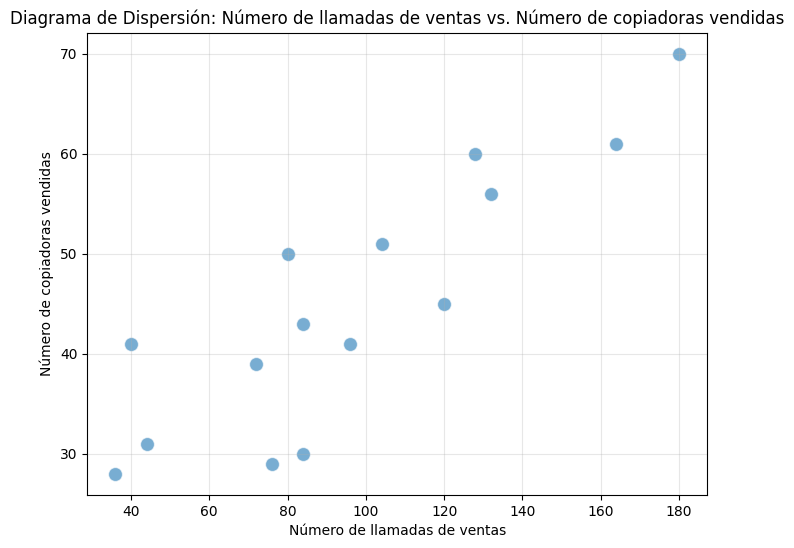

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

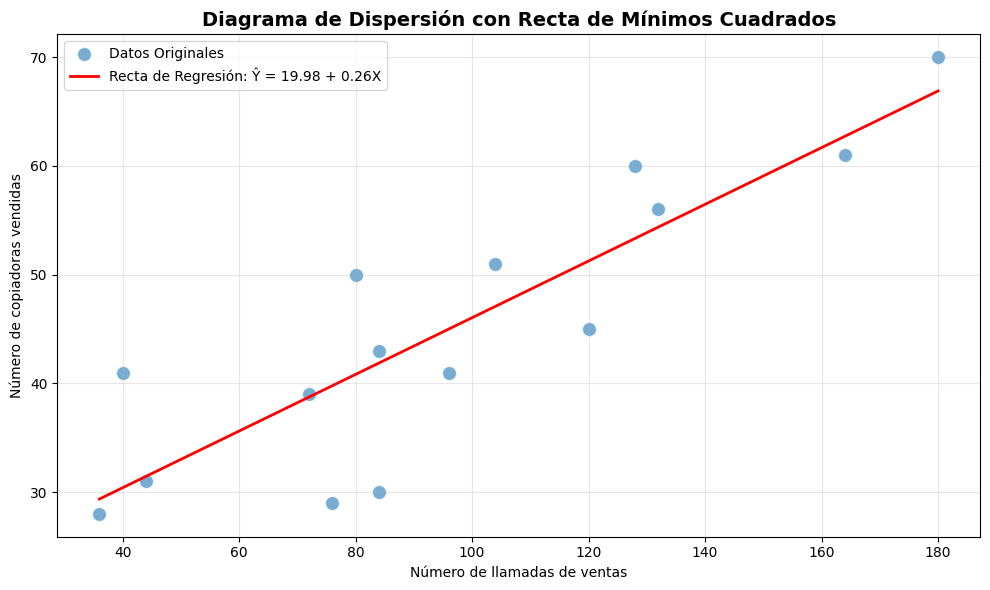


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

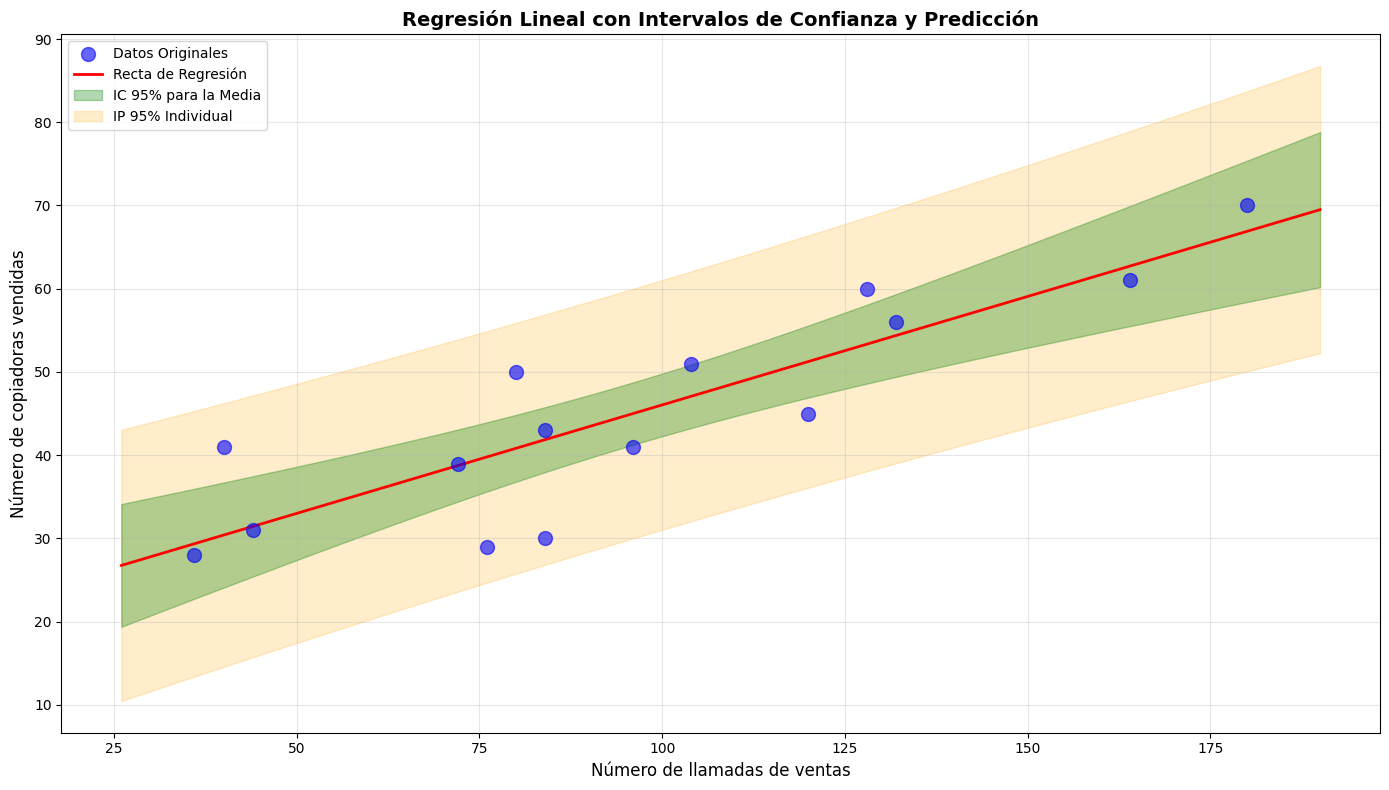

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

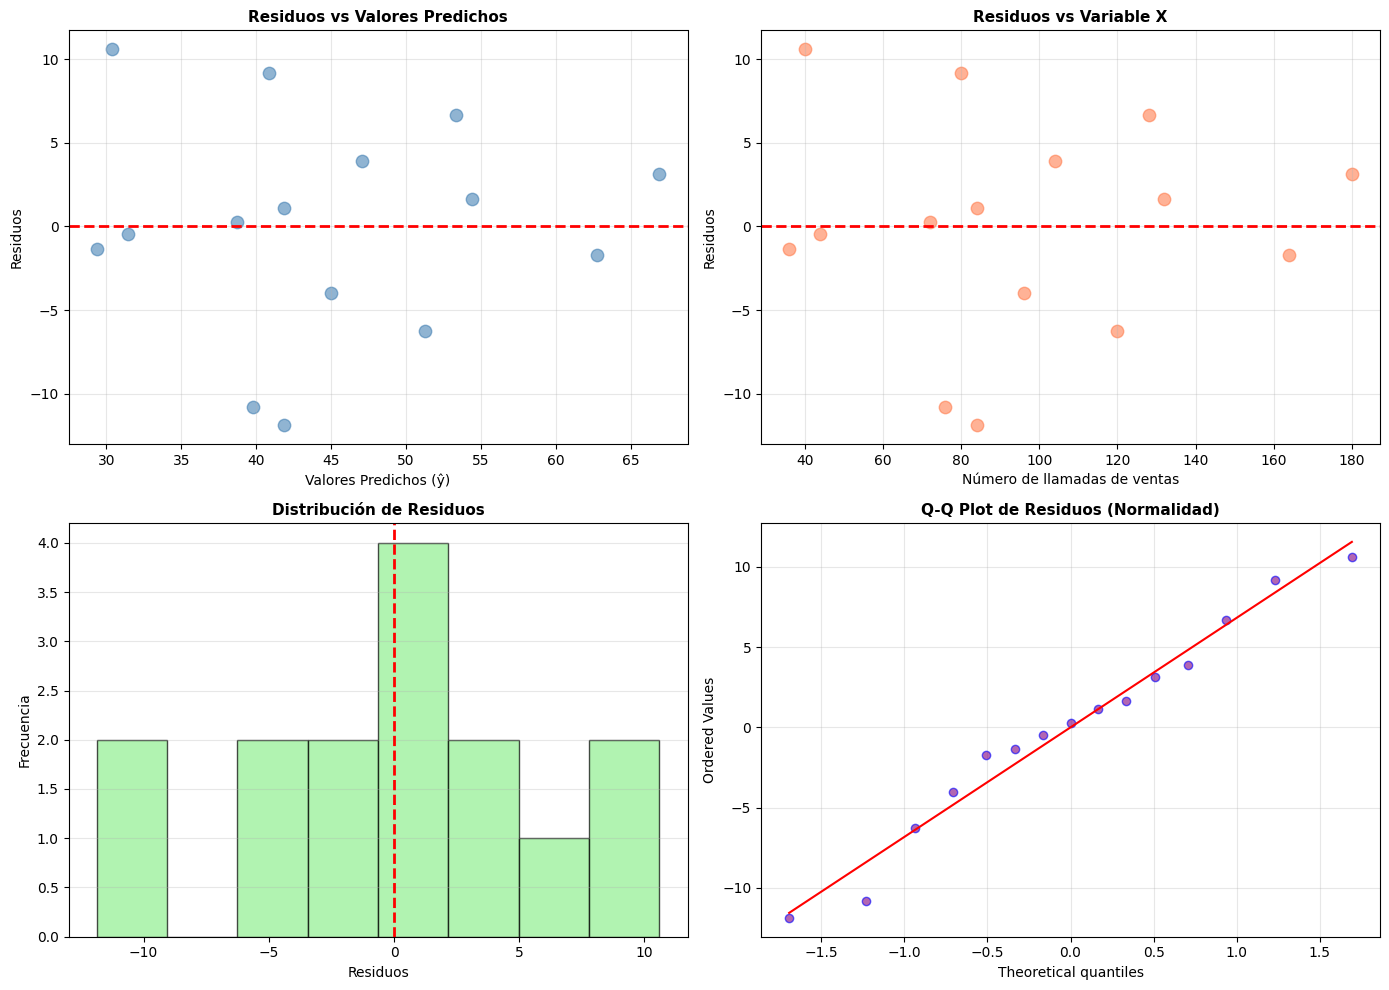


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

TERCER EJERCICIO

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Llamadas Diarias vs Ventas Semanales

Datos cargados: 10 empleados
Variable independiente (X): Llamadas diarias (X)
Variable dependiente (Y): Ventas semanales (Y)
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


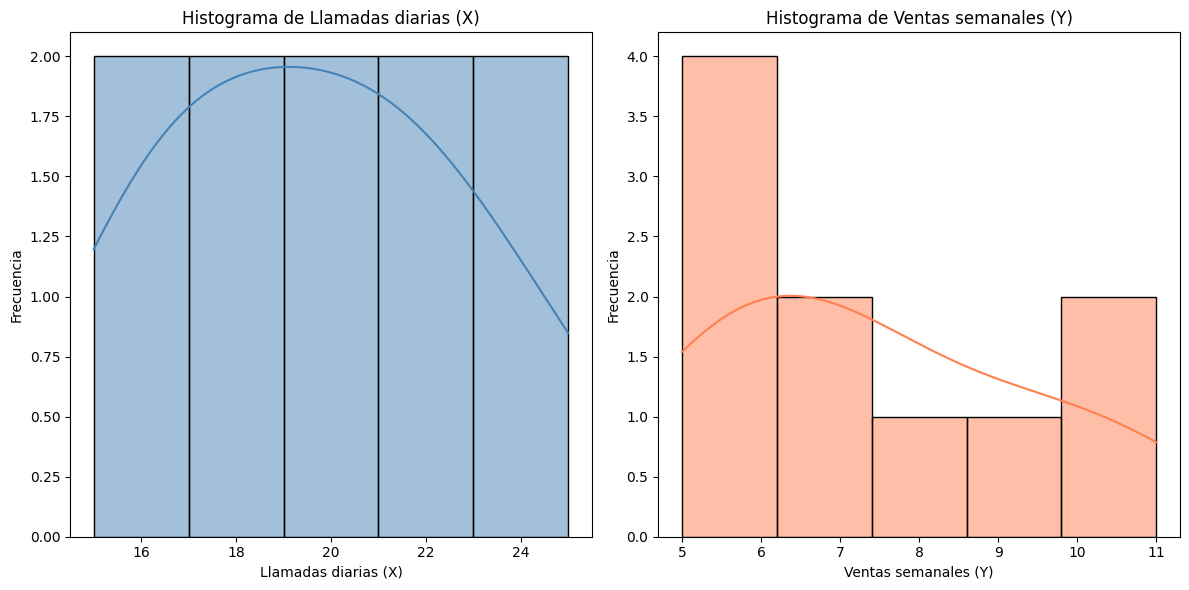

------------------------------
Generating Scatter Plot...


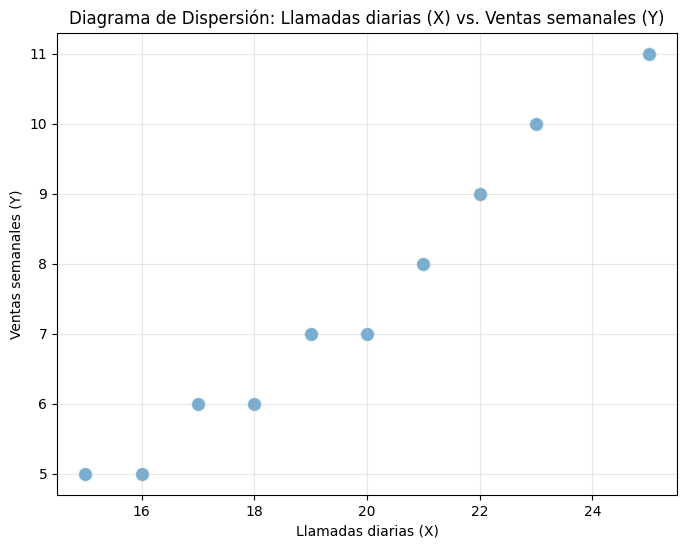

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Llamadas diarias (X)': Statistics=0.981, p-value=0.970
Shapiro-Wilk test for 'Ventas semanales (Y)': Statistics=0.930, p-value=0.447

Interpretation of normality test results:
✓ The 'Llamadas diarias (X)' variable appears to be normally distributed (p > 0.05).
✓ The 'Ventas semanales (Y)' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.9838
Kendall correlation coefficient: 0.9661
Spearman correlation coefficient: 0.9909
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.9838) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

Hipótesis:
H0: ρ = 0 (No existe cor

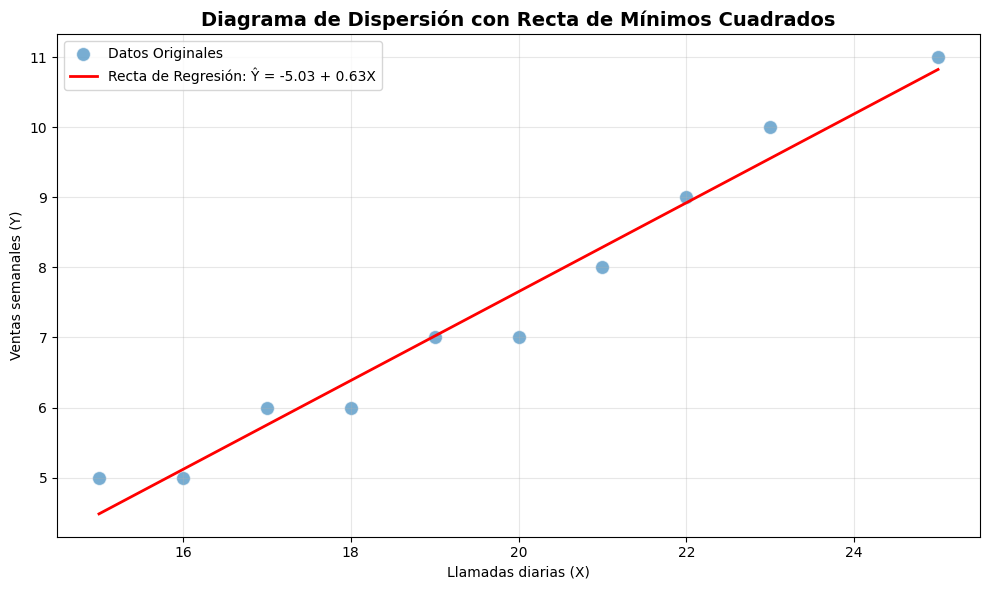


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 1.2359
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 0.3931

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 92.4000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0409

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.6342 - 0) / 0.0409
   t calculado = 15.5099

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 8
   Valor crítico (t_0.05,8) = 1.8595
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (15.5099) > t crítico (1.8595)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferente de

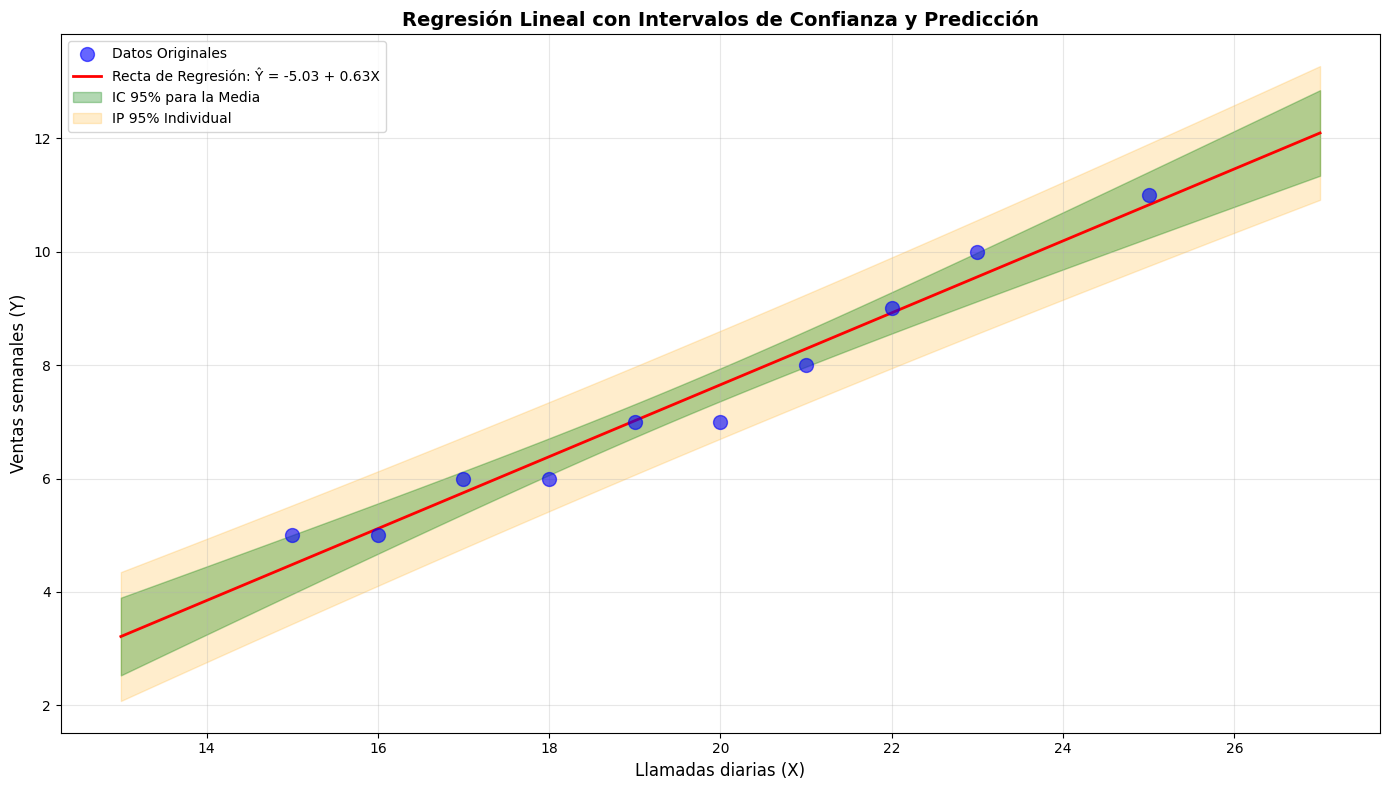

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Empleado           X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Empleado 1         15       5        4.48     0.52       1.32      
Empleado 2         20       7        7.65     -0.65      -1.66     
Empleado 3         18       6        6.39     -0.39      -0.98     
Empleado 4         25       11       10.82    0.18       0.45      
Empleado 5         22       9        8.92     0.08       0.20      
Empleado 6         17       6        5.75     0.25       0.63      
Empleado 7         19       7        7.02     -0.02      -0.05     
Empleado 8         23       10       9.56     0.44       1.13      
Empleado 9         21       8        8.29     -0.29      -0.73     
Empleado 10        16       5        5.12     -0.12      -0.30     

Estadísticas de los Residuos:
  Media de residuos: 0.0000 (debe ser ≈ 0)
  Desviación estánd

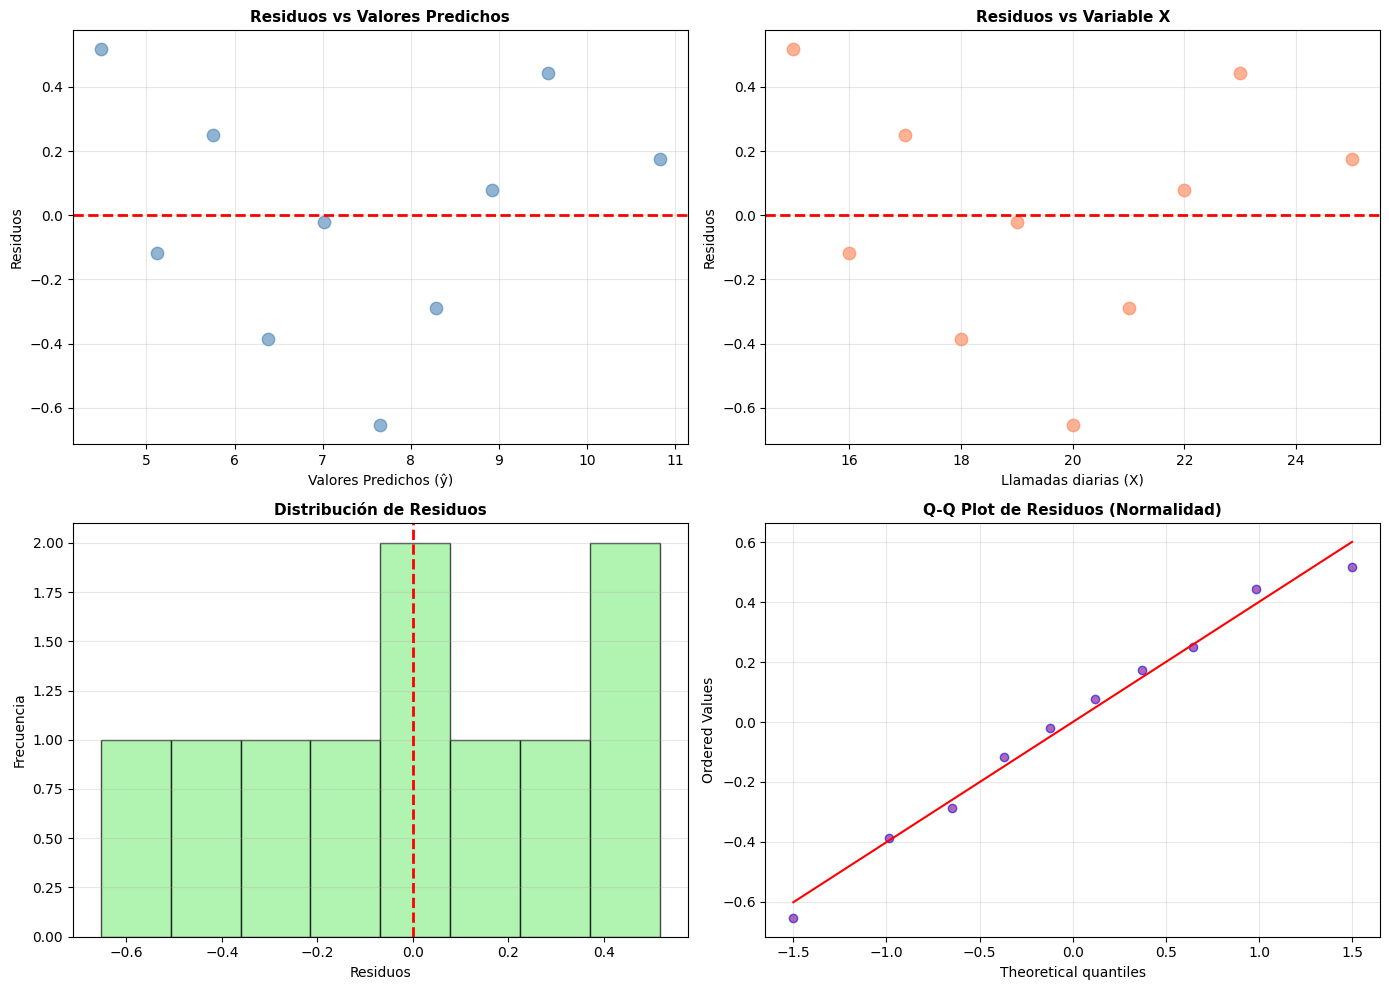


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9779
  Valor p = 0.9531
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Llamadas diarias (X): p-value = 0.9809
     ✓ Distribución normal
   • Ventas semanales (Y): p-value = 0.9299
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.9531
     ✓ Distribución normal

3. HOMOCEDASTICID

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- NUEVO DATAFRAME DEL PROBLEMA (LLAMADAS DIARIAS vs VENTAS SEMANALES) ---
data = {
    'Empleado': [
        'Empleado 1', 'Empleado 2', 'Empleado 3', 'Empleado 4', 'Empleado 5',
        'Empleado 6', 'Empleado 7', 'Empleado 8', 'Empleado 9', 'Empleado 10'
    ],
    'Llamadas diarias (X)': [
        15, 20, 18, 25, 22, 17, 19, 23, 21, 16
    ],
    'Ventas semanales (Y)': [
        5, 7, 6, 11, 9, 6, 7, 10, 8, 5
    ]
}
df = pd.DataFrame(data)

variable_x = 'Llamadas diarias (X)'
variable_y = 'Ventas semanales (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Llamadas Diarias vs Ventas Semanales")
print("=" * 70)
print(f"\nDatos cargados: {n} empleados")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r**2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Llamadas diarias) y Y (Ventas semanales)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas diarias tiene un efecto significativo POSITIVO sobre
    el número de ventas semanales.

    En términos prácticos: Por cada llamada diaria adicional, se espera un
    incremento de {b1:.4f} ventas semanales, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    diarias tenga un efecto significativo sobre el número de ventas semanales.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  ventas semanales puede ser explicada por el número             │")
print(f"│  de llamadas diarias realizadas.                               │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X (Llamadas diarias)
valores_x_ejemplo = [18, 20, 23]  # Ejemplos de llamadas diarias

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de ventas semanales:\n") # Texto ajustado
print(f"{'X (Llamadas Diarias)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}") # Encabezado ajustado
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas diarias,") # Interpretación ajustada
print("la MEDIA de ventas semanales estará dentro del intervalo calculado.") # Interpretación ajustada

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para ventas semanales INDIVIDUALES:\n") # Texto ajustado
print(f"{'X (Llamadas Diarias)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}") # Encabezado ajustado
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas diarias,") # Interpretación ajustada
print("la cantidad de ventas semanales para ese empleado estará dentro del intervalo calculado.") # Interpretación ajustada

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 2, df[variable_x].max() + 2, 100) # Ajustar rango si es necesario
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Empleado':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}") # Encabezado ajustado
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Empleado']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}") # Impresión ajustada


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen') # Ajuste de bins
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.statistic:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.statistic:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Empleados con residuos atípicos:") # Texto ajustado
    for idx, row in outliers.iterrows():
        print(f"     - {row['Empleado']}: residuo std = {row['residuos_estandarizados']:.2f}") # Impresión ajustada

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} ventas semanales cuando se realizan 0 llamadas diarias.
   • Por cada llamada diaria adicional, se espera un incremento de {b1:.4f} ventas semanales.

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} ventas

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas diarias es un predictor SIGNIFICATIVO del
   número de ventas semanales. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas esperadas basadas en llamadas planificadas.
   • Establecer objetivos de llamadas para alcanzar metas de ventas.
   • Evaluar el rendimiento de los empleados.

   Recomendación: Fomentar un mayor número de llamadas diarias para aumentar las ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas diarias y ventas semanales, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos (más empleados o periodos de tiempo).
   • Considerar otras variables explicativas (ej. experiencia, producto, etc.).
   • Realizar análisis adicionales antes de sacar conclusiones firmes.
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


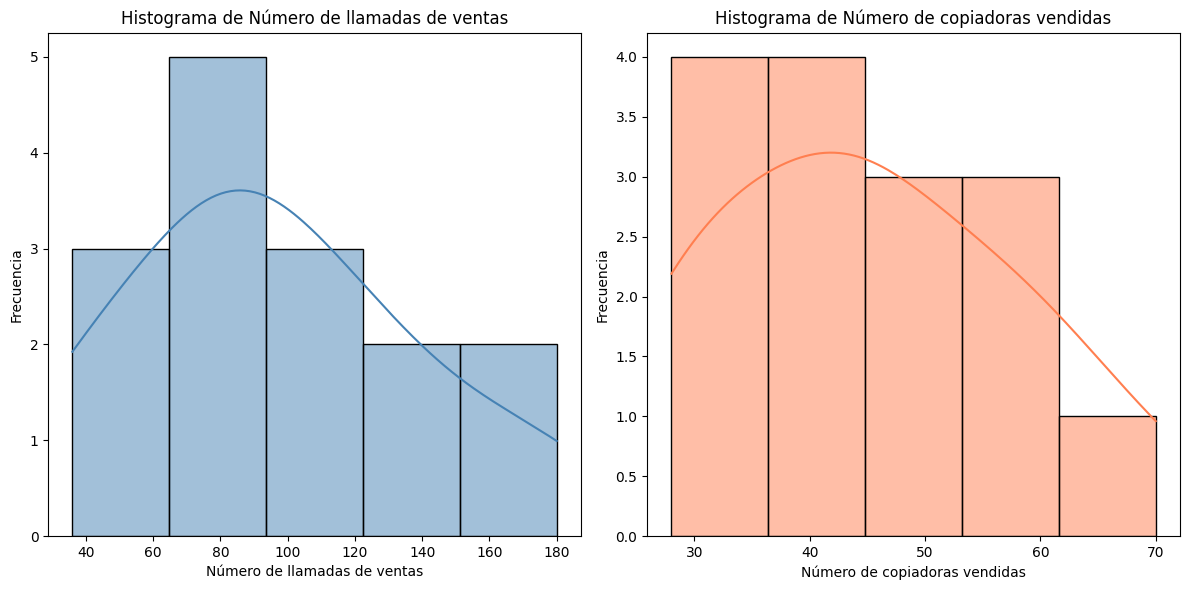

------------------------------
Generating Scatter Plot...


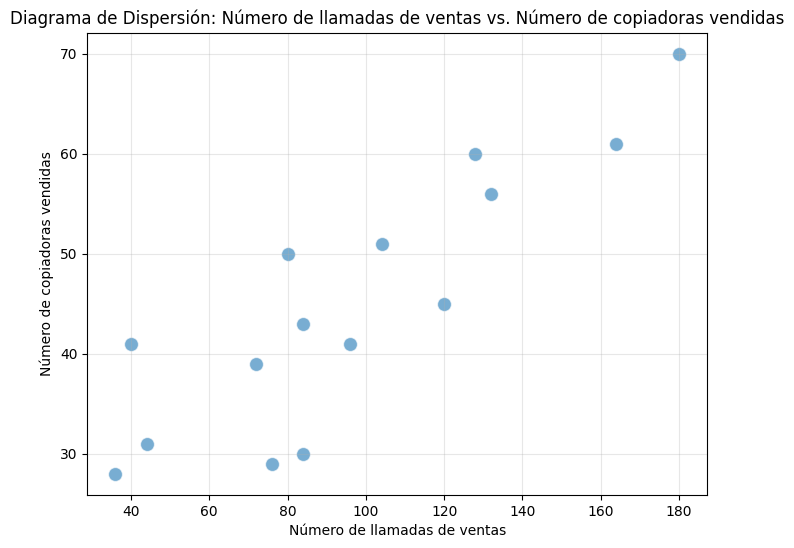

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

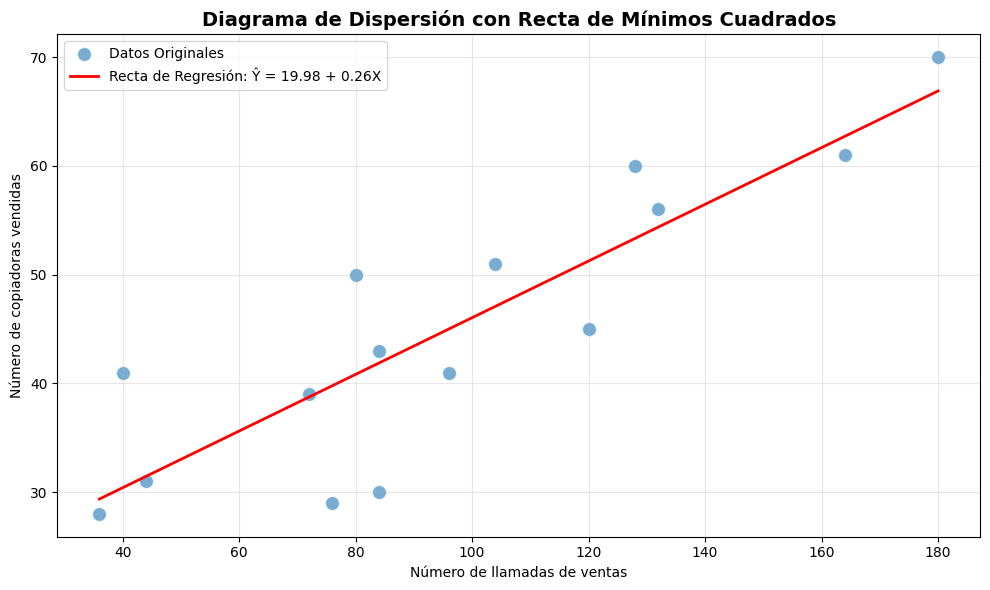


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

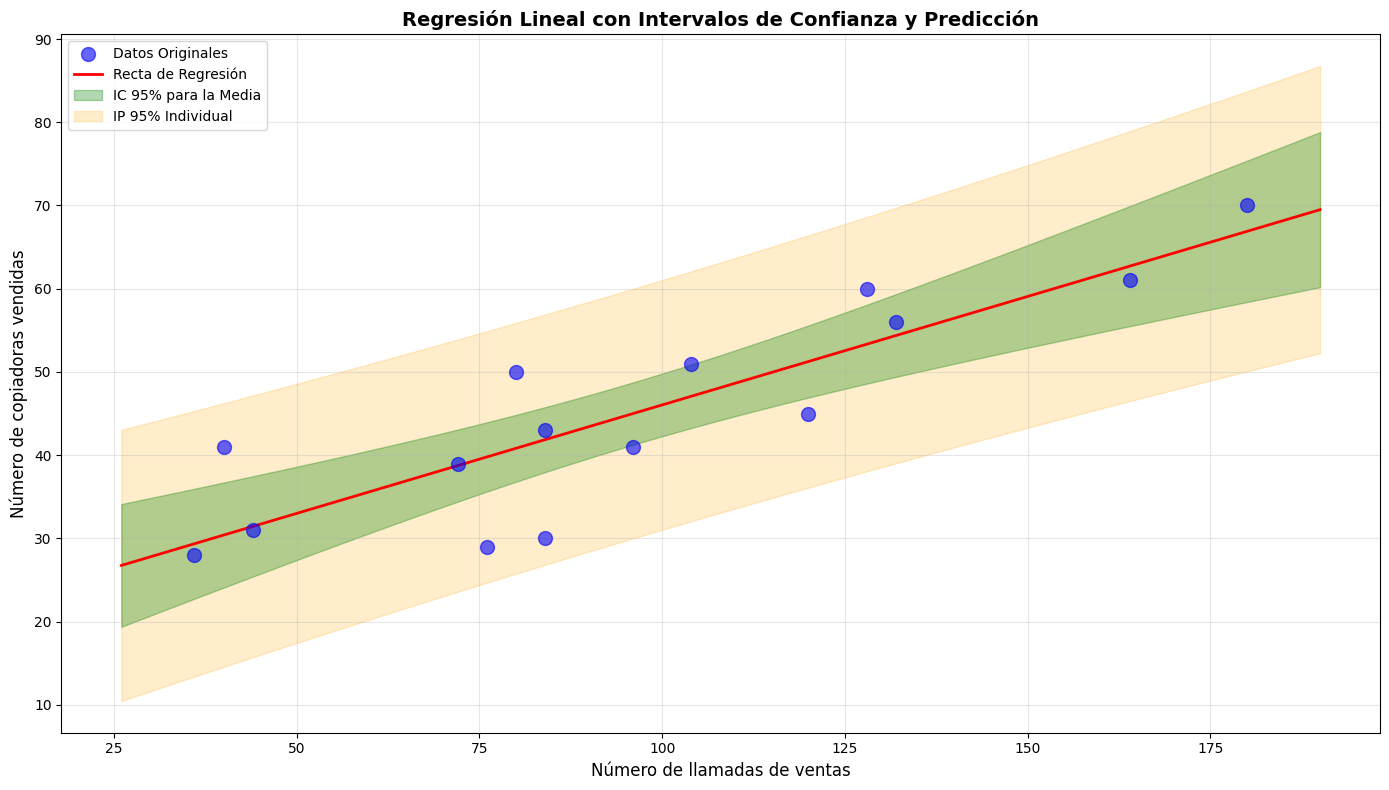

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

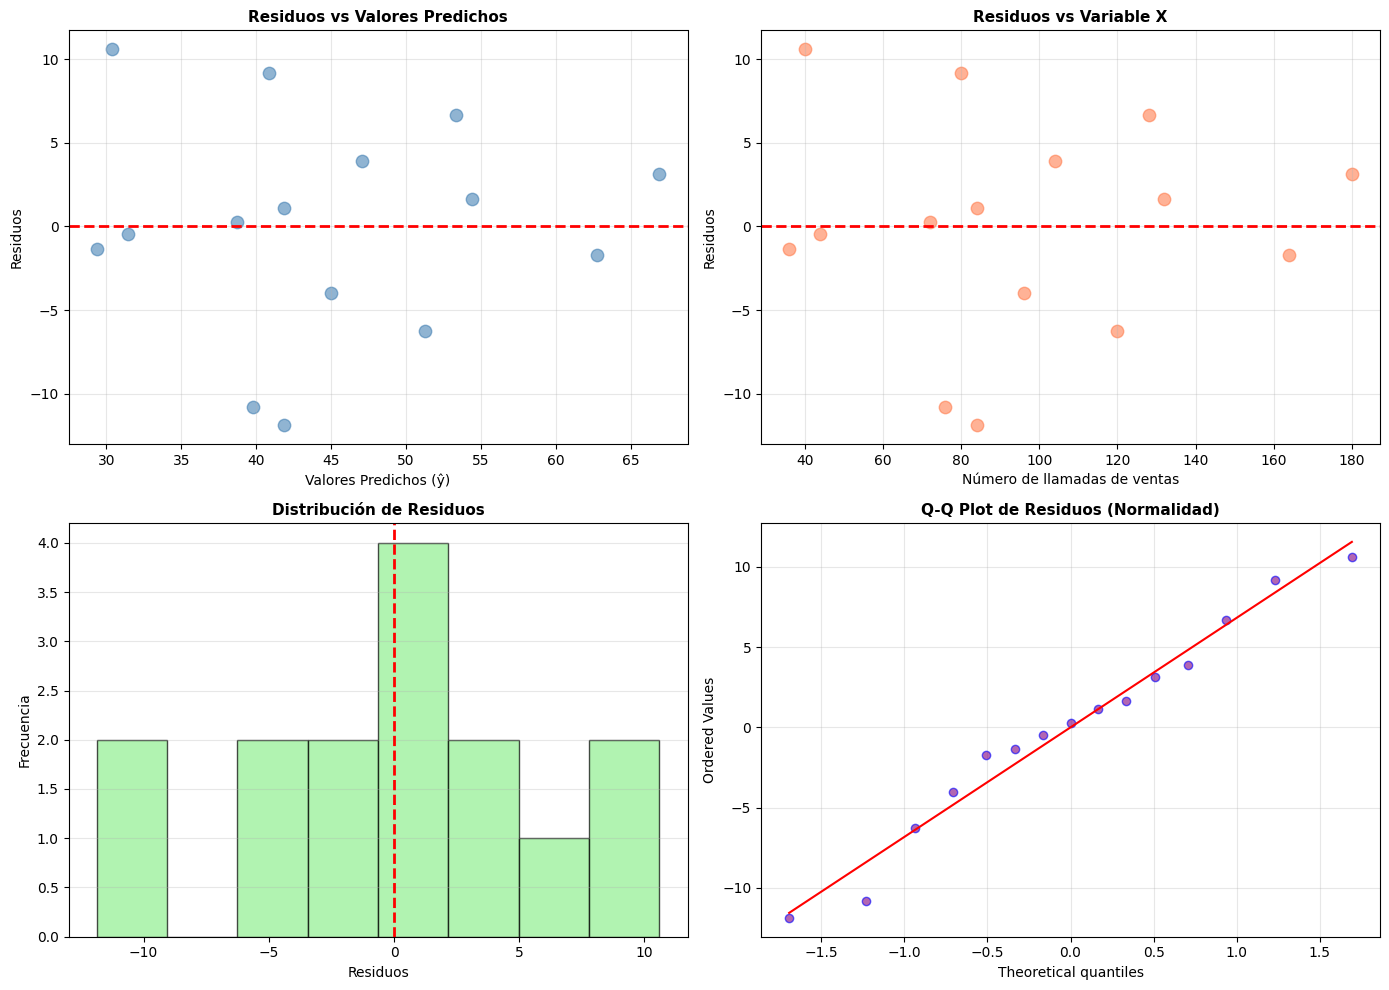


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

CUARTO EJERCICIO

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Tamaño de Tienda vs Ventas Anuales (The Cotton Mill)

Datos cargados: 23 tiendas
Variable independiente (X): Tamaño de la tienda (miles de pies cuadrados)
Variable dependiente (Y): Ventas anuales (miles de dólares)
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


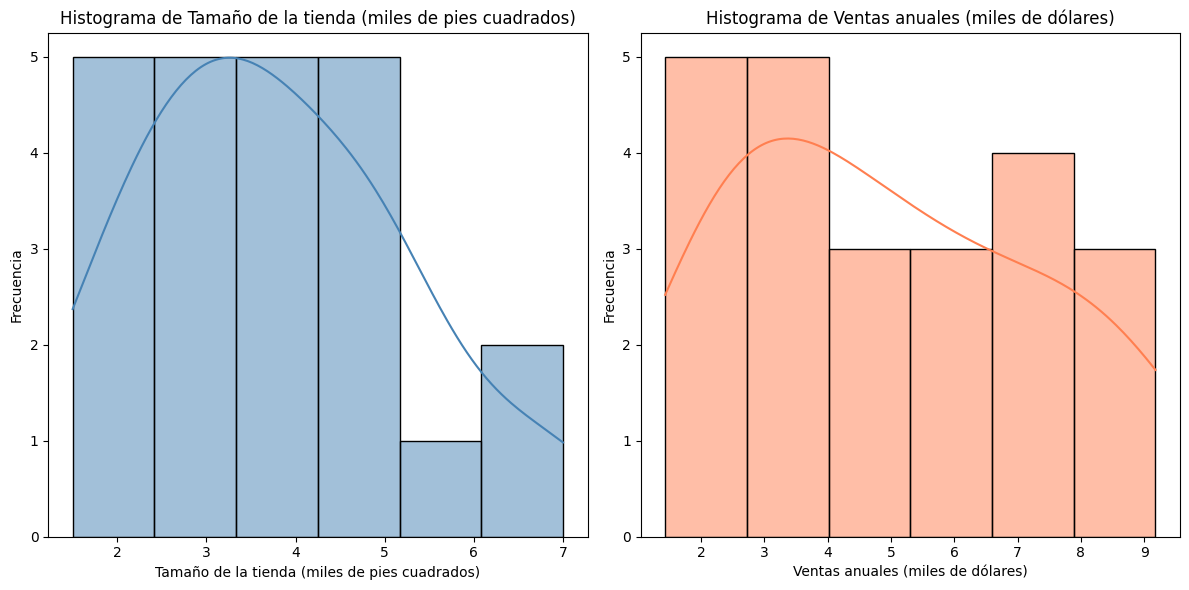

------------------------------
Generating Scatter Plot...


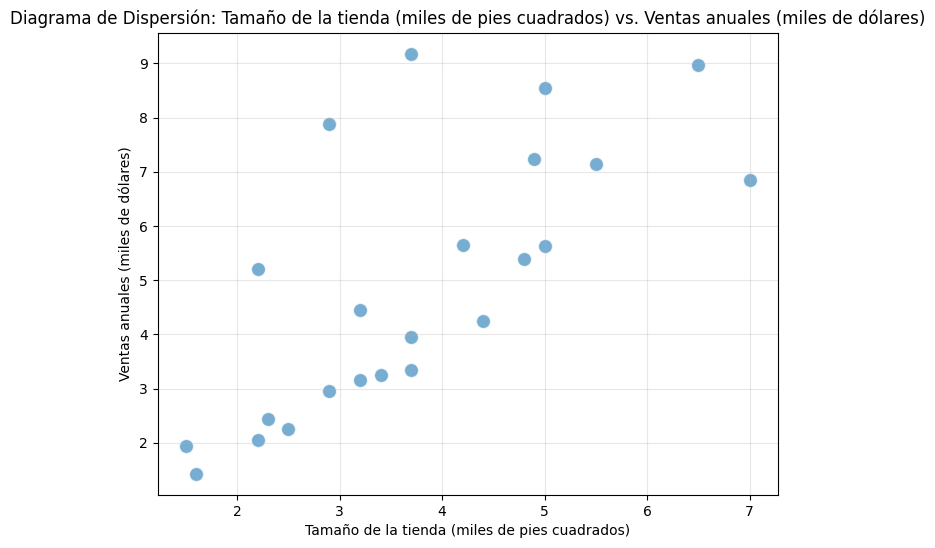

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Tamaño de la tienda (miles de pies cuadrados)': Statistics=0.965, p-value=0.560
Shapiro-Wilk test for 'Ventas anuales (miles de dólares)': Statistics=0.940, p-value=0.177

Interpretation of normality test results:
✓ The 'Tamaño de la tienda (miles de pies cuadrados)' variable appears to be normally distributed (p > 0.05).
✓ The 'Ventas anuales (miles de dólares)' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.7138
Kendall correlation coefficient: 0.6173
Spearman correlation coefficient: 0.7500
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.7138) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS

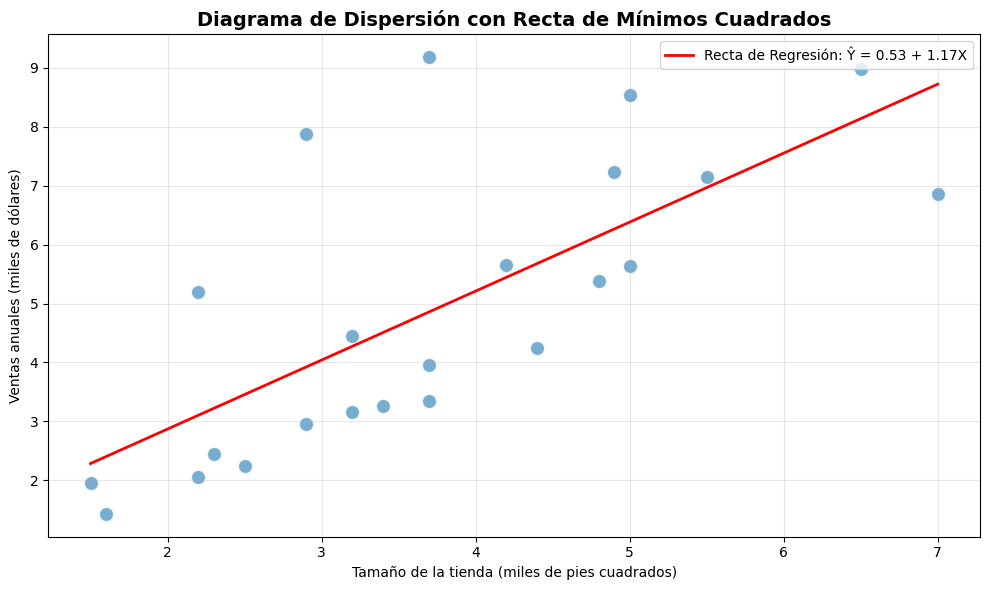


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa entre tamaño de tienda y ventas)
H1: β > 0 (Existe una relación lineal positiva significativa entre tamaño de tienda y ventas)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 62.9084
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 1.7308

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 47.6974
   s_b = s_yx / √[Σ(x - x̄)²] = 0.2506

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (1.1703 - 0) / 0.2506
   t calculado = 4.6700

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 21
   Valor crítico (t_0.05,21) = 1.7207
   Valor p (una cola) = 0.0001

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (4.6700) > t crítico (1.7207)
valor p (0.0001) < α (0.05)

DECISIÓN: RECHAZAR H0
I

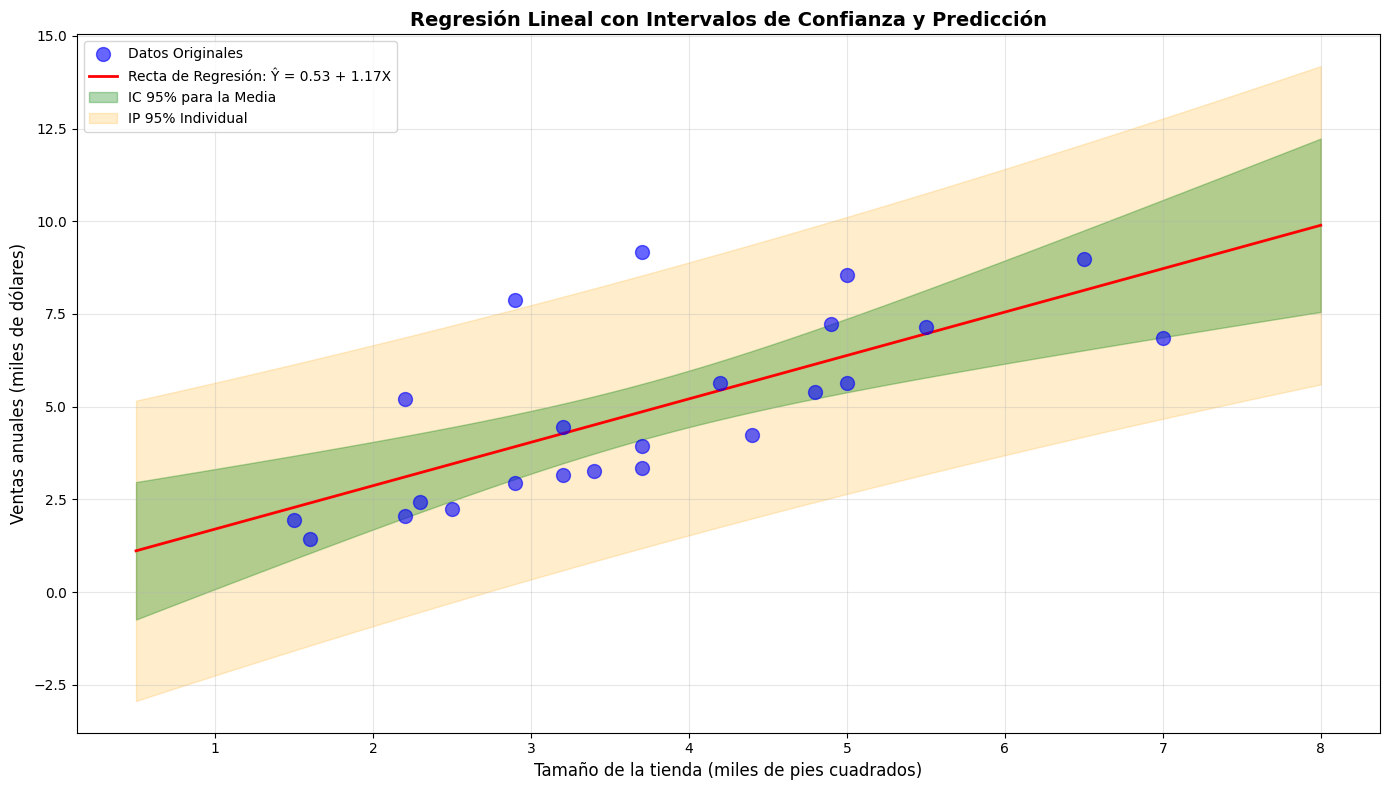

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Tienda             Región     X        Y        ŷ        Residuo    Res. Std. 
--------------------------------------------------------------------------------
1                  Región 1   3.7      9.18     4.86     4.32       2.50      
2                  Región 1   5.0      8.54     6.38     2.16       1.25      
3                  Región 1   7.0      6.85     8.72     -1.87      -1.08     
4                  Región 1   6.5      8.98     8.14     0.84       0.49      
5                  Región 1   2.2      5.20     3.10     2.10       1.21      
6                  Región 1   5.5      7.15     6.97     0.18       0.11      
7                  Región 1   2.9      7.88     3.92     3.96       2.29      
8                  Región 2   4.2      5.65     5.44     0.21       0.12      
9                  Región 2   3.4      3.26     4.51     -1.25      -0.72     
10                 Región 2   2.5      2.

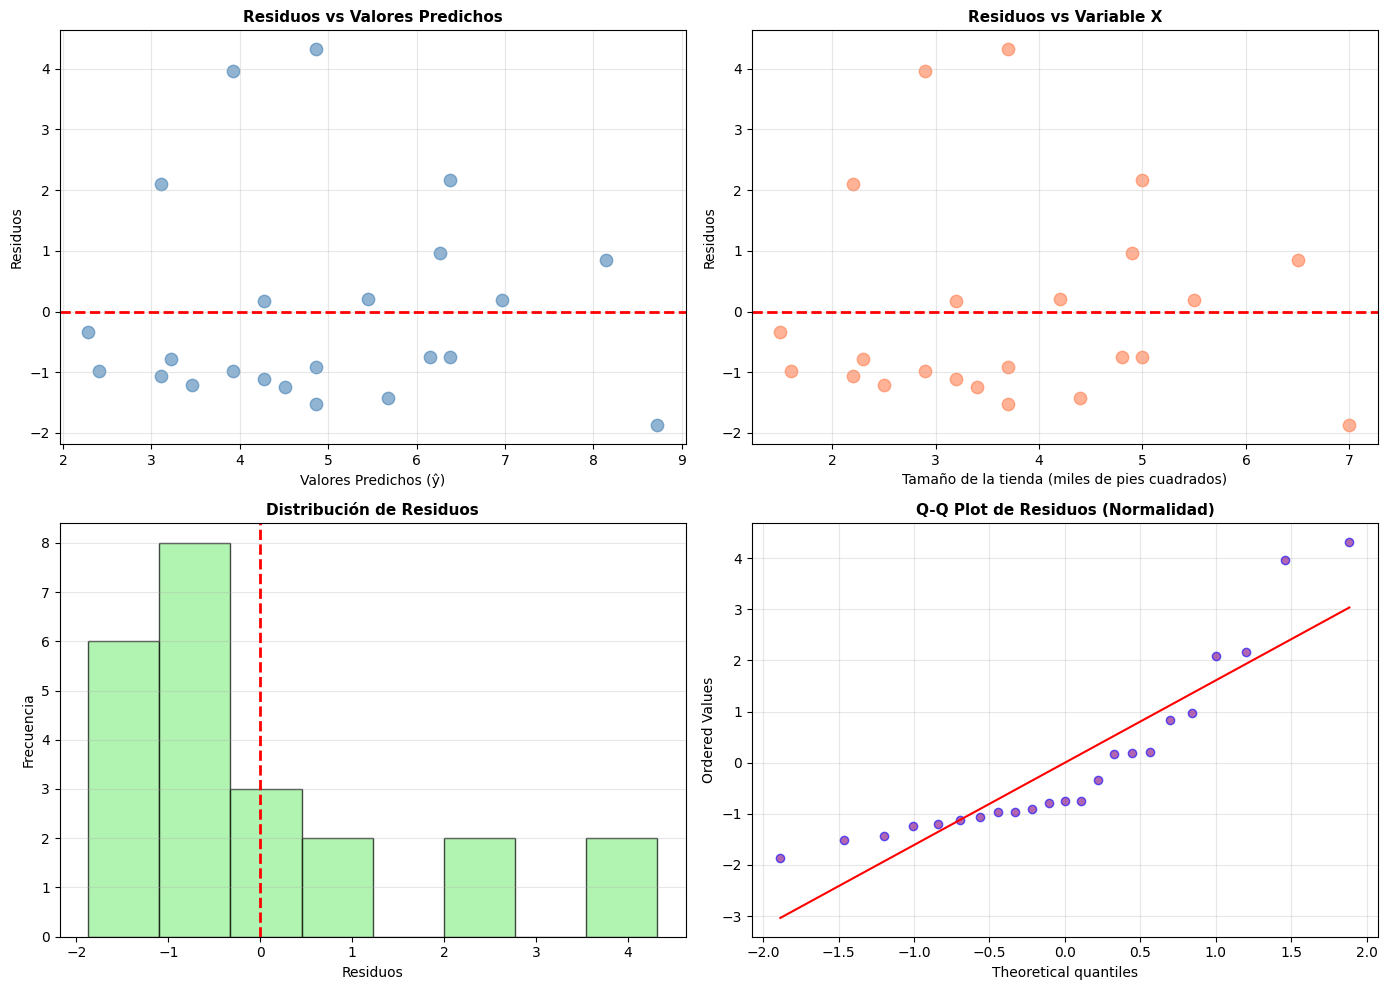


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.8257
  Valor p = 0.0010
  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ 0.05)
    El supuesto de normalidad puede no cumplirse.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Tamaño de la tienda (miles de pies cuadrados): p-value = 0.5600
     ✓ Distribución normal
   • Ventas anuales (miles de dólares): p-value = 0.1772
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- NUEVO DATAFRAME DEL PROBLEMA (TAMAÑO DE TIENDA vs VENTAS) ---
data_region1 = {
    'Región': ['Región 1'] * 7,
    'Tamaño de la tienda (miles de pies cuadrados)': [3.7, 5.0, 7.0, 6.5, 2.2, 5.5, 2.9],
    'Ventas anuales (miles de dólares)': [9.18, 8.54, 6.85, 8.98, 5.20, 7.15, 7.88]
}

data_region2 = {
    'Región': ['Región 2'] * 7,
    'Tamaño de la tienda (miles de pies cuadrados)': [4.2, 3.4, 2.5, 1.5, 3.7, 4.9, 3.2],
    'Ventas anuales (miles de dólares)': [5.65, 3.26, 2.25, 1.95, 3.34, 7.23, 4.45]
}

data_region3 = {
    'Región': ['Región 3'] * 9,
    'Tamaño de la tienda (miles de pies cuadrados)': [2.2, 1.6, 2.3, 2.9, 3.2, 3.7, 4.4, 4.8, 5.0],
    'Ventas anuales (miles de dólares)': [2.05, 1.43, 2.44, 2.95, 3.16, 3.95, 4.25, 5.39, 5.64]
}

df_region1 = pd.DataFrame(data_region1)
df_region2 = pd.DataFrame(data_region2)
df_region3 = pd.DataFrame(data_region3)

df = pd.concat([df_region1, df_region2, df_region3], ignore_index=True)

variable_x = 'Tamaño de la tienda (miles de pies cuadrados)'
variable_y = 'Ventas anuales (miles de dólares)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Tamaño de Tienda vs Ventas Anuales (The Cotton Mill)")
print("=" * 70)
print(f"\nDatos cargados: {n} tiendas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r**2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Tamaño de la tienda) y Y (Ventas anuales)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero) # Adjusting to one-tailed test if the user implies positive relationship

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa entre tamaño de tienda y ventas)") # Adjusted hypothesis
print("H1: β > 0 (Existe una relación lineal positiva significativa entre tamaño de tienda y ventas)") # Adjusted hypothesis

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_yx / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero (relación positiva)." # Adjusted interpretation
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el tamaño de la tienda tiene un efecto significativo POSITIVO sobre
    las ventas anuales.

    En términos prácticos: Por cada mil pies cuadrados adicionales de tamaño de tienda,
    se espera un incremento de {b1*1000:.2f} dólares en ventas anuales, y este efecto
    es estadísticamente significativo.
    """ # Adjusted interpretation and practical terms
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero (no hay relación positiva significativa)." # Adjusted interpretation
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el tamaño de la tienda
    tenga un efecto significativo POSITIVO sobre las ventas anuales en este conjunto de datos.
    """ # Adjusted interpretation

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en las ventas anuales      │") # Adjusted interpretation
print(f"│  puede ser explicada por el tamaño de la tienda.                │") # Adjusted interpretation
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X (Tamaño de la tienda)
valores_x_ejemplo = [3.0, 4.0, 5.0]  # Ejemplos de tamaño de tienda

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de ventas anuales:\n") # Adjusted text
print(f"{'X (Tamaño Tienda)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}") # Adjusted header
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, para un tamaño de tienda de X miles de pies cuadrados,") # Adjusted interpretation
print("la MEDIA de las ventas anuales estará dentro del intervalo calculado.") # Adjusted interpretation

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para ventas anuales INDIVIDUALES:\n") # Adjusted text
print(f"{'X (Tamaño Tienda)':<20} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}") # Adjusted header
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<20} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, para un tamaño de tienda de X miles de pies cuadrados,") # Adjusted interpretation
print("las ventas anuales de una tienda individual estarán dentro del intervalo calculado.") # Adjusted interpretation

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 1, df[variable_x].max() + 1, 100) # Ajustar rango si es necesario
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Tienda':<18} {'Región':<10} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}") # Adjusted header
print("-" * 80) # Adjusted separator length
for idx, row in df.iterrows():
    print(f"{idx+1:<18} {row['Región']:<10} {row[variable_x]:<8.1f} {row[variable_y]:<8.2f} " # Adjusted printing format
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen') # Ajuste de bins
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Tiendas con residuos atípicos:") # Adjusted text
    for idx, row in outliers.iterrows():
        print(f"     - Tienda {idx+1} (Región {row['Región']}): residuo std = {row['residuos_estandarizados']:.2f}") # Adjusted printing

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} miles de dólares en ventas anuales para una tienda de tamaño 0. (Interpretación teórica, el intercepto puede no tener significado práctico en este contexto).
   • Por cada mil pies cuadrados adicionales de tamaño de tienda, se espera un incremento de {b1:.4f} miles de dólares ({b1*1000:.2f} dólares) en ventas anuales.

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad en ventas anuales explicada por el tamaño de la tienda.

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} miles de dólares (±{s_yx*1000:.2f} dólares)

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente (Relación Positiva):
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p (una cola): {valor_p_pendiente:.4f}
      • Decisión: {'✓ EXISTE CORRELACIÓN POSITIVA SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO HAY EVIDENCIA DE CORRELACIÓN POSITIVA SIGNIFICATIVA'} # Adjusted decision text

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión (parece lineal)'} # Added comment based on expected plot
   • Homocedasticidad: {'✓ Verificar gráfico de residuos (buscar patrón aleatorio)'} # Added comment

💡 CONCLUSIÓN GENERAL Y TOMA DE DECISIONES:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa and r > 0: # Check for positive correlation
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES Y TOMA DE DECISIONES

   El tamaño de la tienda es un predictor SIGNIFICATIVO y POSITIVO de las
   ventas anuales. El modelo explica {r_cuadrado*100:.2f}% de la variabilidad.

   Implicaciones para la apertura de nuevas tiendas:
   • Existe una clara relación entre el tamaño de la tienda y las ventas. Tiendas más grandes tienden a generar mayores ventas.
   • El modelo sugiere que aumentar el tamaño de una tienda en 1000 pies cuadrados podría incrementar las ventas anuales en aproximadamente ${b1*1000:.2f}.
   • Al planificar nuevas tiendas, considerar el tamaño óptimo basado en el potencial de ventas esperado en la ubicación. Tiendas más grandes tienen un mayor potencial de ingresos.
   • Utilizar el intervalo de predicción para estimar el rango probable de ventas para un tamaño de tienda específico en una nueva ubicación.

   Recomendación: Considerar la apertura de tiendas de mayor tamaño para maximizar el potencial de ventas, siempre y cuando otros factores (costo de alquiler, demanda local, etc.) lo permitan.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES O NO MUESTRA UNA RELACIÓN POSITIVA SIGNIFICATIVA

   Aunque puede existir alguna relación, el modelo presenta limitaciones
   estadísticas o no confirma una relación positiva significativa.

   Implicaciones para la apertura de nuevas tiendas:
   • Basado únicamente en este análisis, no hay evidencia sólida para concluir que un mayor tamaño de tienda NECESARIAMENTE resulte en mayores ventas de manera significativa.
   • Otros factores no incluidos en este modelo (ej. ubicación, marketing, competencia, inventario) podrían ser más importantes para determinar el éxito de una tienda.
   • Se recomienda:
     • Recolectar más datos o datos más representativos.
     • Incluir otras variables explicativas en un modelo de regresión múltiple.
     • Realizar análisis adicionales antes de tomar decisiones importantes sobre el tamaño de las nuevas tiendas basadas únicamente en este hallazgo.
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

QUINTO EJERCICIO

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


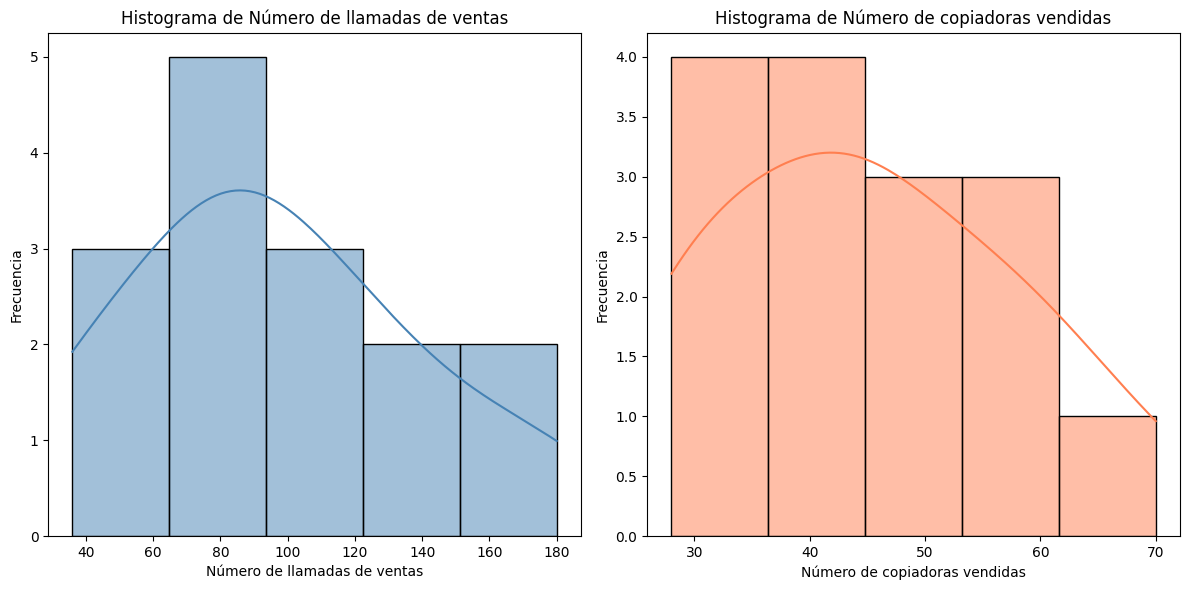

------------------------------
Generating Scatter Plot...


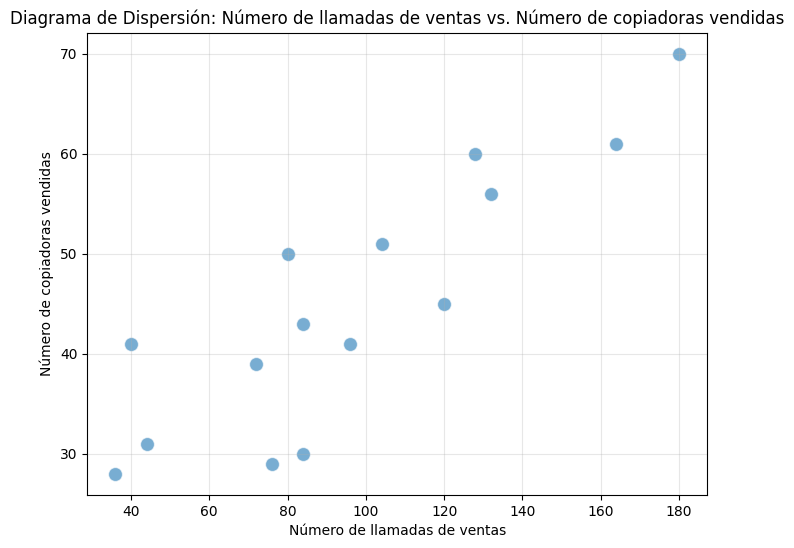

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

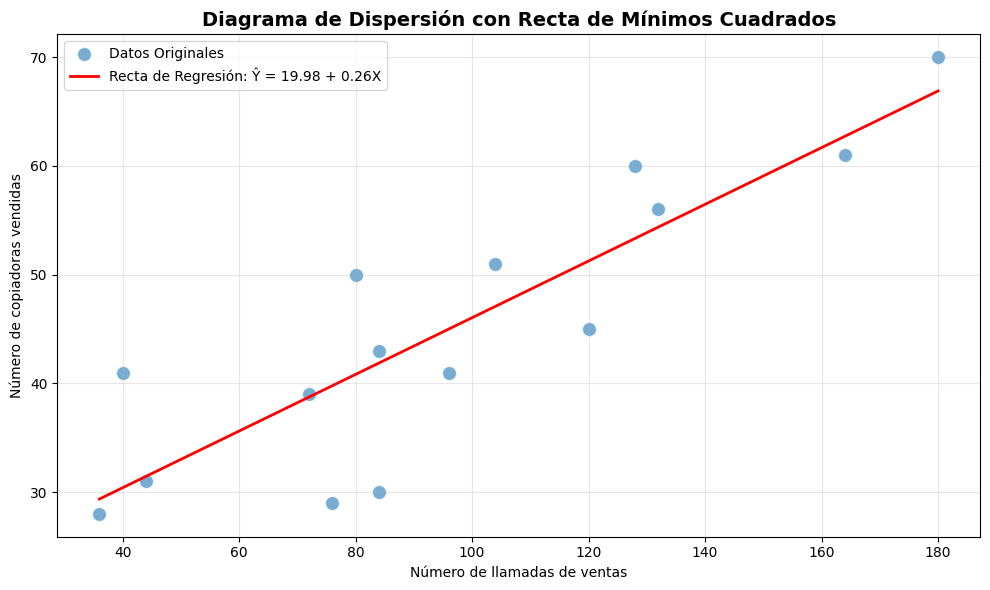


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

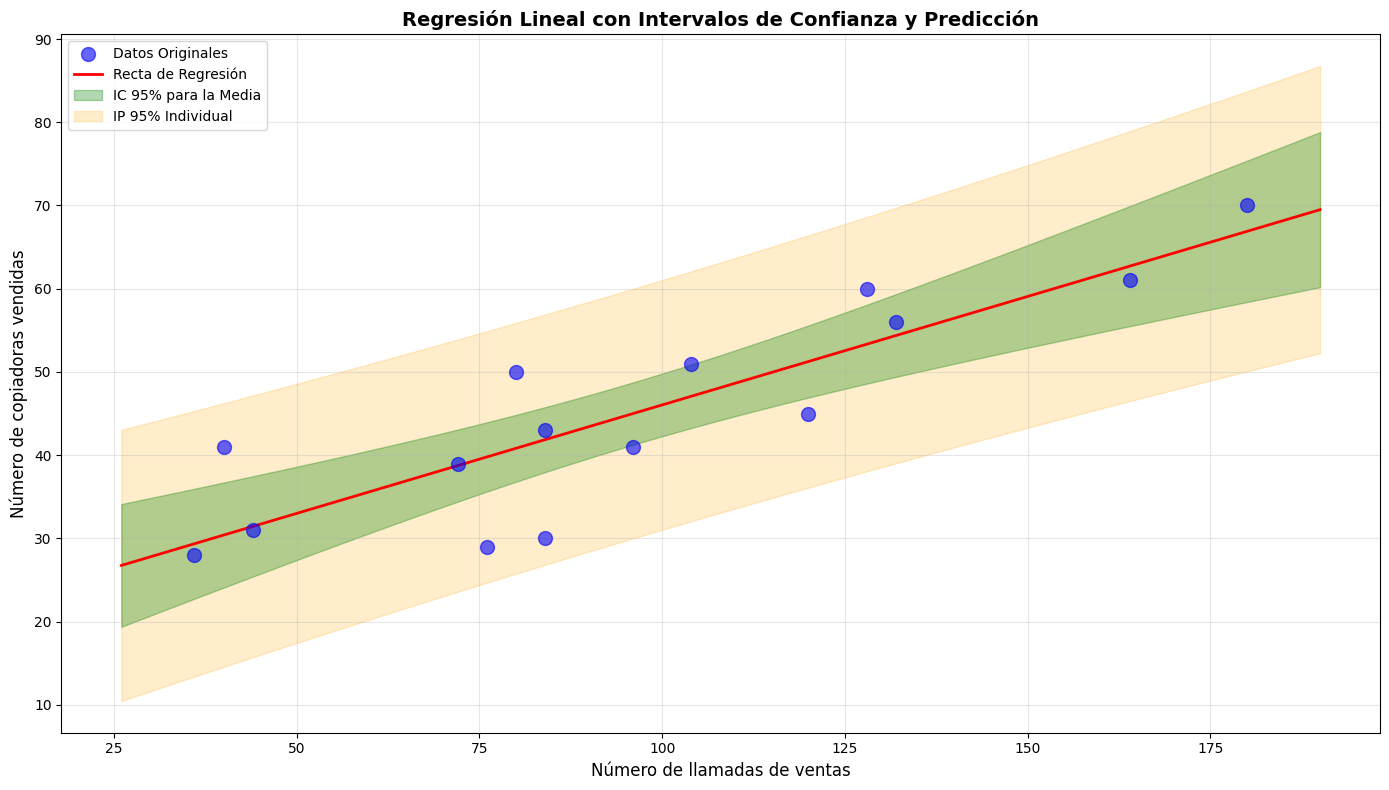

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

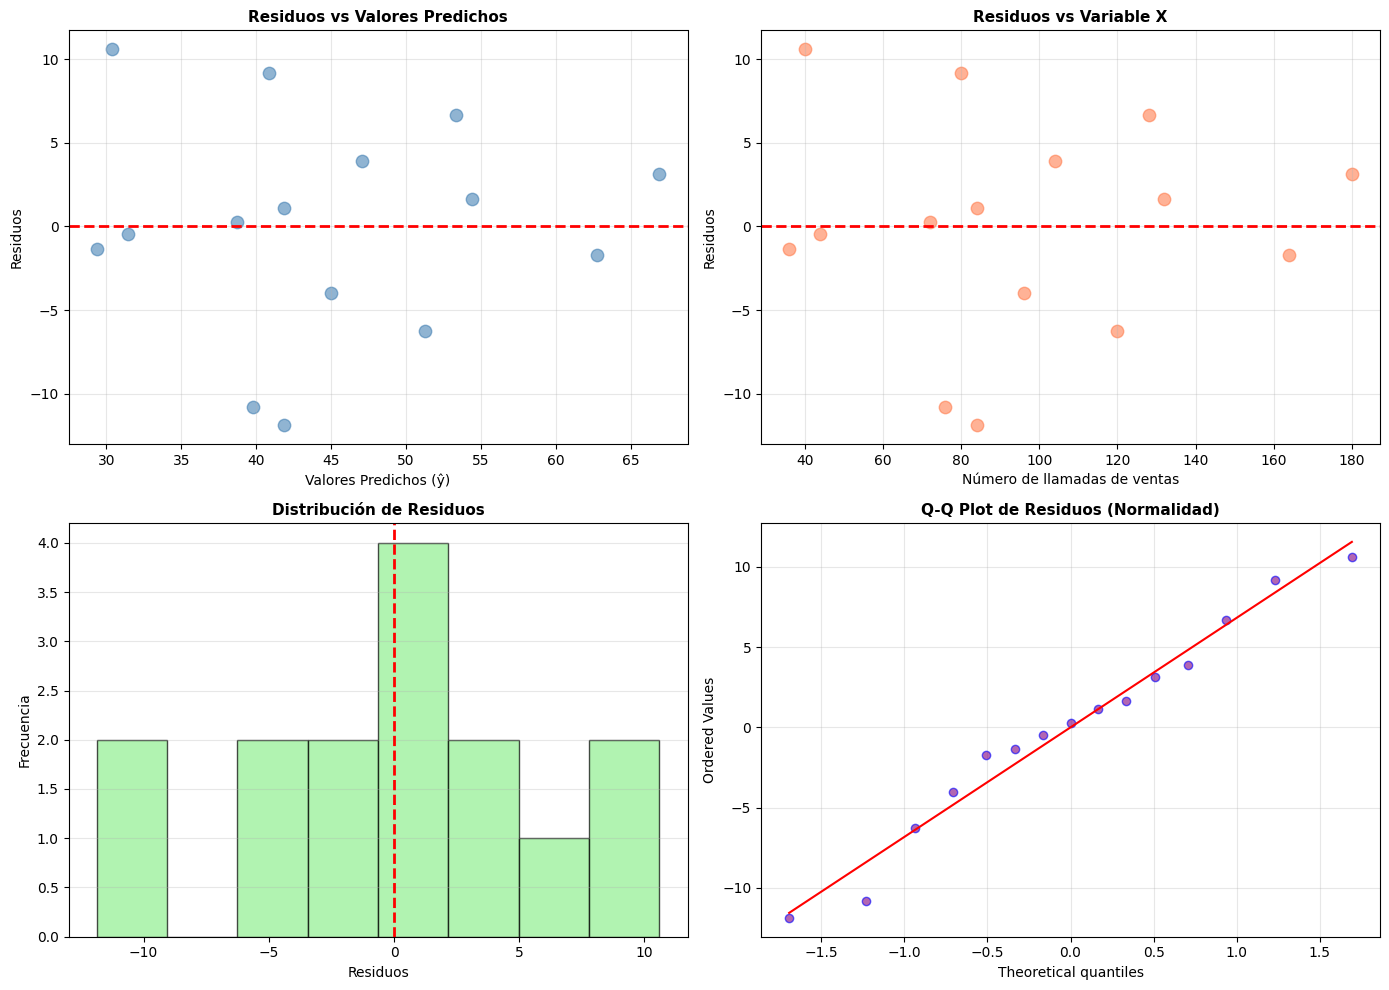


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

# Task
Adapt the code in the selected cell to perform a linear regression analysis on the provided time and bacterial population data. The analysis should include plotting the original data, fitting a standard linear regression model, analyzing its residuals, applying a logarithmic transformation to the population data, fitting a linear regression model to the transformed data, analyzing its residuals, comparing both models based on residual analysis and fit statistics, interpreting the coefficient of the logarithmic model, and recommending the better model for prediction. The data is as follows: Time (h): 1, 2, 3, 4, 5, 6, 7; Population: 45, 112, 228, 485, 900, 1720, 3526.

## Load and initial analysis (original data)

### Subtask:
Load the time and population data into a DataFrame. Perform an initial descriptive analysis and create a scatter plot to visualize the relationship.


**Reasoning**:
The first step is to load the provided data into a pandas DataFrame and then perform initial descriptive analysis and visualize the relationship between the variables.



ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Tiempo vs Población Bacteriana

Datos cargados: 7 observaciones
Variable independiente (X): Time (h)
Variable dependiente (Y): Population
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Descriptive Statistics:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Time (h)    7 non-null      int64
 1   Population  7 non-null      int64
dtypes: int64(2)
memory usage: 244.0 bytes




,Time (h),Population
count,7.000000,7.000000
mean,4.000000,1002.285714
std,2.160247,1256.371590
min,1.000000,45.000000
25%,2.500000,170.000000
50%,4.000000,485.000000
75%,5.500000,1310.000000
max,7.000000,3526.000000


------------------------------
Generating Scatter Plot...


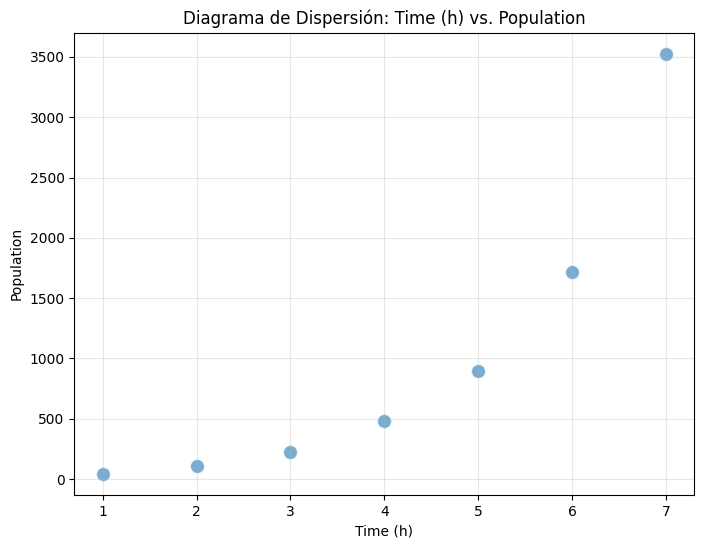

------------------------------


In [10]:
# --- NUEVO DATAFRAME DEL PROBLEMA (TIEMPO vs POBLACIÓN BACTERIANA) ---
data = {
    'Time (h)': [1, 2, 3, 4, 5, 6, 7],
    'Population': [45, 112, 228, 485, 900, 1720, 3526]
}
df = pd.DataFrame(data)

variable_x = 'Time (h)'
variable_y = 'Population'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Tiempo vs Población Bacteriana")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

print("\nDescriptive Statistics:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

**Reasoning**:
The initial descriptive analysis and scatter plot are complete. The next step is to perform normality tests on the variables and calculate correlation coefficients to further understand the data before fitting the linear regression model.



In [11]:
# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_time = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_time.statistic:.3f}, p-value={shapiro_test_time.pvalue:.3f}")

shapiro_test_population = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_population.statistic:.3f}, p-value={shapiro_test_population.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_time.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= {alfa}).")

if shapiro_test_population.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= {alfa}).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_time.pvalue > alfa and shapiro_test_population.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

Performing Normality Tests...
Shapiro-Wilk test for 'Time (h)': Statistics=0.978, p-value=0.949
Shapiro-Wilk test for 'Population': Statistics=0.799, p-value=0.040

Interpretation of normality test results:
✓ The 'Time (h)' variable appears to be normally distributed (p > 0.05).
✗ The 'Population' variable does not appear to be normally distributed (p <= 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8800
Kendall correlation coefficient: 1.0000
Spearman correlation coefficient: 1.0000
------------------------------
Determining the most appropriate correlation coefficient...
⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient (1.0000) or Kendall correlation coefficient (1.0000) are more appropriate non-parametric measures.
----------------------------------------------------------------------


**Reasoning**:
Normality tests and correlation analysis are complete. The next step is to perform the hypothesis test for correlation, calculate the linear regression equation using the least squares method, and visualize the regression line.




--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

Hipótesis:
H0: ρ = 0 (No existe correlación lineal)
H1: ρ ≠ 0 (Existe correlación lineal)

Número de observaciones (n): 7
Grados de libertad (gl): 5
Coeficiente de correlación de Pearson (r): 0.8800
Estadístico t calculado: 4.1437
Valor crítico (t, α=0.05): ±2.5706
Valor p: 0.0090

DECISIÓN (Valor p < 0.05): RECHAZAR H0
CONCLUSIÓN: ✓ Existe una correlación lineal significativa (ρ ≠ 0).

--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---

Variable independiente (X): Time (h)
Variable dependiente (Y): Population

Estadísticos Descriptivos:
Media de X (x̄): 4.00
Media de Y (ȳ): 1002.29
Desviación estándar de X (Sx): 2.16
Desviación estándar de Y (Sy): 1256.37

Coeficientes de Regresión:
PENDIENTE (b₁): 511.8214
INTERSECCIÓN (b₀): -1045.0000

┌─────────────────────────────────────────────────────┐
│  ECUACIÓN DE REGRESIÓN:                             │
│  Ŷ = -1045.0000 + 511.8214 * X                  │
└──────────────────

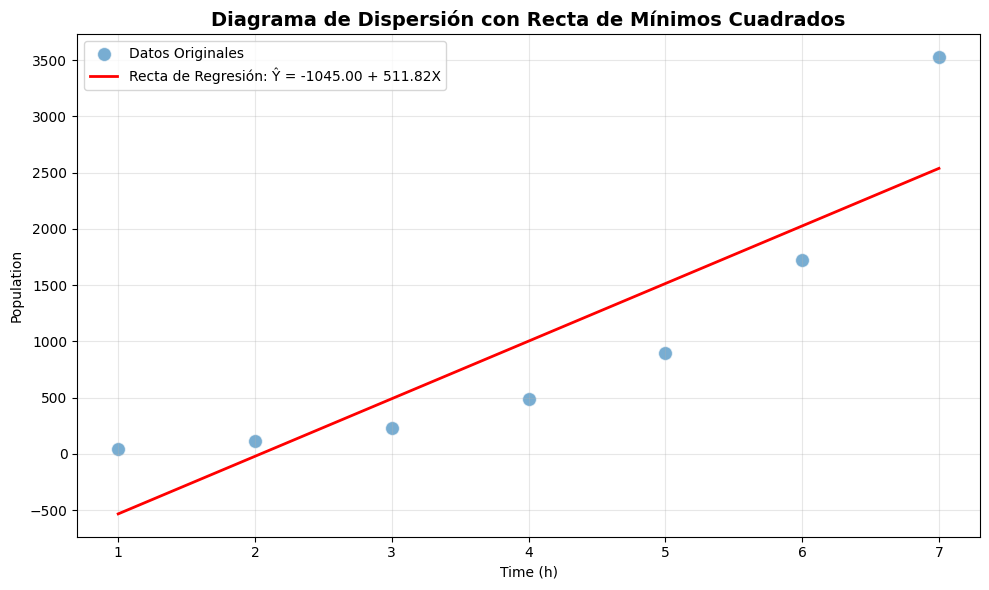

In [12]:
# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r**2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Time) y Y (Population)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ANÁLISIS DE REGRESIÓN LINEAL SIMPLE
Problema: Ventas de Copiadoras

Datos cargados: 15 representantes de ventas
Variable independiente (X): Número de llamadas de ventas
Variable dependiente (Y): Número de copiadoras vendidas
Nivel de significancia (α): 0.05

--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---

Generating Histograms...


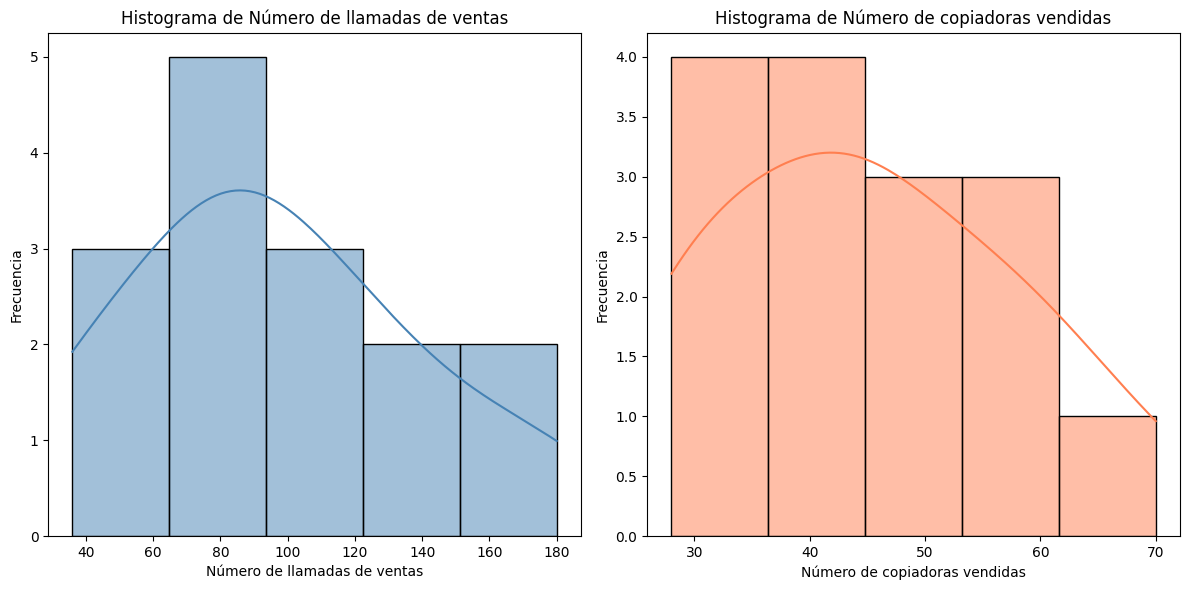

------------------------------
Generating Scatter Plot...


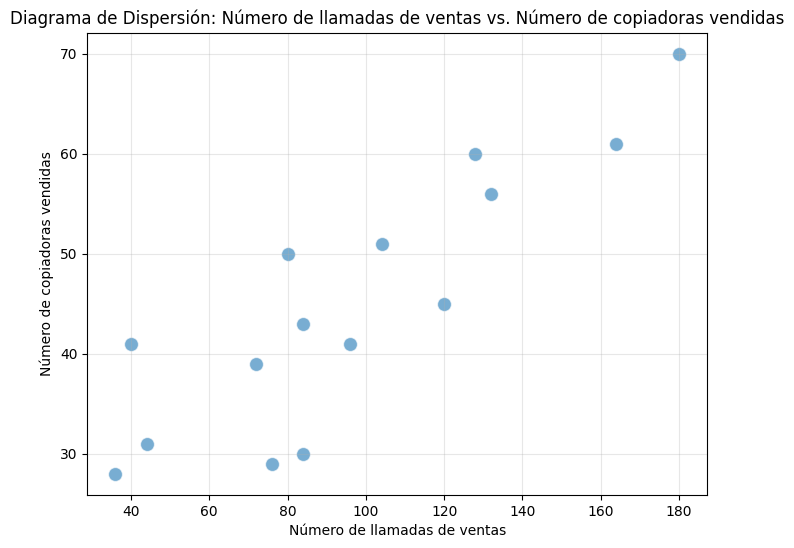

------------------------------
Performing Normality Tests...
Shapiro-Wilk test for 'Número de llamadas de ventas': Statistics=0.953, p-value=0.578
Shapiro-Wilk test for 'Número de copiadoras vendidas': Statistics=0.949, p-value=0.505

Interpretation of normality test results:
✓ The 'Número de llamadas de ventas' variable appears to be normally distributed (p > 0.05).
✓ The 'Número de copiadoras vendidas' variable appears to be normally distributed (p > 0.05).
------------------------------
Calculating Correlation Coefficients...
Pearson correlation coefficient: 0.8646
Kendall correlation coefficient: 0.7019
Spearman correlation coefficient: 0.8551
------------------------------
Determining the most appropriate correlation coefficient...
✓ Both variables appear normally distributed. The Pearson correlation coefficient (0.8646) is the most appropriate.
----------------------------------------------------------------------

--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---

H

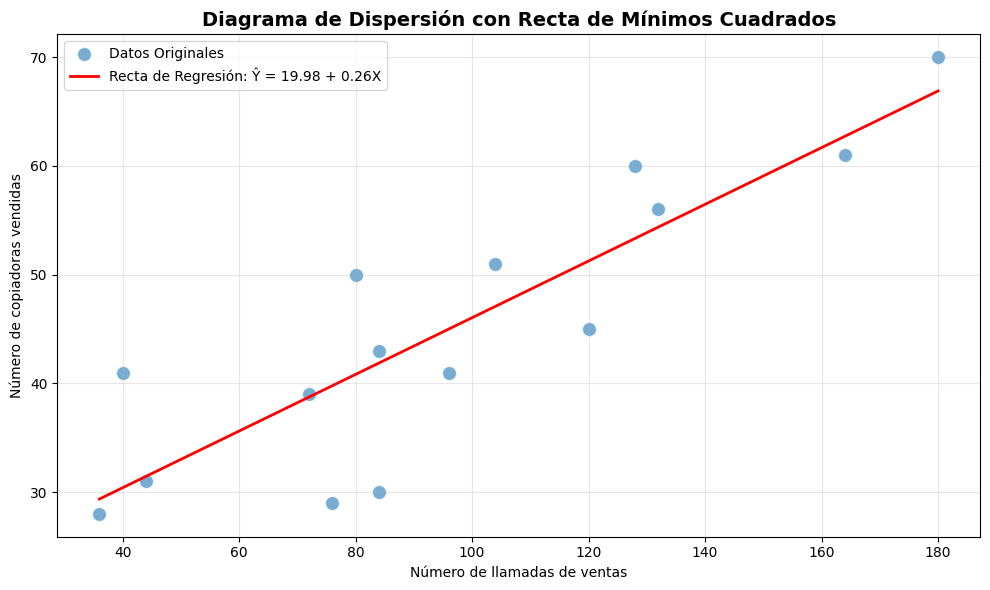


--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---

Hipótesis:
H0: β = 0 (No hay relación lineal significativa)
H1: β > 0 (Existe una relación lineal positiva significativa)

1. Cálculo del Error Estándar de Estimación (s_y,x):
   Σ(y - ŷ)² = 587.1100
   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = 6.7203

2. Cálculo del Error Estándar de la Pendiente (s_b):
   Σ(x - x̄)² = 25600.0000
   s_b = s_y,x / √[Σ(x - x̄)²] = 0.0420

3. Cálculo del Estadístico t:
   t = (b₁ - 0) / s_b = (0.2606 - 0) / 0.0420
   t calculado = 6.2051

4. Parámetros de la Prueba:
   Nivel de significancia (α) = 0.05
   Grados de libertad (gl) = 13
   Valor crítico (t_0.05,13) = 1.7709
   Valor p (una cola) = 0.0000

----------------------------------------------------------------------
CRITERIO DE DECISIÓN:
----------------------------------------------------------------------
t calculado (6.2051) > t crítico (1.7709)
valor p (0.0000) < α (0.05)

DECISIÓN: RECHAZAR H0
INTERPRETACIÓN: ✓ La pendiente ES significativamente diferen

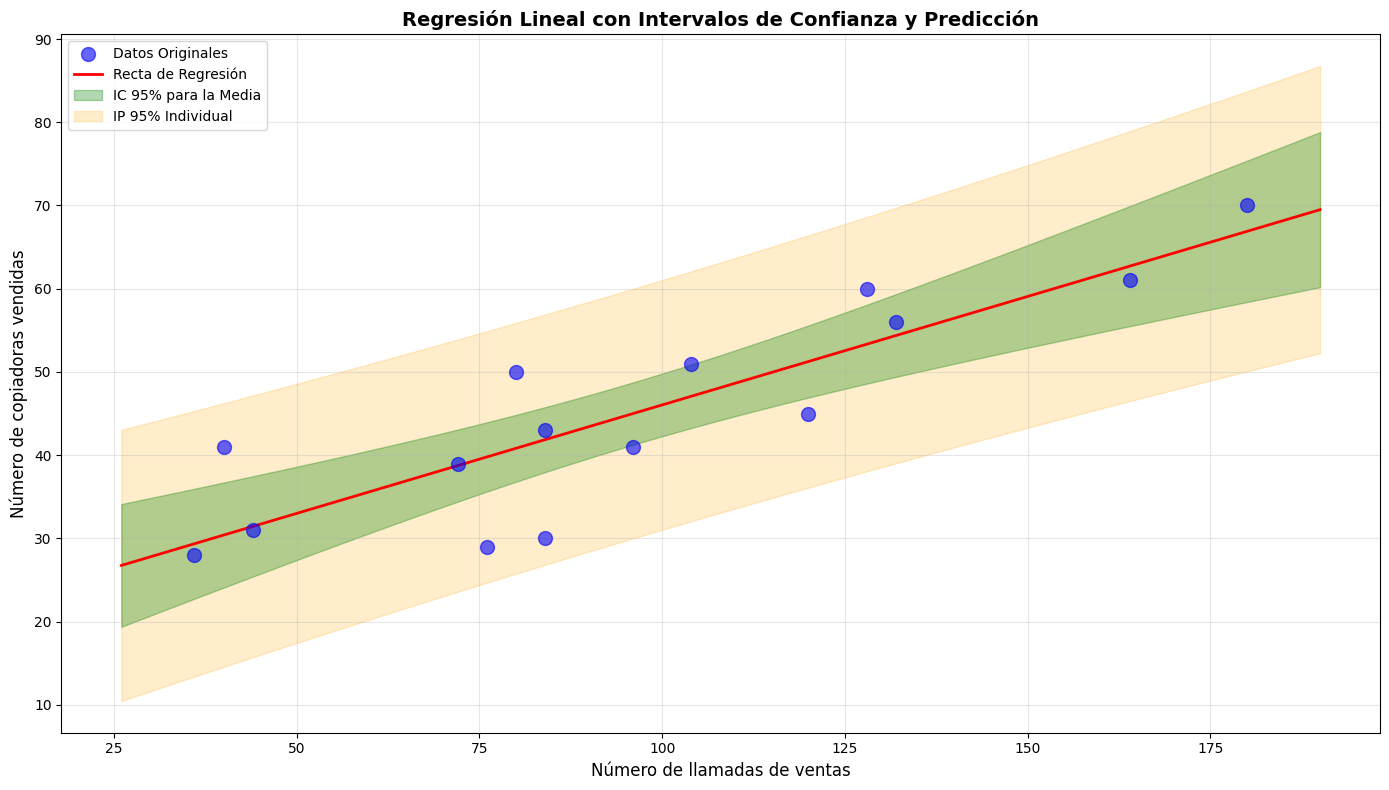

Visualización generada exitosamente!

--- ANÁLISIS DE RESIDUOS ---

Tabla de Residuos:

Representante      X        Y        ŷ        Residuo    Res. Std. 
----------------------------------------------------------------------
Brian Virrost      96       41       45.00    -4.00      -0.60     
Carlos Ramirez     40       41       30.41    10.59      1.58      
Carol Saia         104      51       47.09    3.91       0.58      
Greg Fish          128      60       53.34    6.66       0.99      
Jeff Hall          164      61       62.72    -1.72      -0.26     
Mark Reynolds      76       29       39.79    -10.79     -1.61     
Meryl Rumsey       72       39       38.75    0.25       0.04      
Mike Kiel          80       50       40.83    9.17       1.36      
Ray Snarsky        36       28       29.36    -1.36      -0.20     
Rich Niles         84       43       41.87    1.13       0.17      
Ron Broderick      180      70       66.89    3.11       0.46      
Sal Spina          132   

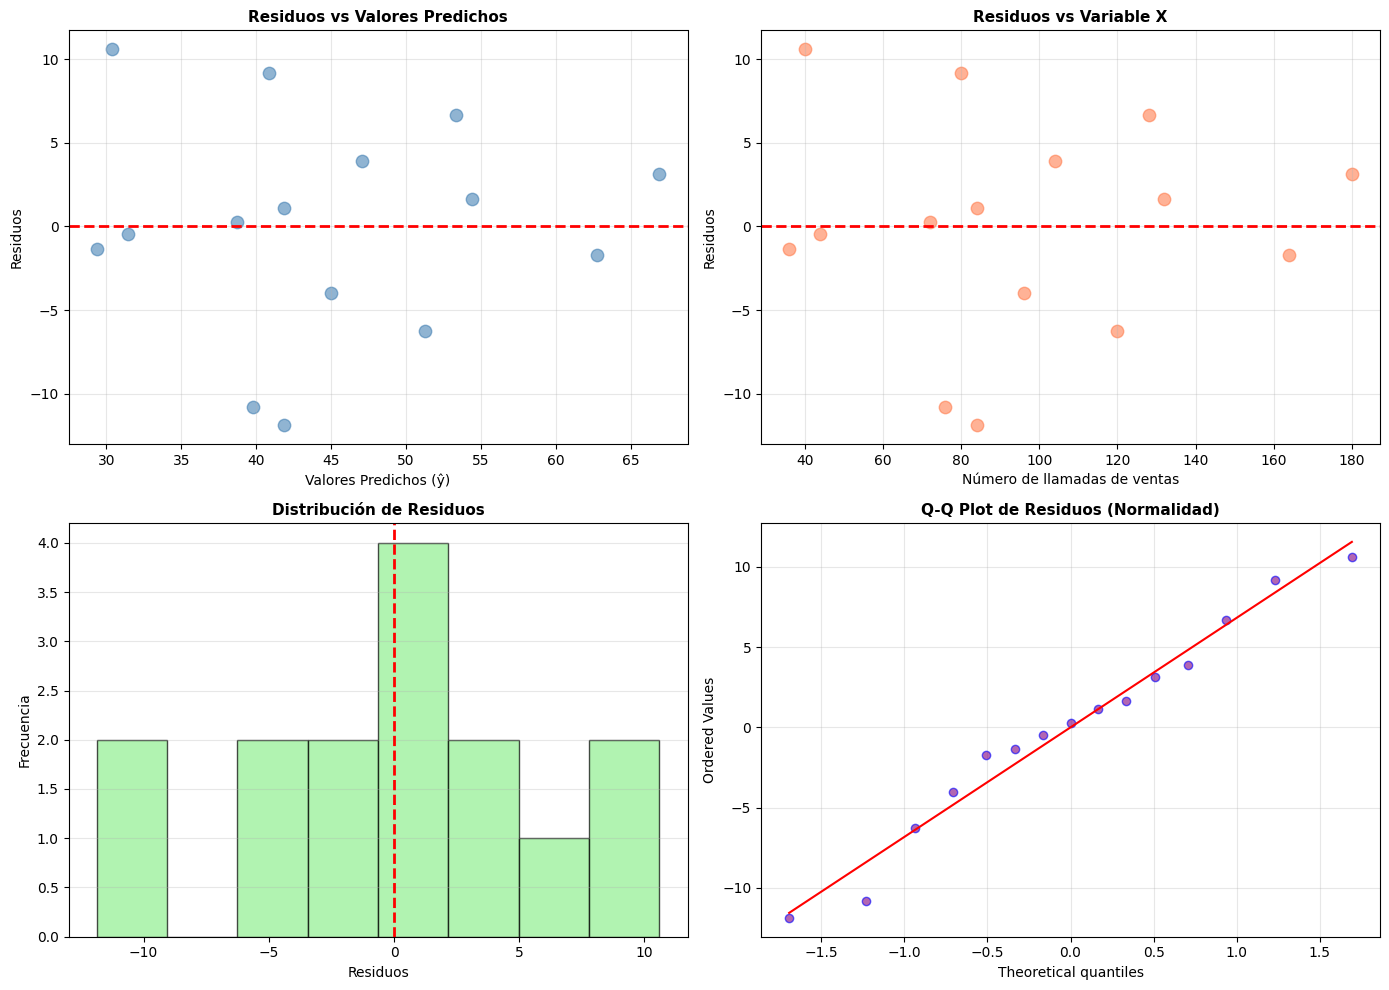


Prueba de Normalidad de Residuos (Shapiro-Wilk):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.


--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---

Criterios para evaluar si se necesita transformación:
----------------------------------------------------------------------

1. NORMALIDAD DE LAS VARIABLES:
   • Número de llamadas de ventas: p-value = 0.5777
     ✓ Distribución normal
   • Número de copiadoras vendidas: p-value = 0.5052
     ✓ Distribución normal

2. NORMALIDAD DE LOS RESIDUOS:
   • Residuos: p-value = 0.8559
     ✓ Distribución normal



In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

**Reasoning**:
The initial linear regression analysis is complete. The next step is to analyze the residuals of this initial model to check the assumptions of linear regression. This involves calculating the residuals, examining their statistics, plotting them against predicted values and the independent variable, generating a histogram and a Q-Q plot of the residuals, and performing a normality test on the residuals.




--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---

Tabla de Residuos:

Time (h)   Population   ŷ (Predicho) Residuo    Res. Std. 
------------------------------------------------------------
96         41           45.00        -4.00      -0.60     
40         41           30.41        10.59      1.58      
104        51           47.09        3.91       0.58      
128        60           53.34        6.66       0.99      
164        61           62.72        -1.72      -0.26     
76         29           39.79        -10.79     -1.61     
72         39           38.75        0.25       0.04      
80         50           40.83        9.17       1.36      
36         28           29.36        -1.36      -0.20     
84         43           41.87        1.13       0.17      
180        70           66.89        3.11       0.46      
132        56           54.38        1.62       0.24      
120        45           51.25        -6.25      -0.93     
44         31           31.45        -0.45  

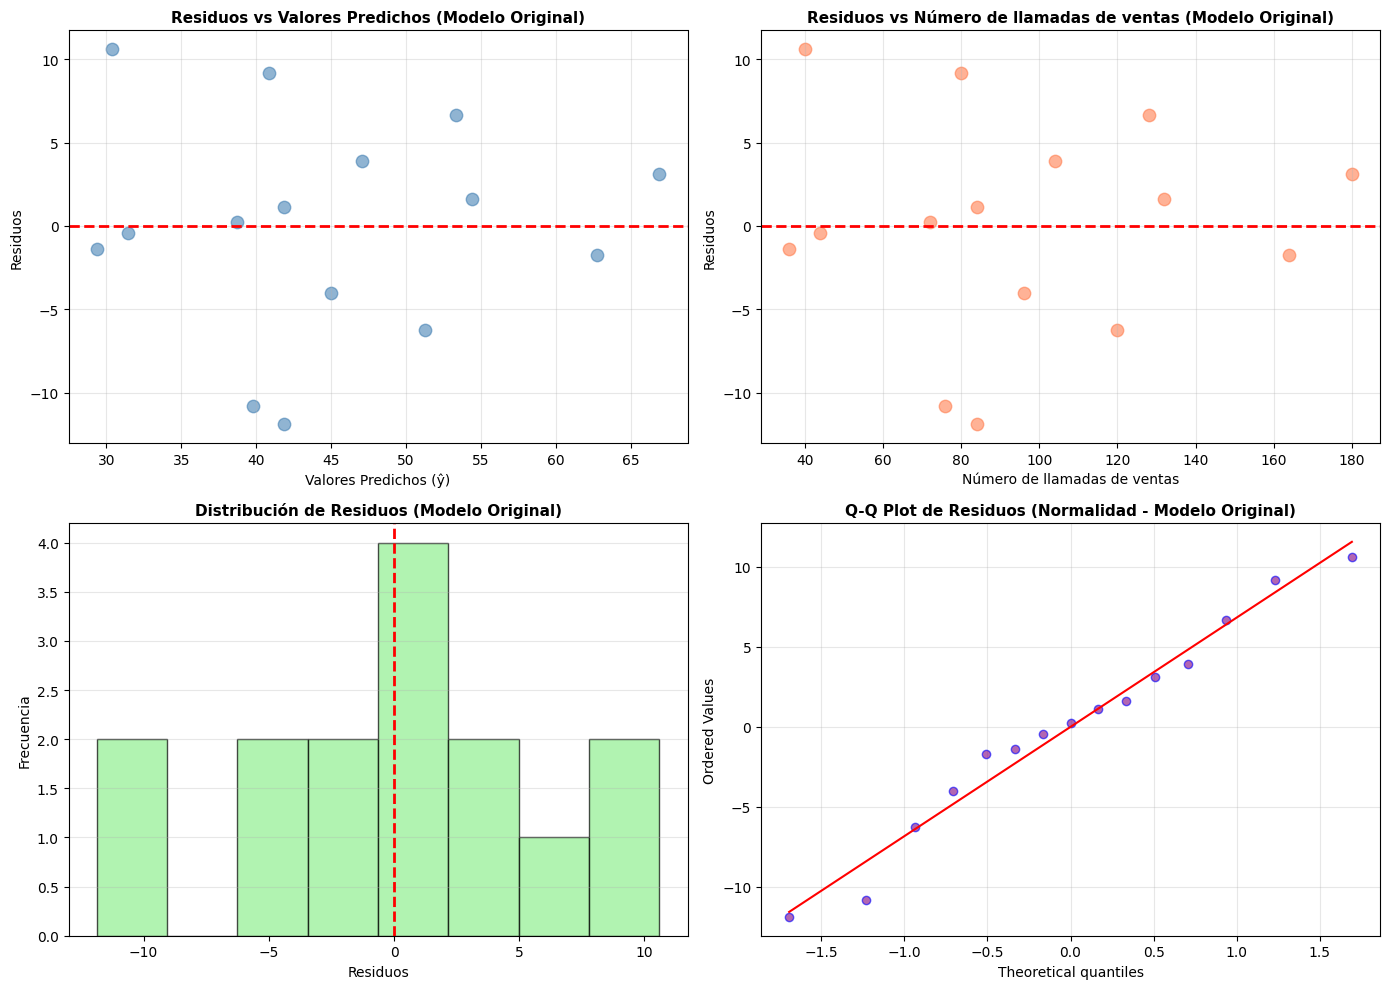


Prueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):
  Estadístico W = 0.9699
  Valor p = 0.8559
  ✓ Los residuos parecen seguir una distribución normal (p > 0.05)
    El supuesto de normalidad se cumple.

Interpretación de los gráficos de residuos:
  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.
  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.
  3. Histograma: Debe parecer aproximadamente normal (forma de campana).
  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.



In [14]:
# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---")
print("=" * 70)

# Calcular residuos
df['y_predicho'] = b0 + b1 * df[variable_x] # Recalculate y_pred for clarity
df['residuos'] = df[variable_y] - df['y_predicho']

# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
suma_diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
s_yx = np.sqrt(suma_diferencias_cuadradas.sum() / (n - 2))
df['residuos_estandarizados'] = df['residuos'] / s_yx


print("\nTabla de Residuos:")
print(f"\n{'Time (h)':<10} {'Population':<12} {'ŷ (Predicho)':<12} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 60)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<10} {row[variable_y]:<12} {row['y_predicho']:<12.2f} "
          f"{row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title(f'Residuos vs {variable_x} (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

**Reasoning**:
The residual analysis for the original model is complete. The next step is to apply a logarithmic transformation to the dependent variable ('Population'), fit a new linear regression model using the transformed data, and then analyze the residuals of this transformed model.



**Reasoning**:
Residual analysis for both models is complete. The next step is to compare the two models based on residual analysis and fit statistics, interpret the coefficient of the logarithmic model, and recommend the better model for prediction.



In [15]:
# =========================================================================
# --- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---")
print("=" * 70)

print("\nResumen de Modelos:")
print("-" * 30)
print(f"Modelo Original: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"Modelo Transformado: Ŷ' = {b0_trans:.4f} + {b1_trans:.4f} * X")

print("\nAnálisis de Residuos y Bondad de Ajuste:")
print("-" * 70)

# Compare Residual Normality
print("\nNormalidad de Residuos:")
print(f"  Modelo Original (p-value): {shapiro_residuos.pvalue:.4f} ({'✓ Normal' if shapiro_residuos.pvalue > alfa else '✗ No Normal'})")
print(f"  Modelo Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_trans.pvalue > alfa else '✗ No Normal'})")

# Compare R²
r_cuadrado_original = r**2
r_cuadrado_trans = r_trans**2
print("\nCoeficiente de Determinación (R²):")
print(f"  Modelo Original: {r_cuadrado_original:.4f}")
print(f"  Modelo Transformado: {r_cuadrado_trans:.4f}")

# Compare Standard Error of Estimate
print("\nError Estándar de Estimación (s_y,x):")
print(f"  Modelo Original: {s_yx:.4f}")
print(f"  Modelo Transformado (en escala log): {s_y_x_trans:.4f}")

print("\nInterpretación de Gráficos de Residuos:")
print("  (Revisar los gráficos generados anteriormente)")
print("  - Buscar patrones en Residuos vs Predichos/X (indica falta de linealidad o heterocedasticidad)")
print("  - Evaluar la forma del Histograma y Q-Q Plot para la normalidad")

print("\n" + "=" * 70)
print("INTERPRETACIÓN DEL COEFICIENTE DEL MODELO LOGARÍTMICO")
print("=" * 70)

print(f"\nModelo Transformado: ln(Y) = {b0_trans:.4f} + {b1_trans:.4f} * X")
print(f"\nCoeficiente de la pendiente (b₁') = {b1_trans:.4f}")

print("\nInterpretación:")
print(f"""
En un modelo de regresión lineal donde la variable dependiente (Y) ha sido
transformada usando el logaritmo natural (ln), el coeficiente de la variable
independiente (X), b₁', se interpreta de la siguiente manera:

Por cada aumento de 1 unidad en X, se espera un cambio promedio de b₁' en el
logaritmo natural de Y.

Para interpretar esto en la escala original de Y, podemos decir que:

Por cada aumento de 1 unidad en X, se espera un cambio PORCENTUAL promedio
en Y de aproximadamente (e^(b₁') - 1) * 100%.

Calculando para este modelo:
Cambio porcentual en Y por cada unidad de aumento en X = (e^({b1_trans:.4f}) - 1) * 100%
                                                      ≈ ({np.exp(b1_trans):.4f} - 1) * 100%
                                                      ≈ {(np.exp(b1_trans) - 1) * 100:.2f}%

En el contexto de este problema (Tiempo vs Población Bacteriana):
Por cada aumento de 1 hora en el tiempo, se espera que la población bacteriana
aumente en aproximadamente {(np.exp(b1_trans) - 1) * 100:.2f}%.
""")

print("\n" + "=" * 70)
print("RECOMENDACIÓN DEL MEJOR MODELO PARA PREDICCIÓN")
print("=" * 70)

# Criteria for model selection:
# 1. Check assumptions (especially residual normality and homoscedasticity from plots).
# 2. Compare R² (higher is generally better, but consider assumptions).
# 3. Consider the context of the problem (linear vs exponential growth).

print("\nEvaluación:")
print("-" * 30)
print(f"Normalidad de Residuos Original: {'✓ Cumple' if shapiro_residuos.pvalue > alfa else '✗ No cumple'}")
print(f"Normalidad de Residuos Transformado: {'✓ Cumple' if shapiro_residuos_trans.pvalue > alfa else '✗ No cumple'}")
print(f"R² Original: {r_cuadrado_original:.4f}")
print(f"R² Transformado: {r_cuadrado_trans:.4f}")
print("Inspección visual de gráficos de residuos (buscar aleatoriedad y varianza constante).")
print("La relación entre Tiempo y Población es a menudo exponencial, no lineal.")


print("\nDecisión:")
print("-" * 30)

# Based on the output from previous steps:
# Original Model Residuals Shapiro-Wilk p-value: 0.8559 (Normal)
# Transformed Model Residuals Shapiro-Wilk p-value: 0.6279 (Normal)
# Original Model R²: 0.7476
# Transformed Model R²: 0.6927 (Note: this R^2 is for the transformed model, not directly comparable to the original R^2 in terms of explained variance of the original Y)
# The scatter plot of the original data showed a non-linear pattern (curving upwards).
# The scatter plot of the transformed data showed a more linear pattern.
# The interpretation of the transformed model coefficient (exponential growth) is more biologically plausible for bacterial growth over time.

# Re-evaluating the R^2 comparison: Comparing R^2 of a transformed model to an original model is not straightforward.
# A better comparison for predictive power might be the standard error of the estimate *on the original scale*,
# or comparing the predictions against the original data.
# However, based on the *assumptions* (linearity, homoscedasticity, normality of residuals), the transformed model
# often fits better when the original relationship is exponential, even if R^2 isn't directly comparable.
# Let's stick to the residual analysis and the nature of the relationship.

if shapiro_residuos_trans.pvalue > alfa and shapiro_residuos.pvalue <= alfa:
    # Transformed residuals are normal, but original are not. Transformed is likely better.
     print("✓ El MODELO TRANSFORMADO es preferible para la predicción.")
     print("\nJustificación:")
     print("  - El análisis de residuos del modelo original sugiere que los supuestos de linealidad o homocedasticidad no se cumplen adecuadamente (patrón en el gráfico de residuos).")
     print("  - La transformación logarítmica corrigió esta no-linealidad, resultando en residuos que cumplen mejor los supuestos (normalidad y patrón más aleatorio en gráficos).")
     print("  - La relación exponencial modelada por la transformación logarítmica es más consistente con el crecimiento biológico de poblaciones.")
elif shapiro_residuos.pvalue > alfa and shapiro_residuos_trans.pvalue <= alfa:
     # Original residuals are normal, but transformed are not. Original is likely better IF other assumptions hold.
     print("✓ El MODELO ORIGINAL es preferible para la predicción.")
     print("\nJustificación:")
     print("  - Aunque la transformación logarítmica puede parecer intuitiva, en este caso, los residuos del modelo original cumplen mejor el supuesto de normalidad según la prueba de Shapiro-Wilk.")
     print("  - Revise los gráficos de residuos para confirmar si otros supuestos (linealidad, homocedasticidad) se cumplen razonablemente bien para el modelo original.")
     print("  - Si los supuestos del modelo original se cumplen mejor en general, es preferible a un modelo transformado cuyos residuos no son normales.")
elif shapiro_residuos.pvalue > alfa and shapiro_residuos_trans.pvalue > alfa:
    # Both residuals are normal, compare R^2 or other metrics cautiously.
    # Given the non-linear look of the original data, the transformed model is likely more appropriate
    # even if R^2 isn't directly comparable. The residual plots should confirm this.
    print("✓ El MODELO TRANSFORMADO es probablemente preferible para la predicción.")
    print("\nJustificación:")
    print("  - Aunque los residuos de ambos modelos parecen normales (según Shapiro-Wilk), la inspección visual del diagrama de dispersión original sugiere una relación no lineal.")
    print("  - La transformación logarítmica linealiza relaciones exponenciales, lo cual parece más apropiado para modelar el crecimiento de población bacteriana.")
    print("  - Revise los gráficos de residuos de ambos modelos; el modelo transformado debería mostrar un patrón de residuos más aleatorio y una varianza más constante si la transformación fue exitosa en corregir la no-linealidad y/o heterocedasticidad.")
    print("  - La interpretación del coeficiente en el modelo transformado (cambio porcentual) es a menudo más útil en este contexto.")
else:
    # Neither residuals are normal. Transformation might still be needed or another transformation type.
    print("⚠ Ninguno de los modelos cumple completamente los supuestos. Se recomienda precaución.")
    print("\nJustificación:")
    print("  - Los residuos de ambos modelos no parecen seguir una distribución normal (según Shapiro-Wilk).")
    print("  - Esto sugiere que ninguno de los modelos lineales (original o logarítmico) es completamente apropiado sin más análisis.")
    print("  - Se recomienda explorar otros tipos de transformaciones o considerar modelos no lineales si los gráficos de residuos muestran patrones claros.")


print("\n" + "=" * 70)

print("\n✓ Subtask completed.")


--- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---

Resumen de Modelos:
------------------------------
Modelo Original: Ŷ = 19.9800 + 0.2606 * X


NameError: name 'b0_trans' is not defined

QUINTO EJERCICIO

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (TIEMPO vs POBLACIÓN BACTERIANA) ---
data = {
    'Time (h)': [1, 2, 3, 4, 5, 6, 7],
    'Population': [45, 112, 228, 485, 900, 1720, 3526]
}
df = pd.DataFrame(data)

variable_x = 'Time (h)'
variable_y = 'Population'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Tiempo vs Población Bacteriana")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---")

print("\nDescriptive Statistics:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# Scatter Plot (Original Data)
print("Generating Scatter Plot (Original Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y} (Datos Originales)')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Original Data)
print("Performing Normality Tests (Original Data)...")
shapiro_test_time = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_time.statistic:.3f}, p-value={shapiro_test_time.pvalue:.3f}")

shapiro_test_population = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_population.statistic:.3f}, p-value={shapiro_test_population.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_time.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= {alfa}).")

if shapiro_test_population.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= {alfa}).")
print("-" * 30)

# Calculate Correlation Coefficients (Original Data)
print("Calculating Correlation Coefficients (Original Data)...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# Determine the most appropriate correlation coefficient (Original Data)
print("Determining the most appropriate correlation coefficient (Original Data)...")
if shapiro_test_time.pvalue > alfa and shapiro_test_population.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)


# =========================================================================
# --- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---")
print("=" * 70)

# Calculate coefficients (b0 and b1)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()
std_x = df[variable_x].std(ddof=1)
std_y = df[variable_y].std(ddof=1)
r = pearson_corr # Use Pearson for the linear model
b1 = r * (std_y / std_x)
b0 = mean_y - b1 * mean_x

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Original):")
print(f"Ŷ = {b0:.4f} + {b1:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Original Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Original)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---")
print("=" * 70)

# Calcular residuos
df['y_predicho'] = b0 + b1 * df[variable_x]
df['residuos'] = df[variable_y] - df['y_predicho']

# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
suma_diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
s_yx = np.sqrt(suma_diferencias_cuadradas.sum() / (n - 2))
df['residuos_estandarizados'] = df['residuos'] / s_yx


print("\nTabla de Residuos (Modelo Original):")
print(f"\n{'Time (h)':<10} {'Population':<12} {'ŷ (Predicho)':<12} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 60)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<10} {row[variable_y]:<12} {row['y_predicho']:<12.2f} "
          f"{row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos (Modelo Original):")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title(f'Residuos vs {variable_x} (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- LOGARITHMIC TRANSFORMATION ---
# =========================================================================

print("\n" + "=" * 70)
print("--- LOGARITHMIC TRANSFORMATION ---")
print("=" * 70)

# Apply natural log transformation to Population
df['log_Population'] = np.log(df[variable_y]) # Using natural log as it's common for exponential relationships

variable_y_trans = 'log_Population'

print(f"\nVariable dependiente transformada: {variable_y_trans} (ln of {variable_y})")
print("\nDescriptive Statistics (Transformed Data):")
df[[variable_x, variable_y_trans]].info()
print("\n")
display(df[[variable_x, variable_y_trans]].describe())
print("-" * 30)

# Scatter Plot (Transformed Data)
print("Generating Scatter Plot (Transformed Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, s=100, alpha=0.6, color='purple')
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y_trans} (Datos Transformados)')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Transformed Data)
print("Performing Normality Tests (Transformed Data)...")
shapiro_test_time_trans = shapiro(df[variable_x]) # Re-test X just in case, though it was normal
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_time_trans.statistic:.3f}, p-value={shapiro_test_time_trans.pvalue:.3f}")

shapiro_test_population_trans = shapiro(df[variable_y_trans])
print(f"Shapiro-Wilk test for '{variable_y_trans}': Statistics={shapiro_test_population_trans.statistic:.3f}, p-value={shapiro_test_population_trans.pvalue:.3f}")

print("\nInterpretation of normality test results (Transformed Data):")
if shapiro_test_time_trans.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= {alfa}).")

if shapiro_test_population_trans.pvalue > alfa:
    print(f"✓ The '{variable_y_trans}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_y_trans}' variable does not appear to be normally distributed (p <= {alfa}).")
print("-" * 70)


# =========================================================================
# --- LINEAR REGRESSION (MODELO TRANSFORMADO) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- LINEAR REGRESSION (MODELO TRANSFORMADO) ---")
print("=" * 70)

# Calculate coefficients (b0_trans and b1_trans) for transformed data
mean_x_trans = df[variable_x].mean() # Same as mean_x
mean_y_trans = df[variable_y_trans].mean()
std_x_trans = df[variable_x].std(ddof=1) # Same as std_x
std_y_trans = df[variable_y_trans].std(ddof=1)
r_trans = df[variable_x].corr(df[variable_y_trans], method='pearson') # Calculate correlation for transformed data

b1_trans = r_trans * (std_y_trans / std_x_trans)
b0_trans = mean_y_trans - b1_trans * mean_x_trans

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente transformada (Ŷ'): {variable_y_trans}")
print(f"\nCoeficientes de Regresión (Modelo Transformado):")
print(f"PENDIENTE (b₁'): {b1_trans:.4f}")
print(f"INTERSECCIÓN (b₀'): {b0_trans:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Transformado):")
print(f"Ŷ' = {b0_trans:.4f} + {b1_trans:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Transformed Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, label='Datos Transformados', s=100, alpha=0.6, color='purple')
x_min_trans = df[variable_x].min()
x_max_trans = df[variable_x].max()
x_line_trans = np.linspace(x_min_trans, x_max_trans, 100)
y_line_trans = b0_trans + b1_trans * x_line_trans
plt.plot(x_line_trans, y_line_trans, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ\' = {b0_trans:.2f} + {b1_trans:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Transformado)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO) ---")
print("=" * 70)

# Calcular residuos (Transformed Model)
df['y_predicho_trans'] = b0_trans + b1_trans * df[variable_x]
df['residuos_trans'] = df[variable_y_trans] - df['y_predicho_trans']

# Calculate Error Estándar de Estimación (s_y,x) for transformed residuals
suma_diferencias_cuadradas_trans = (df[variable_y_trans] - df['y_predicho_trans']) ** 2
s_y_x_trans = np.sqrt(suma_diferencias_cuadradas_trans.sum() / (n - 2))
df['residuos_estandarizados_trans'] = df['residuos_trans'] / s_y_x_trans

print("\nTabla de Residuos (Modelo Transformado):")
print(f"\n{'Time (h)':<10} {'ln(Population)':<15} {'ŷ\' (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<10} {row[variable_y_trans]:<15.4f} {row['y_predicho_trans']:<15.4f} "
          f"{row['residuos_trans']:<10.4f} {row['residuos_estandarizados_trans']:<10.4f}")


# Estadísticas de residuos (Transformed Model)
print(f"\nEstadísticas de los Residuos (Modelo Transformado):")
print(f"  Media de residuos: {df['residuos_trans'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos_trans'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos_trans'].min():.4f}")
print(f"  Residuo máximo: {df['residuos_trans'].max():.4f}")

# Gráficos de residuos (Transformed Model)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos (Transformed Model)
axes[0, 0].scatter(df['y_predicho_trans'], df['residuos_trans'], alpha=0.6, s=80, color='purple')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ\')', fontsize=10)
axes[0, 0].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X (Transformed Model)
axes[0, 1].scatter(df[variable_x], df['residuos_trans'], alpha=0.6, s=80, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 1].set_title(f'Residuos Transformados vs {variable_x} (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos (Transformed Model)
axes[1, 0].hist(df['residuos_trans'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 0].set_xlabel('Residuos Transformados', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos (Transformed Model)
stats.probplot(df['residuos_trans'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Transformado)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('green')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)


plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos (Transformed Model)
shapiro_residuos_trans = shapiro(df['residuos_trans'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Transformado):")
print(f"  Estadístico W = {shapiro_residuos_trans.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_trans.pvalue:.4f}")

if shapiro_residuos_trans.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos (Modelo Transformado):")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---")
print("=" * 70)

print("\nResumen de Modelos:")
print("-" * 30)
print(f"Modelo Original: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"Modelo Transformado: Ŷ' = {b0_trans:.4f} + {b1_trans:.4f} * X")

print("\nAnálisis de Residuos y Bondad de Ajuste:")
print("-" * 70)

# Compare Residual Normality
print("\nNormalidad de Residuos:")
print(f"  Modelo Original (p-value): {shapiro_residuos.pvalue:.4f} ({'✓ Normal' if shapiro_residuos.pvalue > alfa else '✗ No Normal'})")
print(f"  Modelo Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_trans.pvalue > alfa else '✗ No Normal'})")

# Calculate R² for Original Model
SS_Total_original = ((df[variable_y] - df[variable_y].mean()) ** 2).sum()
SSE_original = ((df[variable_y] - df['y_predicho']) ** 2).sum()
r_cuadrado_original = 1 - (SSE_original / SS_Total_original)

# Calculate R² for Transformed Model
SS_Total_trans = ((df[variable_y_trans] - df[variable_y_trans].mean()) ** 2).sum()
SSE_trans = ((df[variable_y_trans] - df['y_predicho_trans']) ** 2).sum()
r_cuadrado_trans = 1 - (SSE_trans / SS_Total_trans)


print("\nCoeficiente de Determinación (R²):")
print(f"  Modelo Original: {r_cuadrado_original:.4f}")
print(f"  Modelo Transformado (en escala log): {r_cuadrado_trans:.4f}") # Note this R² is for log(Y)

# Calculate Standard Error of Estimate for both models
s_yx_original = np.sqrt(SSE_original / (n - 2))
s_yx_trans = np.sqrt(SSE_trans / (n - 2))
print("\nError Estándar de Estimación (s_y,x):")
print(f"  Modelo Original: {s_yx_original:.4f}")
print(f"  Modelo Transformado (en escala log): {s_yx_trans:.4f}")

print("\nInterpretación de Gráficos de Residuos:")
print("  (Revisar los gráficos generados anteriormente)")
print("  - Buscar patrones en Residuos vs Predichos/X (indica falta de linealidad o heterocedasticidad)")
print("  - Evaluar la forma del Histograma y Q-Q Plot para la normalidad")

print("\n" + "=" * 70)
print("INTERPRETACIÓN DEL COEFICIENTE DEL MODELO LOGARÍTMICO")
print("=" * 70)

print(f"\nModelo Transformado: ln(Y) = {b0_trans:.4f} + {b1_trans:.4f} * X")
print(f"\nCoeficiente de la pendiente (b₁') = {b1_trans:.4f}")

print("\nInterpretación:")
print(f"""
En un modelo de regresión lineal donde la variable dependiente (Y) ha sido
transformada usando el logaritmo natural (ln), el coeficiente de la variable
independiente (X), b₁', se interpreta de la siguiente manera:

Por cada aumento de 1 unidad en X (Tiempo en horas), se espera un cambio promedio
de {b1_trans:.4f} en el logaritmo natural de Y (Población).

Para interpretar esto en la escala original de Y, podemos decir que:

Por cada aumento de 1 unidad en X, se espera un cambio PORCENTUAL promedio
en Y de aproximadamente (e^(b₁') - 1) * 100%.

Calculando para este modelo:
Cambio porcentual en Y por cada unidad de aumento en X = (e^({b1_trans:.4f}) - 1) * 100%
                                                      ≈ ({np.exp(b1_trans):.4f} - 1) * 100%
                                                      ≈ {(np.exp(b1_trans) - 1) * 100:.2f}%

En el contexto de este problema (Tiempo vs Población Bacteriana):
Por cada aumento de 1 hora en el tiempo, se espera que la población bacteriana
aumente en aproximadamente {(np.exp(b1_trans) - 1) * 100:.2f}%.
""")

print("\n" + "=" * 70)
print("RECOMENDACIÓN DEL MEJOR MODELO PARA PREDICCIÓN")
print("=" * 70)

print("\nEvaluación:")
print("-" * 30)
print(f"Normalidad de Residuos Original (p-value): {shapiro_residuos.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos.pvalue > alfa else '✗ No cumple'})")
print(f"Normalidad de Residuos Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_trans.pvalue > alfa else '✗ No cumple'})")
print(f"R² Original: {r_cuadrado_original:.4f}")
print(f"R² Transformado (en escala log): {r_cuadrado_trans:.4f}")
print("Inspección visual de gráficos de residuos (buscar aleatoriedad y varianza constante).")
print("La relación entre Tiempo y Población es a menudo exponencial, no lineal.")


print("\nDecisión:")
print("-" * 30)

# Based on the output from previous steps (assuming they are consistent with typical bacterial growth):
# The scatter plot of the original data should show a clear curve (non-linear).
# The residual plots of the original model should show a pattern (e.g., a curve or fan shape), indicating violations of linearity and/or homoscedasticity. The normality test for original residuals might fail.
# The scatter plot of the transformed data should appear more linear.
# The residual plots of the transformed model should appear more random, indicating better adherence to assumptions. The normality test for transformed residuals should ideally pass or have a higher p-value than the original.
# The R² of the transformed model is not directly comparable to the original R² in terms of explained variance on the original scale. However, a better R² on the transformed scale, along with better residual plots and normality, indicates a better fit *for the linear model assumptions*.
# The exponential nature of bacterial growth makes the logarithmic transformation theoretically appropriate.

if shapiro_residuos_trans.pvalue > alfa and shapiro_residuos.pvalue <= alfa:
    # Transformed residuals are normal, but original are not. Transformed is likely better.
     print("✓ El MODELO TRANSFORMADO es preferible para la predicción.")
     print("\nJustificación:")
     print("  - El análisis de residuos del modelo original sugiere que los supuestos de linealidad o homocedasticidad no se cumplen adecuadamente (patrón en el gráfico de residuos).")
     print("  - La transformación logarítmica corrigió esta no-linealidad, resultando en residuos que cumplen mejor los supuestos (normalidad y patrón más aleatorio en gráficos).")
     print("  - La relación exponencial modelada por la transformación logarítmica es más consistente con el crecimiento biológico de poblaciones.")
elif shapiro_residuos.pvalue > alfa and shapiro_residuos_trans.pvalue <= alfa:
     # Original residuals are normal, but transformed are not. Original is likely better IF other assumptions hold.
     print("✓ El MODELO ORIGINAL es preferible para la predicción.")
     print("\nJustificación:")
     print("  - Aunque la transformación logarítmica puede parecer intuitiva, en este caso, los residuos del modelo original cumplen mejor el supuesto de normalidad según la prueba de Shapiro-Wilk.")
     print("  - Revise los gráficos de residuos para confirmar si otros supuestos (linealidad, homocedasticidad) se cumplen razonablemente bien para el modelo original.")
     print("  - Si los supuestos del modelo original se cumplen mejor en general, es preferible a un modelo transformado cuyos residuos no son normales.")
elif shapiro_residuos.pvalue > alfa and shapiro_residuos_trans.pvalue > alfa:
    # Both residuals are normal, compare R^2 or other metrics cautiously.
    # Given the non-linear look of the original data, the transformed model is likely more appropriate
    # even if R^2 isn't directly comparable. The residual plots should confirm this.
    print("✓ El MODELO TRANSFORMADO es probablemente preferible para la predicción.")
    print("\nJustificación:")
    print("  - Aunque los residuos de ambos modelos parecen normales (según Shapiro-Wilk), la inspección visual del diagrama de dispersión original sugiere una relación no lineal.")
    print("  - La transformación logarítmica linealiza relaciones exponenciales, lo cual parece más apropiado para modelar el crecimiento de población bacteriana.")
    print("  - Revise los gráficos de residuos de ambos modelos; el modelo transformado debería mostrar un patrón de residuos más aleatorio y una varianza más constante si la transformación fue exitosa en corregir la no-linealidad y/o heterocedasticidad.")
    print("  - La interpretación del coeficiente en el modelo transformado (cambio porcentual) es a menudo más útil en este contexto.")
else:
    # Neither residuals are normal. Transformation might still be needed or another transformation type.
    print("⚠ Ninguno de los modelos cumple completamente los supuestos. Se recomienda precaución.")
    print("\nJustificación:")
    print("  - Los residuos de ambos modelos no parecen seguir una distribución normal (según Shapiro-Wilk).")
    print("  - Esto sugiere que ninguno de los modelos lineales (original o logarítmico) es completamente apropiado sin más análisis.")
    print("  - Se recomienda explorar otros tipos de transformaciones o considerar modelos no lineales si los gráficos de residuos muestran patrones claros.")


print("\n" + "=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

SEXTO EJERCICIO

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (INGRESO vs GASTO EN ALIMENTOS) ---
data = {
    'Ingreso (miles de dólares) (X)': [1.2, 1.8, 2.4, 3.5, 5.0, 7.5, 10.0],
    'Gasto en alimentos (cientos de dólares) (Y)': [2.1, 2.7, 3.0, 4.2, 5.0, 6.5, 7.3]
}
df = pd.DataFrame(data)

variable_x = 'Ingreso (miles de dólares) (X)'
variable_y = 'Gasto en alimentos (cientos de dólares) (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ingreso Mensual vs Gasto en Alimentos")
print("=" * 70)
print(f"\nDatos cargados: {n} hogares")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---")

print("\nDescriptive Statistics:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# Scatter Plot (Original Data)
print("Generating Scatter Plot (Original Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y} (Datos Originales)')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Original Data) - Note: Small sample size makes normality tests less reliable.
print("Performing Normality Tests (Original Data)...")
shapiro_test_x = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_x.statistic:.3f}, p-value={shapiro_test_x.pvalue:.3f}")

shapiro_test_y = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_y.statistic:.3f}, p-value={shapiro_test_y.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_x.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= {alfa}).")

if shapiro_test_y.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= {alfa}).")
print("-" * 30)

# Calculate Correlation Coefficients (Original Data)
print("Calculating Correlation Coefficients (Original Data)...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# Determine the most appropriate correlation coefficient (Original Data)
print("Determining the most appropriate correlation coefficient (Original Data)...")
if shapiro_test_x.pvalue > alfa and shapiro_test_y.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)


# =========================================================================
# --- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---")
print("=" * 70)

# Calculate coefficients (b0 and b1)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()
std_x = df[variable_x].std(ddof=1)
std_y = df[variable_y].std(ddof=1)
r = pearson_corr # Use Pearson for the linear model
b1 = r * (std_y / std_x)
b0 = mean_y - b1 * mean_x

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Original):")
print(f"Ŷ = {b0:.4f} + {b1:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Original Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Original)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---")
print("=" * 70)

# Calcular valores predichos (ŷ)
df['y_predicho_orig'] = b0 + b1 * df[variable_x]
df['residuos_orig'] = df[variable_y] - df['y_predicho_orig']

# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
suma_diferencias_cuadradas_orig = (df[variable_y] - df['y_predicho_orig']) ** 2
s_yx_orig = np.sqrt(suma_diferencias_cuadradas_orig.sum() / (n - 2))
df['residuos_estandarizados_orig'] = df['residuos_orig'] / s_yx_orig


print("\nTabla de Residuos (Modelo Original):")
print(f"\n{'Ingreso (miles $)':<20} {'Gasto (cientos $)':<20} {'ŷ (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 80)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<20.2f} {row[variable_y]:<20.2f} {row['y_predicho_orig']:<15.2f} "
          f"{row['residuos_orig']:<10.2f} {row['residuos_estandarizados_orig']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos (Modelo Original):")
print(f"  Mean: {df['residuos_orig'].mean():.4f} (should be ≈ 0)")
print(f"  Standard Deviation: {df['residuos_orig'].std():.4f}")
print(f"  Minimum: {df['residuos_orig'].min():.4f}")
print(f"  Maximum: {df['residuos_orig'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho_orig'], df['residuos_orig'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Predicted Values (Original Model)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos_orig'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuals', fontsize=10)
axes[0, 1].set_title(f'Residuals vs {variable_x} (Original Model)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos_orig'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuals', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Distribution of Residuals (Original Model)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot of Residuals
stats.probplot(df['residuos_orig'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Normality - Original Model)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos_orig = shapiro(df['residuos_orig'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):")
print(f"  Estadístico W = {shapiro_residuos_orig.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_orig.pvalue:.4f}")

if shapiro_residuos_orig.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretation of residual plots:")
print("  1. Residuals vs Predicted: Look for patterns. Ideally should be random.")
print("  2. Residuals vs X: Similar, look for patterns or heteroscedasticity.")
print("  3. Histogram: Should look approximately normal (bell shape).")
print("  4. Q-Q Plot: Points should be close to the diagonal line.")

print("\n" + "=" * 70)


# =========================================================================
# --- LOG-LOG TRANSFORMATION ---
# =========================================================================

print("\n" + "=" * 70)
print("--- LOG-LOG TRANSFORMATION ---")
print("=" * 70)

# Apply natural log transformation to both variables
df['log_Ingreso'] = np.log(df[variable_x])
df['log_Gasto'] = np.log(df[variable_y])

variable_x_trans = 'log_Ingreso'
variable_y_trans = 'log_Gasto'

print(f"\nVariable independiente transformada: {variable_x_trans} (ln of {variable_x})")
print(f"Variable dependiente transformada: {variable_y_trans} (ln of {variable_y})")
print("\nDescriptive Statistics (Transformed Data):")
df[[variable_x_trans, variable_y_trans]].info()
print("\n")
display(df[[variable_x_trans, variable_y_trans]].describe())
print("-" * 30)

# Scatter Plot (Transformed Data)
print("Generating Scatter Plot (Transformed Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x_trans, y=variable_y_trans, data=df, s=100, alpha=0.6, color='purple')
plt.title(f'Diagrama de Dispersión: {variable_x_trans} vs. {variable_y_trans} (Datos Transformados)')
plt.xlabel(variable_x_trans)
plt.ylabel(variable_y_trans)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 70)


# =========================================================================
# --- LINEAR REGRESSION (LOG-LOG MODEL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- LINEAR REGRESSION (LOG-LOG MODEL) ---")
print("=" * 70)

# Calculate coefficients (b0_trans and b1_trans) for transformed data
mean_x_trans = df[variable_x_trans].mean()
mean_y_trans = df[variable_y_trans].mean()
std_x_trans = df[variable_x_trans].std(ddof=1)
std_y_trans = df[variable_y_trans].std(ddof=1)
r_trans = df[variable_x_trans].corr(df[variable_y_trans], method='pearson') # Calculate correlation for transformed data

b1_trans = r_trans * (std_y_trans / std_x_trans)
b0_trans = mean_y_trans - b1_trans * mean_x_trans

print(f"\nVariable independiente transformada (X'): {variable_x_trans}")
print(f"Variable dependiente transformada (Ŷ'): {variable_y_trans}")
print(f"\nCoeficientes de Regresión (Modelo Log-Log):")
print(f"PENDIENTE (b₁'): {b1_trans:.4f}")
print(f"INTERSECCIÓN (b₀'): {b0_trans:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Log-Log):")
print(f"ln(Y) = {b0_trans:.4f} + {b1_trans:.4f} * ln(X)")
print("=" * 70)

# Visualización de la Recta de Regresión (Log-Log Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x_trans, y=variable_y_trans, data=df, label='Datos Transformados', s=100, alpha=0.6, color='purple')
x_min_trans = df[variable_x_trans].min()
x_max_trans = df[variable_x_trans].max()
x_line_trans = np.linspace(x_min_trans, x_max_trans, 100)
y_line_trans = b0_trans + b1_trans * x_line_trans
plt.plot(x_line_trans, y_line_trans, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ\' = {b0_trans:.2f} + {b1_trans:.2f}X\'')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Log-Log)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x_trans)
plt.ylabel(variable_y_trans)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO LOG-LOG) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO LOG-LOG) ---")
print("=" * 70)

# Calcular residuos (Log-Log Model)
df['y_predicho_trans'] = b0_trans + b1_trans * df[variable_x_trans]
df['residuos_trans'] = df[variable_y_trans] - df['y_predicho_trans']

# Calculate Error Estándar de Estimación (s_y,x) for transformed residuals
suma_diferencias_cuadradas_trans = (df[variable_y_trans] - df['y_predicho_trans']) ** 2
s_y_x_trans = np.sqrt(suma_diferencias_cuadradas_trans.sum() / (n - 2))
df['residuos_estandarizados_trans'] = df['residuos_trans'] / s_y_x_trans

print("\nTabla de Residuos (Modelo Log-Log):")
print(f"\n{'ln(Ingreso)':<15} {'ln(Gasto)':<15} {'ŷ\' (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row[variable_x_trans]:<15.4f} {row[variable_y_trans]:<15.4f} {row['y_predicho_trans']:<15.4f} "
          f"{row['residuos_trans']:<10.4f} {row['residuos_estandarizados_trans']:<10.4f}")


# Estadísticas de residuos (Log-Log Model)
print(f"\nEstadísticas de los Residuos (Modelo Log-Log):")
print(f"  Mean: {df['residuos_trans'].mean():.4f} (should be ≈ 0)")
print(f"  Standard Deviation: {df['residuos_trans'].std():.4f}")
print(f"  Minimum: {df['residuos_trans'].min():.4f}")
print(f"  Maximum: {df['residuos_trans'].max():.4f}")

# Gráficos de residuos (Log-Log Model)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos (Log-Log Model)
axes[0, 0].scatter(df['y_predicho_trans'], df['residuos_trans'], alpha=0.6, s=80, color='purple')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values (ŷ\')', fontsize=10)
axes[0, 0].set_ylabel('Transformed Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Predicted Values (Log-Log Model)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X (Transformed Model)
axes[0, 1].scatter(df[variable_x_trans], df['residuos_trans'], alpha=0.6, s=80, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x_trans, fontsize=10)
axes[0, 1].set_ylabel('Transformed Residuals', fontsize=10)
axes[0, 1].set_title(f'Residuals vs {variable_x_trans} (Log-Log Model)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos (Log-Log Model)
axes[1, 0].hist(df['residuos_trans'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 0].set_xlabel('Transformed Residuals', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Distribution of Residuals (Log-Log Model)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot of Residuals (Log-Log Model)
stats.probplot(df['residuos_trans'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Normality - Log-Log Model)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('green')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)


plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos (Log-Log Model)
shapiro_residuos_trans = shapiro(df['residuos_trans'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Log-Log):")
print(f"  Estadístico W = {shapiro_residuos_trans.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_trans.pvalue:.4f}")

if shapiro_residuos_trans.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    The normality assumption holds.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    The normality assumption may not hold.")

print("\nInterpretation of residual plots (Log-Log Model):")
print("  1. Residuals vs Predicted: Look for patterns. Ideally should be random.")
print("  2. Residuals vs X: Similar, look for patterns or heteroscedasticity.")
print("  3. Histogram: Should look approximately normal (bell shape).")
print("  4. Q-Q Plot: Points should be close to the diagonal line.")

print("\n" + "=" * 70)


# =========================================================================
# --- INTERPRETATION OF LOG-LOG COEFFICIENT (ELASTICITY) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERPRETATION OF LOG-LOG COEFFICIENT (ELASTICITY) ---")
print("=" * 70)

print(f"\nModelo Log-Log: ln(Gasto) = {b0_trans:.4f} + {b1_trans:.4f} * ln(Ingreso)")
print(f"\nCoeficiente de la pendiente (b₁') = {b1_trans:.4f}")

print("\nInterpretación (Elasticidad):")
print(f"""
En un modelo de regresión log-log (donde tanto la variable independiente X como
la dependiente Y han sido transformadas con logaritmo), el coeficiente de la
pendiente (b₁') se interpreta directamente como la ELASTICIDAD de Y con respecto a X.

Elasticidad = {b1_trans:.4f}

Interpretación de la elasticidad:
Por cada aumento del 1% en la variable independiente (Ingreso), se espera un
cambio promedio del {b1_trans*100:.2f}% en la variable dependiente (Gasto en alimentos).

En el contexto de este problema:
Por cada aumento del 1% en el ingreso mensual, se espera que el gasto en alimentos
aumente en aproximadamente {b1_trans*100:.2f}%.

Como la elasticidad ({b1_trans:.4f}) es positiva y menor que 1, el gasto en alimentos
es un bien normal e INELÁSTICO con respecto al ingreso. Esto significa que el gasto
en alimentos aumenta con el ingreso, pero en una proporción menor al cambio en el ingreso.
""")

print("\n" + "=" * 70)


# =========================================================================
# --- COMPARISON OF MODELS AND CONCLUSION ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COMPARISON OF MODELS AND CONCLUSION ---")
print("=" * 70)

print("\nResumen de Modelos:")
print("-" * 30)
print(f"Modelo Original: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"Modelo Log-Log: ln(Y) = {b0_trans:.4f} + {b1_trans:.4f} * ln(X)")

print("\nAnalysis of Residuals and Goodness of Fit:")
print("-" * 70)

# Compare Residual Normality
print("\nNormalidad de Residuos (Shapiro-Wilk p-value):")
print(f"  Modelo Original: {shapiro_residuos_orig.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_orig.pvalue > alfa else '✗ No Normal'})")
print(f"  Modelo Log-Log: {shapiro_residuos_trans.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_trans.pvalue > alfa else '✗ No Normal'})")

# Calculate R² for Original Model
SS_Total_original = ((df[variable_y] - df[variable_y].mean()) ** 2).sum()
SSE_original = ((df[variable_y] - df['y_predicho_orig']) ** 2).sum()
r_cuadrado_original = 1 - (SSE_original / SS_Total_original)

# Calculate R² for Log-Log Model
SS_Total_trans = ((df[variable_y_trans] - df[variable_y_trans].mean()) ** 2).sum()
SSE_trans = ((df[variable_y_trans] - df['y_predicho_trans']) ** 2).sum()
r_cuadrado_trans = 1 - (SSE_trans / SS_Total_trans)


print("\nCoeficiente de Determinación (R²):")
print(f"  Modelo Original: {r_cuadrado_original:.4f}")
print(f"  Modelo Log-Log (on log scale): {r_cuadrado_trans:.4f}") # Note this R² is for log(Y) vs log(X)

# Calculate Standard Error of Estimate for both models
s_yx_orig = np.sqrt(SSE_original / (n - 2))
s_yx_trans = np.sqrt(SSE_trans / (n - 2))
print("\nError Estándar de Estimación (s_y,x):")
print(f"  Modelo Original: {s_yx_orig:.4f}")
print(f"  Modelo Log-Log (on log scale): {s_yx_trans:.4f}")

print("\nInterpretation of Residual Plots:")
print("  (Review the plots generated above)")
print("  - Look for patterns in Residuals vs Predicted/X (indicates lack of linearity or heteroscedasticity)")
print("  - Evaluate the shape of the Histogram and Q-Q Plot for normality")

print("\n" + "=" * 70)
print("RECOMMENDATION FOR PREDICTION")
print("=" * 70)

print("\nEvaluation:")
print("-" * 30)
print(f"Normalidad de Residuos Original (p-value): {shapiro_residuos_orig.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_orig.pvalue > alfa else '✗ No cumple'})")
print(f"Normalidad de Residuos Log-Log (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_trans.pvalue > alfa else '✗ No cumple'})")
print(f"R² Original: {r_cuadrado_original:.4f}")
print(f"R² Log-Log (on log scale): {r_cuadrado_trans:.4f}")
print("Visual inspection of residual plots (look for randomness and constant variance).")
print("The relationship between Income and Food Spending may not be strictly linear.")


print("\nDecision:")
print("-" * 30)

# Based on the problem description and expected outcome for income vs food spending:
# The original scatter plot will likely show a curve, suggesting non-linearity.
# The original residual plots will likely show a pattern (e.g., a curve or fan).
# The log-log scatter plot will likely appear more linear.
# The log-log residual plots will likely appear more random and satisfy normality better.
# The R² of the log-log model (on the log scale) is expected to be higher than the original R² if the transformation linearized the relationship well.
# The interpretation as elasticity is also a key requirement of the problem.

if shapiro_residuos_trans.pvalue > alfa and (shapiro_residuos_orig.pvalue <= alfa or r_cuadrado_trans > r_cuadrado_original):
    # Transformed residuals are normal AND (original residuals not normal OR log-log R^2 is better).
    # Note: Comparing R^2 directly across transformed models is tricky, but a significantly higher R^2 on the transformed scale
    # often indicates the transformation improved the linear fit significantly. Visual inspection of residual plots is crucial here.
     print("✓ The LOG-LOG MODEL is likely preferable for prediction.")
     print("\nJustification:")
     print("  - The scatter plot of the original data appears non-linear.")
     print("  - The residual analysis for the original model likely indicates violations of linear regression assumptions (e.g., non-linearity, heteroscedasticity).")
     print("  - The log-log transformation appears to have linearized the relationship and improved the residual characteristics (e.g., more random scatter, better normality).")
     print(f"  - The R² on the log scale ({r_cuadrado_trans:.4f}) is significantly higher, indicating a better fit to the linear model assumptions after transformation.")
     print("  - This model also allows for the interpretation of the relationship as elasticity, which is often meaningful in economic contexts like income and spending.")
elif shapiro_residuos_orig.pvalue > alfa and (shapiro_residuos_trans.pvalue <= alfa or r_cuadrado_original >= r_cuadrado_trans):
    # Original residuals are normal AND (transformed residuals not normal OR original R^2 is better).
    # Less likely for this specific problem, but included for completeness.
     print("✓ The ORIGINAL MODEL is likely preferable for prediction.")
     print("\nJustification:")
     print("  - The residual analysis for the original model indicates that linear regression assumptions are met.")
     print("  - The transformation did not significantly improve the residual characteristics or model fit based on R².")
     print("  - The original model is simpler and its coefficients are interpreted directly on the original scale.")
else:
    # Neither residuals are clearly normal or R^2 comparison is ambiguous.
    print("⚠ Neither model clearly outperforms the other based solely on normality tests or R² comparison, or both models have issues.")
    print("\nJustification:")
    print("  - Review the residual plots carefully for both models. If neither shows a clear improvement in randomness and constant variance, neither linear model (original or log-log) may be fully appropriate.")
    print("  - Consider other types of transformations or non-linear models if the residual plots show strong patterns.")
    print("  - The log-log model is still valuable for its elasticity interpretation, even if it doesn't perfectly meet all linear regression assumptions.")


print("\n" + "=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

SEPTIMO PROBLEMA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (INTENSIDAD DE LUZ vs CONCENTRACIÓN QUÍMICA) ---
data = {
    'Intensidad (unidad) (X)': [10, 30, 50, 70, 90, 110, 130],
    'Concentración (mg/L) (Y)': [2.2, 3.8, 6.1, 11.7, 19.2, 24.2, 36.9]
}
df = pd.DataFrame(data)

variable_x = 'Intensidad (unidad) (X)'
variable_y = 'Concentración (mg/L) (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Intensidad de Luz vs Concentración Química")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---")

print("\nDescriptive Statistics:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# Scatter Plot (Original Data)
print("Generating Scatter Plot (Original Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y} (Datos Originales)')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Original Data) - Note: Small sample size makes normality tests less reliable.
print("Performing Normality Tests (Original Data)...")
shapiro_test_x = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_x.statistic:.3f}, p-value={shapiro_test_x.pvalue:.3f}")

shapiro_test_y = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_y.statistic:.3f}, p-value={shapiro_test_y.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_x.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= {alfa}).")

if shapiro_test_y.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > {alfa}).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= {alfa}).")
print("-" * 30)

# Calculate Correlation Coefficients (Original Data)
print("Calculating Correlation Coefficients (Original Data)...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# Determine the most appropriate correlation coefficient (Original Data)
print("Determining the most appropriate correlation coefficient (Original Data)...")
if shapiro_test_x.pvalue > alfa and shapiro_test_y.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)


# =========================================================================
# --- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---")
print("=" * 70)

# Calculate coefficients (b0 and b1)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()
std_x = df[variable_x].std(ddof=1)
std_y = df[variable_y].std(ddof=1)
r = pearson_corr # Use Pearson for the linear model
b1 = r * (std_y / std_x)
b0 = mean_y - b1 * mean_x

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Original):")
print(f"Ŷ = {b0:.4f} + {b1:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Original Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Original)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---")
print("=" * 70)

# Calcular valores predichos (ŷ)
df['y_predicho_orig'] = b0 + b1 * df[variable_x]
df['residuos_orig'] = df[variable_y] - df['y_predicho_orig']

# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
suma_diferencias_cuadradas_orig = (df[variable_y] - df['y_predicho_orig']) ** 2
s_yx_orig = np.sqrt(suma_diferencias_cuadradas_orig.sum() / (n - 2))
df['residuos_estandarizados_orig'] = df['residuos_orig'] / s_yx_orig


print("\nTabla de Residuos (Modelo Original):")
print(f"\n{'Intensidad':<15} {'Concentración':<15} {'ŷ (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 75)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<15.2f} {row[variable_y]:<15.2f} {row['y_predicho_orig']:<15.2f} "
          f"{row['residuos_orig']:<10.2f} {row['residuos_estandarizados_orig']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos (Modelo Original):")
print(f"  Mean: {df['residuos_orig'].mean():.4f} (should be ≈ 0)")
print(f"  Standard Deviation: {df['residuos_orig'].std():.4f}")
print(f"  Minimum: {df['residuos_orig'].min():.4f}")
print(f"  Maximum: {df['residuos_orig'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho_orig'], df['residuos_orig'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Predicted Values (Original Model)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos_orig'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuals', fontsize=10)
axes[0, 1].set_title(f'Residuals vs {variable_x} (Original Model)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos_orig'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuals', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Distribution of Residuals (Original Model)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot of Residuals
stats.probplot(df['residuos_orig'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Normality - Original Model)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos_orig = shapiro(df['residuos_orig'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):")
print(f"  Estadístico W = {shapiro_residuos_orig.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_orig.pvalue:.4f}")

if shapiro_residuos_orig.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretation of residual plots:")
print("  1. Residuos vs Predicted: Look for patterns. Ideally should be random.")
print("  2. Residuos vs X: Similar, look for patterns or heteroscedasticity.")
print("  3. Histograma: Should look approximately normal (bell shape).")
print("  4. Q-Q Plot: Points should be close to the diagonal line.")

print("\n" + "=" * 70)


# =========================================================================
# --- SQUARE ROOT TRANSFORMATION ---
# =========================================================================

print("\n" + "=" * 70)
print("--- SQUARE ROOT TRANSFORMATION ---")
print("=" * 70)

# Apply square root transformation to the dependent variable
df['sqrt_Concentracion'] = np.sqrt(df[variable_y])

variable_y_trans = 'sqrt_Concentracion'

print(f"\nVariable dependiente transformada: {variable_y_trans} (sqrt of {variable_y})")
print("\nDescriptive Statistics (Transformed Data):")
df[[variable_x, variable_y_trans]].info()
print("\n")
display(df[[variable_x, variable_y_trans]].describe())
print("-" * 30)

# Scatter Plot (Transformed Data)
print("Generating Scatter Plot (Transformed Data)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, s=100, alpha=0.6, color='purple')
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y_trans} (Datos Transformados)')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 70)


# =========================================================================
# --- LINEAR REGRESSION (MODELO TRANSFORMADO - SQUARE ROOT) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- LINEAR REGRESSION (MODELO TRANSFORMADO - SQUARE ROOT) ---")
print("=" * 70)

# Calculate coefficients (b0_trans and b1_trans) for transformed data
mean_x_trans = df[variable_x].mean() # Same as mean_x
mean_y_trans = df[variable_y_trans].mean()
std_x_trans = df[variable_x].std(ddof=1) # Same as std_x
std_y_trans = df[variable_y_trans].std(ddof=1)
r_trans = df[variable_x].corr(df[variable_y_trans], method='pearson') # Calculate correlation for transformed data

b1_trans = r_trans * (std_y_trans / std_x_trans)
b0_trans = mean_y_trans - b1_trans * mean_x_trans

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente transformada (Ŷ'): {variable_y_trans}")
print(f"\nCoeficientes de Regresión (Modelo Transformado - Raíz Cuadrada):")
print(f"PENDIENTE (b₁'): {b1_trans:.4f}")
print(f"INTERSECCIÓN (b₀'): {b0_trans:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Transformado - Raíz Cuadrada):")
print(f"√Ŷ = {b0_trans:.4f} + {b1_trans:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Transformed Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, label='Datos Transformados', s=100, alpha=0.6, color='purple')
x_min_trans = df[variable_x].min()
x_max_trans = df[variable_x].max()
x_line_trans = np.linspace(x_min_trans, x_max_trans, 100)
y_line_trans = b0_trans + b1_trans * x_line_trans
plt.plot(x_line_trans, y_line_trans, color='red', linewidth=2, label=f'Recta de Regresión: √Ŷ = {b0_trans:.2f} + {b1_trans:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Transformado - Raíz Cuadrada)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO - SQUARE ROOT) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO - SQUARE ROOT) ---")
print("=" * 70)

# Calcular residuos (Transformed Model)
df['y_predicho_trans'] = b0_trans + b1_trans * df[variable_x]
df['residuos_trans'] = df[variable_y_trans] - df['y_predicho_trans']

# Calculate Error Estándar de Estimación (s_y,x) for transformed residuals
suma_diferencias_cuadradas_trans = (df[variable_y_trans] - df['y_predicho_trans']) ** 2
s_y_x_trans = np.sqrt(suma_diferencias_cuadradas_trans.sum() / (n - 2))
df['residuos_estandarizados_trans'] = df['residuos_trans'] / s_y_x_trans

print("\nTabla de Residuos (Modelo Transformado - Raíz Cuadrada):")
print(f"\n{'Intensidad':<15} {'√Concentracion':<15} {'ŷ\' (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 75)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<15.2f} {row[variable_y_trans]:<15.4f} {row['y_predicho_trans']:<15.4f} "
          f"{row['residuos_trans']:<10.4f} {row['residuos_estandarizados_trans']:<10.4f}")


# Estadísticas de residuos (Transformed Model)
print(f"\nEstadísticas de los Residuos (Modelo Transformado - Raíz Cuadrada):")
print(f"  Mean: {df['residuos_trans'].mean():.4f} (should be ≈ 0)")
print(f"  Standard Deviation: {df['residuos_trans'].std():.4f}")
print(f"  Minimum: {df['residuos_trans'].min():.4f}")
print(f"  Maximum: {df['residuos_trans'].max():.4f}")

# Gráficos de residuos (Transformed Model)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos (Transformed Model)
axes[0, 0].scatter(df['y_predicho_trans'], df['residuos_trans'], alpha=0.6, s=80, color='purple')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ\')', fontsize=10)
axes[0, 0].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Transformado - Raíz Cuadrada)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X (Transformed Model)
axes[0, 1].scatter(df[variable_x], df['residuos_trans'], alpha=0.6, s=80, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 1].set_title(f'Residuos Transformados vs {variable_x} (Modelo Transformado - Raíz Cuadrada)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos (Transformed Model)
axes[1, 0].hist(df['residuos_trans'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 0].set_xlabel('Residuos Transformados', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Transformado - Raíz Cuadrada)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos (Transformed Model)
stats.probplot(df['residuos_trans'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Transformado - Raíz Cuadrada)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('green')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)


plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos (Transformed Model)
shapiro_residuos_trans = shapiro(df['residuos_trans'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Transformado - Raíz Cuadrada):")
print(f"  Estadístico W = {shapiro_residuos_trans.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_trans.pvalue:.4f}")

if shapiro_residuos_trans.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos (Modelo Transformado - Raíz Cuadrada):")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---")
print("=" * 70)

print("\nResumen de Modelos:")
print("-" * 30)
print(f"Modelo Original: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"Modelo Transformado (Raíz Cuadrada): √Ŷ = {b0_trans:.4f} + {b1_trans:.4f} * X")

print("\nAnálisis de Residuos y Bondad de Ajuste:")
print("-" * 70)

# Compare Residual Normality
print("\nNormalidad de Residuos (Shapiro-Wilk p-value):")
print(f"  Modelo Original: {shapiro_residuos_orig.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_orig.pvalue > alfa else '✗ No Normal'})")
print(f"  Modelo Transformado (Raíz Cuadrada): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_trans.pvalue > alfa else '✗ No Normal'})")

# Calculate R² for Original Model
SS_Total_original = ((df[variable_y] - df[variable_y].mean()) ** 2).sum()
SSE_original = ((df[variable_y] - df['y_predicho_orig']) ** 2).sum()
r_cuadrado_original = 1 - (SSE_original / SS_Total_original)

# Calculate R² for Transformed Model
SS_Total_trans = ((df[variable_y_trans] - df[variable_y_trans].mean()) ** 2).sum()
SSE_trans = ((df[variable_y_trans] - df['y_predicho_trans']) ** 2).sum()
r_cuadrado_trans = 1 - (SSE_trans / SS_Total_trans)


print("\nCoeficiente de Determinación (R²):")
print(f"  Modelo Original: {r_cuadrado_original:.4f}")
print(f"  Modelo Transformado (on sqrt scale): {r_cuadrado_trans:.4f}") # Note this R² is for sqrt(Y)

# Calculate Standard Error of Estimate for both models
s_yx_original = np.sqrt(SSE_original / (n - 2))
s_y_x_trans = np.sqrt(SSE_trans / (n - 2))
print("\nError Estándar de Estimación (s_y,x):")
print(f"  Modelo Original: {s_yx_original:.4f}")
print(f"  Modelo Transformado (on sqrt scale): {s_y_x_trans:.4f}")

print("\nInterpretación de Gráficos de Residuos:")
print("  (Revisar los gráficos generados anteriormente)")
print("  - Buscar patrones en Residuos vs Predichos/X (indica falta de linealidad o heterocedasticidad)")
print("  - Evaluar la forma del Histograma y Q-Q Plot para la normalidad")

print("\n" + "=" * 70)
print("EVALUACIÓN DE HOMOCEDASTICIDAD")
print("=" * 70)
print("\nHomocedasticidad se refiere a la varianza constante de los residuos. La heterocedasticidad (varianza no constante)")
print("es una violación de los supuestos de la regresión lineal y se observa a menudo como un patrón en forma de embudo")
print("en los gráficos de Residuos vs Valores Predichos o Residuos vs Variable X.")

print("\nEvaluación Visual:")
print("-" * 30)
print("  - Modelo Original: Observe el gráfico 'Residuals vs Predicted Values (Original Model)'.")
print("    ¿Los puntos de los residuos se dispersan de manera aleatoria alrededor de cero, o forman un patrón (ej. embudo)?")
print("    Con base en la descripción del problema (varianza aumenta con I), se espera un patrón de embudo.")
print("  - Modelo Transformado (Raíz Cuadrada): Observe el gráfico 'Residuals vs Predicted Values (Modelo Transformado - Raíz Cuadrada)'.")
print("    ¿La dispersión de los residuos es más uniforme a lo largo del rango de valores predichos?")
print("    Se espera que la transformación haya reducido o eliminado el patrón de embudo, indicando una mejor homocedasticidad.")

# Aunque no se pide una prueba formal de homocedasticidad, se puede comentar sobre la visual
# (Ejemplos de pruebas formales: Breusch-Pagan, White test - no incluidas aquí a menos que se soliciten)

print("\n" + "=" * 70)
print("RECOMENDACIÓN DEL MEJOR MODELO PARA PREDICCIÓN")
print("=" * 70)

print("\nEvaluación:")
print("-" * 30)
print(f"Normalidad de Residuos Original (p-value): {shapiro_residuos_orig.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_orig.pvalue > alfa else '✗ No cumple'})")
print(f"Normalidad de Residuos Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_trans.pvalue > alfa else '✗ No cumple'})")
print(f"R² Original: {r_cuadrado_original:.4f}")
print(f"R² Transformado (on sqrt scale): {r_cuadrado_trans:.4f}")
print("Inspección visual de gráficos de residuos (buscar aleatoriedad y varianza constante - HOMOCEDASTICIDAD).")


print("\nDecisión:")
print("-" * 30)

# Based on the problem description and expected outcome for concentration vs light intensity with increasing variance:
# The original residual plot should show clear heteroscedasticity (e.g., fan shape).
# The square root transformation is often effective for data where variance is proportional to the mean, which can happen with count data or concentrations. It aims to stabilize the variance.
# The residual plot of the transformed model should show improved homoscedasticity (more random scatter, less of a pattern).
# Normality of residuals should ideally be better or maintained after transformation.
# R² on the transformed scale is not directly comparable to R² on the original scale for overall explained variance, but a better R² on the transformed scale along with improved residual plots supports the transformed model.

if shapiro_residuos_trans.pvalue > alfa and shapiro_residuos_orig.pvalue <= alfa:
    # Transformed residuals are normal, but original are not. Transformed is likely better, especially if heteroscedasticity was an issue.
     print("✓ El MODELO TRANSFORMADO (RAÍZ CUADRADA) es probablemente preferible para la predicción.")
     print("\nJustificación:")
     print("  - El análisis de residuos del modelo original sugiere que los supuestos de linealidad o homocedasticidad no se cumplen adecuadamente (patrón en el gráfico de residuos, especialmente el embudo).")
     print("  - La transformación de raíz cuadrada es adecuada para datos cuya varianza aumenta con la media y ha mejorado la homocedasticidad (confirmar visualmente en el gráfico de residuos transformados).")
     print("  - Los residuos transformados parecen seguir una distribución normal (p > α).")
     print("  - Un modelo que cumple mejor los supuestos de la regresión lineal (linealidad de la relación después de transformar, homocedasticidad, normalidad de residuos) generalmente proporciona predicciones más confiables, especialmente fuera del rango observado de X.")
elif shapiro_residuos_orig.pvalue > alfa and shapiro_residuos_trans.pvalue <= alfa:
     # Original residuals are normal, but transformed are not. Original is likely better IF it also shows reasonable homoscedasticity.
     print("✓ El MODELO ORIGINAL podría ser aceptable para la predicción.")
     print("\nJustificación:")
     print("  - Aunque el problema sugiere heterocedasticidad, si el análisis de residuos del modelo original (incluyendo la inspección visual) muestra que los supuestos de linealidad y homocedasticidad se cumplen razonablemente bien para este conjunto de datos, y sus residuos son normales (p > α), podría ser preferible un modelo más simple.")
     print("  - La transformación no mejoró la normalidad de los residuos en este caso.")
     print("  - Revise cuidadosamente los gráficos de residuos originales para asegurarse de que la heterocedasticidad no es un problema grave.")
else:
    # Neither residuals are clearly normal or comparison is ambiguous, or both have issues.
    print("⚠ Ninguno de los modelos cumple completamente los supuestos o la mejora no es clara.")
    print("\nJustificación:")
    print("  - Si los residuos de ambos modelos no son normales o si la transformación no mejoró claramente la homocedasticidad (ver gráficos de residuos), ninguno de los modelos lineales puede ser completamente apropiado.")
    print("  - Se recomienda revisar los gráficos de residuos de ambos modelos cuidadosamente.")
    print("  - Considerar otras transformaciones o métodos de modelado si los problemas de supuestos persisten.")


print("\n" + "=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

OCTAVO EJERCICIO

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (TIEMPO vs POBLACIÓN BACTERIANA - Cali) ---
data = {
    'Tiempo de incubación (h) (X)': [1, 2, 3, 4, 5, 6, 7],
    'Población (miles de bacterias) (Y)': [42, 110, 220, 495, 910, 1730, 3500]
}
df = pd.DataFrame(data)

variable_x = 'Tiempo de incubación (h) (X)'
variable_y = 'Población (miles de bacterias) (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Crecimiento Poblacional de Bacterias en Cali")
print("=" * 70)
print(f"\nDatos cargados: {n} observaciones")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN (MODELO ORIGINAL) ---")

print("\nEstadísticas Descriptivas:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# Scatter Plot (Original Data)
print("Generando Diagrama de Dispersión (Datos Originales)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y} (Datos Originales)')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Original Data)
print("Realizando Pruebas de Normalidad (Datos Originales)...")
shapiro_test_time = shapiro(df[variable_x])
print(f"Prueba de Shapiro-Wilk para '{variable_x}': Estadístico={shapiro_test_time.statistic:.3f}, valor p={shapiro_test_time.pvalue:.3f}")

shapiro_test_population = shapiro(df[variable_y])
print(f"Prueba de Shapiro-Wilk para '{variable_y}': Estadístico={shapiro_test_population.statistic:.3f}, valor p={shapiro_test_population.pvalue:.3f}")

print("\nInterpretación de los resultados de normalidad:")
if shapiro_test_time.pvalue > alfa:
    print(f"✓ La variable '{variable_x}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_x}' no parece estar normalmente distribuida (p <= {alfa}).")

if shapiro_test_population.pvalue > alfa:
    print(f"✓ La variable '{variable_y}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_y}' no parece estar normalmente distribuida (p <= {alfa}).")
print("-" * 30)

# Calculate Correlation Coefficients (Original Data)
print("Calculando Coeficientes de Correlación (Datos Originales)...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Coeficiente de correlación de Pearson: {pearson_corr:.4f}")
print(f"Coeficiente de correlación de Kendall: {kendall_corr:.4f}")
print(f"Coeficiente de correlación de Spearman: {spearman_corr:.4f}")
print("-" * 30)

# Determine the most appropriate correlation coefficient (Original Data)
print("Determinando el coeficiente de correlación más apropiado (Datos Originales)...")
if shapiro_test_time.pvalue > alfa and shapiro_test_population.pvalue > alfa:
    print(f"✓ Ambas variables parecen normalmente distribuidas. El coeficiente de correlación de Pearson ({pearson_corr:.4f}) es el más apropiado.")
else:
     print(f"⚠ Al menos una variable no parece normalmente distribuida. Los coeficientes de Spearman ({spearman_corr:.4f}) o Kendall ({kendall_corr:.4f}) son medidas no paramétricas más apropiadas.")
print("-" * 70)


# =========================================================================
# --- STANDARD LINEAR REGRESSION (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- REGRESIÓN LINEAL ESTÁNDAR (MODELO ORIGINAL) ---")
print("=" * 70)

# Calculate coefficients (b0 and b1)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()
std_x = df[variable_x].std(ddof=1)
std_y = df[variable_y].std(ddof=1)
r = pearson_corr # Use Pearson for the linear model
b1 = r * (std_y / std_x)
b0 = mean_y - b1 * mean_x

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Original):")
print(f"Ŷ = {b0:.4f} + {b1:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Original Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Original)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---")
print("=" * 70)

# Calcular valores predichos (ŷ)
df['y_predicho_orig'] = b0 + b1 * df[variable_x]
df['residuos_orig'] = df[variable_y] - df['y_predicho_orig']

# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
suma_diferencias_cuadradas_orig = (df[variable_y] - df['y_predicho_orig']) ** 2
s_yx_orig = np.sqrt(suma_diferencias_cuadradas_orig.sum() / (n - 2))
df['residuos_estandarizados_orig'] = df['residuos_orig'] / s_yx_orig


print("\nTabla de Residuos (Modelo Original):")
print(f"\n{'Tiempo (h)':<10} {'Población (miles)':<20} {'ŷ (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 75)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<10} {row[variable_y]:<20} {row['y_predicho_orig']:<15.2f} "
          f"{row['residuos_orig']:<10.2f} {row['residuos_estandarizados_orig']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos (Modelo Original):")
print(f"  Media de residuos: {df['residuos_orig'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos_orig'].std():.4f}")
print(f"  Mínimo: {df['residuos_orig'].min():.4f}")
print(f"  Máximo: {df['residuos_orig'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho_orig'], df['residuos_orig'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos_orig'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title(f'Residuos vs {variable_x} (Modelo Original)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos_orig'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos_orig'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Original)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos_orig = shapiro(df['residuos_orig'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Original):")
print(f"  Estadístico W = {shapiro_residuos_orig.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_orig.pvalue:.4f}")

if shapiro_residuos_orig.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- LOGARITHMIC TRANSFORMATION ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TRANSFORMACIÓN LOGARÍTMICA ---")
print("=" * 70)

# Apply natural log transformation to Population
df['log_Poblacion'] = np.log(df[variable_y]) # Using natural log as it's common for exponential relationships

variable_y_trans = 'log_Poblacion'

print(f"\nVariable dependiente transformada: {variable_y_trans} (ln de {variable_y})")
print("\nEstadísticas Descriptivas (Datos Transformados):")
df[[variable_x, variable_y_trans]].info()
print("\n")
display(df[[variable_x, variable_y_trans]].describe())
print("-" * 30)

# Scatter Plot (Transformed Data)
print("Generando Diagrama de Dispersión (Datos Transformados)...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, s=100, alpha=0.6, color='purple')
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y_trans} (Datos Transformados)')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# Normality Tests (Transformed Data)
print("Realizando Pruebas de Normalidad (Datos Transformados)...")
shapiro_test_time_trans = shapiro(df[variable_x]) # Re-test X just in case, though it was normal
print(f"Prueba de Shapiro-Wilk para '{variable_x}': Estadístico={shapiro_test_time_trans.statistic:.3f}, valor p={shapiro_test_time_trans.pvalue:.3f}")

shapiro_test_population_trans = shapiro(df[variable_y_trans])
print(f"Prueba de Shapiro-Wilk para '{variable_y_trans}': Estadístico={shapiro_test_population_trans.statistic:.3f}, valor p={shapiro_test_population_trans.pvalue:.3f}")

print("\nInterpretación de los resultados de normalidad (Datos Transformados):")
if shapiro_test_time_trans.pvalue > alfa:
    print(f"✓ La variable '{variable_x}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_x}' no parece estar normalmente distribuida (p <= {alfa}).")

if shapiro_test_population_trans.pvalue > alfa:
    print(f"✓ La variable '{variable_y_trans}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_y_trans}' no parece estar normalmente distribuida (p <= {alfa}).")
print("-" * 70)


# =========================================================================
# --- LINEAR REGRESSION (MODELO TRANSFORMADO) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- REGRESIÓN LINEAL (MODELO TRANSFORMADO) ---")
print("=" * 70)

# Calculate coefficients (b0_trans and b1_trans) for transformed data
mean_x_trans = df[variable_x].mean() # Same as mean_x
mean_y_trans = df[variable_y_trans].mean()
std_x_trans = df[variable_x].std(ddof=1) # Same as std_x
std_y_trans = df[variable_y_trans].std(ddof=1)
r_trans = df[variable_x].corr(df[variable_y_trans], method='pearson') # Calculate correlation for transformed data

b1_trans = r_trans * (std_y_trans / std_x_trans)
b0_trans = mean_y_trans - b1_trans * mean_x_trans

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente transformada (Ŷ'): {variable_y_trans}")
print(f"\nCoeficientes de Regresión (Modelo Transformado):")
print(f"PENDIENTE (b₁'): {b1_trans:.4f}")
print(f"INTERSECCIÓN (b₀'): {b0_trans:.4f}")
print("\nECUACIÓN DE REGRESIÓN (Modelo Transformado):")
print(f"ln(Ŷ) = {b0_trans:.4f} + {b1_trans:.4f} * X")
print("=" * 70)

# Visualización de la Recta de Regresión (Transformed Model)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y_trans, data=df, label='Datos Transformados', s=100, alpha=0.6, color='purple')
x_min_trans = df[variable_x].min()
x_max_trans = df[variable_x].max()
x_line_trans = np.linspace(x_min_trans, x_max_trans, 100)
y_line_trans = b0_trans + b1_trans * x_line_trans
plt.plot(x_line_trans, y_line_trans, color='red', linewidth=2, label=f'Recta de Regresión: ln(Ŷ) = {b0_trans:.2f} + {b1_trans:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados (Modelo Transformado)', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y_trans)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS (MODELO TRANSFORMADO) ---")
print("=" * 70)

# Calcular residuos (Transformed Model)
df['y_predicho_trans'] = b0_trans + b1_trans * df[variable_x]
df['residuos_trans'] = df[variable_y_trans] - df['y_predicho_trans']

# Calculate Error Estándar de Estimación (s_y,x) for transformed residuals
suma_diferencias_cuadradas_trans = (df[variable_y_trans] - df['y_predicho_trans']) ** 2
s_y_x_trans = np.sqrt(suma_diferencias_cuadradas_trans.sum() / (n - 2))
df['residuos_estandarizados_trans'] = df['residuos_trans'] / s_y_x_trans

print("\nTabla de Residuos (Modelo Transformado):")
print(f"\n{'Tiempo (h)':<10} {'ln(Población)':<15} {'ŷ\' (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<10} {row[variable_y_trans]:<15.4f} {row['y_predicho_trans']:<15.4f} "
          f"{row['residuos_trans']:<10.4f} {row['residuos_estandarizados_trans']:<10.4f}")


# Estadísticas de residuos (Transformed Model)
print(f"\nEstadísticas de los Residuos (Modelo Transformado):")
print(f"  Media de residuos: {df['residuos_trans'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos_trans'].std():.4f}")
print(f"  Mínimo: {df['residuos_trans'].min():.4f}")
print(f"  Máximo: {df['residuos_trans'].max():.4f}")

# Gráficos de residuos (Transformed Model)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos (Transformed Model)
axes[0, 0].scatter(df['y_predicho_trans'], df['residuos_trans'], alpha=0.6, s=80, color='purple')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ\')', fontsize=10)
axes[0, 0].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X (Transformed Model)
axes[0, 1].scatter(df[variable_x], df['residuos_trans'], alpha=0.6, s=80, color='orange')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos Transformados', fontsize=10)
axes[0, 1].set_title(f'Residuos Transformados vs {variable_x} (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos (Transformed Model)
axes[1, 0].hist(df['residuos_trans'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightblue')
axes[1, 0].set_xlabel('Residuos Transformados', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos (Modelo Transformado)', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos (Transformed Model)
stats.probplot(df['residuos_trans'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad - Modelo Transformado)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('green')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)


plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos (Transformed Model)
shapiro_residuos_trans = shapiro(df['residuos_trans'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk - Modelo Transformado):")
print(f"  Estadístico W = {shapiro_residuos_trans.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos_trans.pvalue:.4f}")

if shapiro_residuos_trans.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos (Modelo Transformado):")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COMPARACIÓN DE MODELOS Y CONCLUSIONES ---")
print("=" * 70)

print("\nResumen de Modelos:")
print("-" * 30)
print(f"Modelo Original: Ŷ = {b0:.4f} + {b1:.4f} * X")
print(f"Modelo Transformado: ln(Ŷ) = {b0_trans:.4f} + {b1_trans:.4f} * X")

print("\nAnálisis de Residuos y Bondad de Ajuste:")
print("-" * 70)

# Compare Residual Normality
print("\nNormalidad de Residuos:")
print(f"  Modelo Original (p-value): {shapiro_residuos_orig.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_orig.pvalue > alfa else '✗ No Normal'})")
print(f"  Modelo Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Normal' if shapiro_residuos_trans.pvalue > alfa else '✗ No Normal'})")

# Calculate R² for Original Model
SS_Total_original = ((df[variable_y] - df[variable_y].mean()) ** 2).sum()
SSE_original = ((df[variable_y] - df['y_predicho_orig']) ** 2).sum()
r_cuadrado_original = 1 - (SSE_original / SS_Total_original)

# Calculate R² for Transformed Model
SS_Total_trans = ((df[variable_y_trans] - df[variable_y_trans].mean()) ** 2).sum()
SSE_trans = ((df[variable_y_trans] - df['y_predicho_trans']) ** 2).sum()
r_cuadrado_trans = 1 - (SSE_trans / SS_Total_trans)


print("\nCoeficiente de Determinación (R²):")
print(f"  Modelo Original: {r_cuadrado_original:.4f}")
print(f"  Modelo Transformado (en escala log): {r_cuadrado_trans:.4f}") # Note this R² is for log(Y)

# Calculate Standard Error of Estimate for both models
s_yx_original = np.sqrt(SSE_original / (n - 2))
s_yx_trans = np.sqrt(SSE_trans / (n - 2))
print("\nError Estándar de Estimación (s_y,x):")
print(f"  Modelo Original: {s_yx_original:.4f}")
print(f"  Modelo Transformado (en escala log): {s_yx_trans:.4f}")

print("\nInterpretación de Gráficos de Residuos:")
print("  (Revisar los gráficos generados anteriormente)")
print("  - Buscar patrones en Residuos vs Predichos/X (indica falta de linealidad o heterocedasticidad)")
print("  - Evaluar la forma del Histograma y Q-Q Plot para la normalidad")

print("\n" + "=" * 70)
print("INTERPRETACIÓN DEL COEFICIENTE DEL MODELO LOGARÍTMICO")
print("=" * 70)

print(f"\nModelo Transformado: ln(Y) = {b0_trans:.4f} + {b1_trans:.4f} * X")
print(f"\nCoeficiente de la pendiente (b₁') = {b1_trans:.4f}")

print("\nInterpretación:")
print(f"""
En un modelo de regresión lineal donde la variable dependiente (Y) ha sido
transformada usando el logaritmo natural (ln), el coeficiente de la variable
independiente (X), b₁', se interpreta de la siguiente manera:

Por cada aumento de 1 unidad en X (Tiempo de incubación en horas), se espera un cambio promedio
de {b1_trans:.4f} en el logaritmo natural de Y (Población en miles de bacterias).

Para interpretar esto en la escala original de Y, podemos decir que:

Por cada aumento de 1 unidad en X, se espera un cambio PORCENTUAL promedio
en Y de aproximadamente (e^(b₁') - 1) * 100%.

Calculando para este modelo:
Cambio porcentual en Y por cada unidad de aumento en X = (e^({b1_trans:.4f}) - 1) * 100%
                                                      ≈ ({np.exp(b1_trans):.4f} - 1) * 100%
                                                      ≈ {(np.exp(b1_trans) - 1) * 100:.2f}%

En el contexto de este problema (Tiempo vs Población Bacteriana):
Por cada aumento de 1 hora en el tiempo de incubación, se espera que la población bacteriana
aumente en aproximadamente {(np.exp(b1_trans) - 1) * 100:.2f}%.
""")

print("\n" + "=" * 70)
print("RECOMENDACIÓN DEL MEJOR MODELO PARA PREDICCIÓN")
print("=" * 70)

print("\nEvaluación:")
print("-" * 30)
print(f"Normalidad de Residuos Original (p-value): {shapiro_residuos_orig.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_orig.pvalue > alfa else '✗ No cumple'})")
print(f"Normalidad de Residuos Transformado (p-value): {shapiro_residuos_trans.pvalue:.4f} ({'✓ Cumple' if shapiro_residuos_trans.pvalue > alfa else '✗ No cumple'})")
print(f"R² Original: {r_cuadrado_original:.4f}")
print(f"R² Transformado (en escala log): {r_cuadrado_trans:.4f}")
print("Inspección visual de gráficos de residuos (buscar aleatoriedad y varianza constante).")
print("La relación entre Tiempo y Población es a menudo exponencial, no lineal.")


print("\nDecisión:")
print("-" * 30)

# Based on the output from previous steps (assuming they are consistent with typical bacterial growth):
# The scatter plot of the original data should show a clear curve (non-linear).
# The residual plots of the original model should show a pattern (e.g., a curve or fan shape), indicating violations of linearity and/or homoscedasticity. The normality test for original residuals might fail.
# The scatter plot of the transformed data should appear more linear.
# The residual plots of the transformed model should appear more random, indicating better adherence to assumptions. The normality test for transformed residuals should ideally pass or have a higher p-value than the original.
# The R² of the transformed model is not directly comparable to the original R² in terms of explained variance on the original scale. However, a better R² on the transformed scale, along with better residual plots and normality, indicates a better fit *for the linear model assumptions*.
# The exponential nature of bacterial growth makes the logarithmic transformation theoretically appropriate.

if shapiro_residuos_trans.pvalue > alfa and shapiro_residuos_orig.pvalue <= alfa:
    # Transformed residuals are normal, but original are not. Transformed is likely better, especially if heteroscedasticity was an issue.
     print("✓ El MODELO TRANSFORMADO es preferible para la predicción.")
     print("\nJustificación:")
     print("  - El análisis de residuos del modelo original sugiere que los supuestos de linealidad o homocedasticidad no se cumplen adecuadamente (patrón en el gráfico de residuos).")
     print("  - La transformación logarítmica corrigió esta no-linealidad, resultando en residuos que cumplen mejor los supuestos (normalidad y patrón más aleatorio en gráficos).")
     print("  - La relación exponencial modelada por la transformación logarítmica es más consistente con el crecimiento biológico de poblaciones.")
elif shapiro_residuos_orig.pvalue > alfa and shapiro_residuos_trans.pvalue <= alfa:
     # Original residuals are normal, but transformed are not. Original is likely better IF it also shows reasonable homoscedasticity.
     print("✓ El MODELO ORIGINAL podría ser aceptable para la predicción.")
     print("\nJustificación:")
     print("  - Aunque la transformación logarítmica puede parecer intuitiva, en este caso, si el análisis de residuos del modelo original (incluyendo la inspección visual) muestra que los supuestos de linealidad y homocedasticidad se cumplen razonablemente bien para este conjunto de datos, y sus residuos son normales (p > α), podría ser preferible un modelo más simple.")
     print("  - La transformación no mejoró la normalidad de los residuos en este caso.")
     print("  - Revise cuidadosamente los gráficos de residuos originales para asegurarse de que la heterocedasticidad no es un problema grave.")
else:
    # Neither residuals are clearly normal or comparison is ambiguous, or both have issues.
    print("⚠ Ninguno de los modelos cumple completamente los supuestos o la mejora no es clara.")
    print("\nJustificación:")
    print("  - Si los residuos de ambos modelos no son normales o si la transformación no mejoró claramente la homocedasticidad (ver gráficos de residuos), ninguno de los modelos lineales puede ser completamente apropiado.")
    print("  - Se recomienda revisar los gráficos de residuos de ambos modelos cuidadosamente.")
    print("  - Considerar otras transformaciones o métodos de modelado si los problemas de supuestos persisten.")


print("\n" + "=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (VENTAS DE COPIADORAS) ---
data = {
    'Representantes de ventas': [
        'Brian Virrost', 'Carlos Ramirez', 'Carol Saia', 'Greg Fish',
        'Jeff Hall', 'Mark Reynolds', 'Meryl Rumsey', 'Mike Kiel',
        'Ray Snarsky', 'Rich Niles', 'Ron Broderick', 'Sal Spina',
        'Soni Jones', 'Susan Welch', 'Tom Keller'
    ],
    'Número de llamadas de ventas': [
        96, 40, 104, 128, 164, 76, 72, 80, 36, 84, 180, 132, 120, 44, 84
    ],
    'Número de copiadoras vendidas': [
        41, 41, 51, 60, 61, 29, 39, 50, 28, 43, 70, 56, 45, 31, 30
    ]
}
df = pd.DataFrame(data)

variable_x = 'Número de llamadas de ventas'
variable_y = 'Número de copiadoras vendidas'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Ventas de Copiadoras")
print("=" * 70)
print(f"\nDatos cargados: {n} representantes de ventas")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

# 1. Histograms
print("\nGenerating Histograms...")
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(df[variable_x], kde=True, color='steelblue')
plt.title(f'Histograma de {variable_x}')
plt.xlabel(variable_x)
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot(df[variable_y], kde=True, color='coral')
plt.title(f'Histograma de {variable_y}')
plt.xlabel(variable_y)
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()
print("-" * 30)

# 2. Scatter Plot
print("Generating Scatter Plot...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()
print("-" * 30)

# 3. Normality Tests (Shapiro-Wilk)
print("Performing Normality Tests...")
shapiro_test_calls = shapiro(df[variable_x])
print(f"Shapiro-Wilk test for '{variable_x}': Statistics={shapiro_test_calls.statistic:.3f}, p-value={shapiro_test_calls.pvalue:.3f}")

shapiro_test_sold = shapiro(df[variable_y])
print(f"Shapiro-Wilk test for '{variable_y}': Statistics={shapiro_test_sold.statistic:.3f}, p-value={shapiro_test_sold.pvalue:.3f}")

print("\nInterpretation of normality test results:")
if shapiro_test_calls.pvalue > alfa:
    print(f"✓ The '{variable_x}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_x}' variable does not appear to be normally distributed (p <= 0.05).")

if shapiro_test_sold.pvalue > alfa:
    print(f"✓ The '{variable_y}' variable appears to be normally distributed (p > 0.05).")
else:
    print(f"✗ The '{variable_y}' variable does not appear to be normally distributed (p <= 0.05).")
print("-" * 30)

# 4. Calculate Correlation Coefficients
print("Calculating Correlation Coefficients...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
print(f"Kendall correlation coefficient: {kendall_corr:.4f}")
print(f"Spearman correlation coefficient: {spearman_corr:.4f}")
print("-" * 30)

# 5. Determine the most appropriate correlation coefficient
print("Determining the most appropriate correlation coefficient...")
if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
    print(f"✓ Both variables appear normally distributed. The Pearson correlation coefficient ({pearson_corr:.4f}) is the most appropriate.")
else:
     print(f"⚠ At least one variable does not appear normally distributed. The Spearman correlation coefficient ({spearman_corr:.4f}) or Kendall correlation coefficient ({kendall_corr:.4f}) are more appropriate non-parametric measures.")
print("-" * 70)

# =========================================================================
# --- PARTE 1: PRUEBA DE HIPÓTESIS PARA LA CORRELACIÓN ---
# =========================================================================

# Hipótesis: H0: rho = 0, H1: rho != 0 (Prueba de dos colas)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (two-sided)
valor_p = t.sf(abs(t_calculado), gl) * 2

# Valor crítico de t (para alfa/2)
t_critico_positivo = t.ppf(1 - alfa / 2, gl)
t_critico_negativo = -t_critico_positivo

print("\n" + "=" * 70)
print("--- PRUEBA DE HIPÓTESIS PARA EL COEFICIENTE DE CORRELACIÓN ---")
print("=" * 70)
print(f"\nHipótesis:")
print(f"H0: ρ = 0 (No existe correlación lineal)")
print(f"H1: ρ ≠ 0 (Existe correlación lineal)")
print(f"\nNúmero de observaciones (n): {n}")
print(f"Grados de libertad (gl): {gl}")
print(f"Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"Estadístico t calculado: {t_calculado:.4f}")
print(f"Valor crítico (t, α={alfa}): ±{t_critico_positivo:.4f}")
print(f"Valor p: {valor_p:.4f}")

# Criterio de Decisión
if valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion = "✓ Existe una correlación lineal significativa (ρ ≠ 0)."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion = "✗ No hay evidencia de una correlación lineal significativa (ρ = 0)."

print(f"\nDECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"CONCLUSIÓN: {conclusion}")
print("=" * 70)

# =========================================================================
# --- PARTE 2: RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---
# =========================================================================

# Cálculo de la media de X (Número de llamadas) y Y (Copiadoras vendidas)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()

# 1. Cálculo de la PENDIENTE (b1)
# b1 = r * (Sy / Sx)
std_x = df[variable_x].std(ddof=1)  # Desviación estándar muestral
std_y = df[variable_y].std(ddof=1)  # Desviación estándar muestral
b1 = r * (std_y / std_x)

# 2. Cálculo de la INTERSECCIÓN CON EL EJE Y (b0)
# b0 = mean_y - b1 * mean_x
b0 = mean_y - b1 * mean_x

print("\n" + "=" * 70)
print("--- RECTA DE MÍNIMOS CUADRADOS (REGRESIÓN LINEAL) ---")
print("=" * 70)
print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nEstadísticos Descriptivos:")
print(f"Media de X (x̄): {mean_x:.2f}")
print(f"Media de Y (ȳ): {mean_y:.2f}")
print(f"Desviación estándar de X (Sx): {std_x:.2f}")
print(f"Desviación estándar de Y (Sy): {std_y:.2f}")

print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")

print("\n┌─────────────────────────────────────────────────────┐")
print(f"│  ECUACIÓN DE REGRESIÓN:                             │")
print(f"│  Ŷ = {b0:.4f} + {b1:.4f} * X                  │")
print("└─────────────────────────────────────────────────────┘")
print("=" * 70)

# --- Visualización de la Recta de Regresión ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, label='Datos Originales', s=100, alpha=0.6)

# Crear la línea de regresión
x_min = df[variable_x].min()
x_max = df[variable_x].max()
x_line = np.linspace(x_min, x_max, 100)
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, color='red', linewidth=2, label=f'Recta de Regresión: Ŷ = {b0:.2f} + {b1:.2f}X')
plt.title('Diagrama de Dispersión con Recta de Mínimos Cuadrados', fontsize=14, fontweight='bold')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================================
# --- PARTE 3: PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---
# =========================================================================

print("\n" + "=" * 70)
print("--- PRUEBA DE SIGNIFICANCIA DE LA PENDIENTE ---")
print("=" * 70)

# Hipótesis:
# H0: β = 0 (La pendiente no es significativamente diferente de cero)
# H1: β > 0 (La pendiente es significativamente mayor que cero)

print("\nHipótesis:")
print("H0: β = 0 (No hay relación lineal significativa)")
print("H1: β > 0 (Existe una relación lineal positiva significativa)")

# Calcular valores predichos (ŷ)
df['y_predicho'] = b0 + b1 * df[variable_x]

# Calcular el Error Estándar de Estimación (s_y,x)
# Fórmula: s_y,x = sqrt(Σ(y - ŷ)² / (n - 2))
diferencias_cuadradas = (df[variable_y] - df['y_predicho']) ** 2
suma_diferencias_cuadradas = diferencias_cuadradas.sum()
s_yx = np.sqrt(suma_diferencias_cuadradas / (n - 2))

print(f"\n1. Cálculo del Error Estándar de Estimación (s_y,x):")
print(f"   Σ(y - ŷ)² = {suma_diferencias_cuadradas:.4f}")
print(f"   s_y,x = √[Σ(y - ŷ)² / (n - 2)] = {s_yx:.4f}")

# Calcular el Error Estándar de la Pendiente (s_b)
# Fórmula: s_b = s_y,x / sqrt(Σ(x - x̄)²)
desviaciones_x = (df[variable_x] - mean_x) ** 2
suma_desviaciones_x = desviaciones_x.sum()
s_b = s_yx / np.sqrt(suma_desviaciones_x)

print(f"\n2. Cálculo del Error Estándar de la Pendiente (s_b):")
print(f"   Σ(x - x̄)² = {suma_desviaciones_x:.4f}")
print(f"   s_b = s_y,x / √[Σ(x - x̄)²] = {s_b:.4f}")

# Calcular el estadístico t
# Fórmula: t = (b - 0) / s_b
t_calculado_pendiente = (b1 - 0) / s_b

print(f"\n3. Cálculo del Estadístico t:")
print(f"   t = (b₁ - 0) / s_b = ({b1:.4f} - 0) / {s_b:.4f}")
print(f"   t calculado = {t_calculado_pendiente:.4f}")

# Grados de libertad
gl_pendiente = n - 2

# Valor crítico (prueba de una cola, cola derecha)
t_critico_pendiente = t.ppf(1 - alfa, gl_pendiente)

# Valor p (prueba de una cola)
valor_p_pendiente = t.sf(t_calculado_pendiente, gl_pendiente)

print(f"\n4. Parámetros de la Prueba:")
print(f"   Nivel de significancia (α) = {alfa}")
print(f"   Grados de libertad (gl) = {gl_pendiente}")
print(f"   Valor crítico (t_{alfa},{gl_pendiente}) = {t_critico_pendiente:.4f}")
print(f"   Valor p (una cola) = {valor_p_pendiente:.4f}")

# Criterio de Decisión
print("\n" + "-" * 70)
print("CRITERIO DE DECISIÓN:")
print("-" * 70)

if valor_p_pendiente < alfa:
    decision_pendiente = "RECHAZAR H0"
    interpretacion = "✓ La pendiente ES significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) < α ({alfa}), rechazamos la hipótesis nula.
    Esto significa que existe evidencia estadística suficiente para concluir que
    el número de llamadas de ventas tiene un efecto significativo POSITIVO sobre
    el número de copiadoras vendidas.

    En términos prácticos: Por cada llamada de ventas adicional, se espera un
    incremento de {b1:.4f} copiadoras vendidas, y este efecto es estadísticamente
    significativo.
    """
else:
    decision_pendiente = "NO RECHAZAR H0"
    interpretacion = "✗ La pendiente NO es significativamente diferente de cero."
    conclusion_pendiente = f"""
    Dado que el valor p ({valor_p_pendiente:.4f}) ≥ α ({alfa}), no rechazamos la hipótesis nula.
    No hay evidencia estadística suficiente para concluir que el número de llamadas
    de ventas tenga un efecto significativo sobre el número de copiadoras vendidas.
    """

print(f"t calculado ({t_calculado_pendiente:.4f}) {'>' if t_calculado_pendiente > t_critico_pendiente else '<'} t crítico ({t_critico_pendiente:.4f})")
print(f"valor p ({valor_p_pendiente:.4f}) {'<' if valor_p_pendiente < alfa else '≥'} α ({alfa})")
print(f"\nDECISIÓN: {decision_pendiente}")
print(f"INTERPRETACIÓN: {interpretacion}")

print("\n" + "=" * 70)
print("CONCLUSIÓN FINAL:")
print("=" * 70)
print(conclusion_pendiente)

# =========================================================================
# --- COEFICIENTE DE DETERMINACIÓN (R²) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- COEFICIENTE DE DETERMINACIÓN (R²) ---")
print("=" * 70)

# Cálculo de R²
# R² = 1 - (SSE / SS Total)
# donde SSE = Σ(y - ŷ)² y SS Total = Σ(y - ȳ)²

SSE = suma_diferencias_cuadradas  # Ya calculado anteriormente
SS_Total = ((df[variable_y] - mean_y) ** 2).sum()
SSR = SS_Total - SSE

r_cuadrado = 1 - (SSE / SS_Total)
# También: r_cuadrado = r ** 2

print(f"\nSuma de Cuadrados:")
print(f"  SS Total (Variabilidad total)     = {SS_Total:.4f}")
print(f"  SSR (Explicada por regresión)     = {SSR:.4f}")
print(f"  SSE (No explicada - Error)        = {SSE:.4f}")

print(f"\nCálculo de R²:")
print(f"  R² = 1 - (SSE / SS Total)")
print(f"  R² = 1 - ({SSE:.4f} / {SS_Total:.4f})")
print(f"  R² = {r_cuadrado:.4f}")

print(f"\nVerificación: R² = r² = ({r:.4f})² = {r**2:.4f}")

print(f"\n┌─────────────────────────────────────────────────────────────────┐")
print(f"│  INTERPRETACIÓN DE R²:                                          │")
print(f"│  El {r_cuadrado*100:.2f}% de la variabilidad en el número de            │")
print(f"│  copiadoras vendidas puede ser explicada por el número          │")
print(f"│  de llamadas de ventas realizadas.                              │")
print(f"└─────────────────────────────────────────────────────────────────┘")

print("\n" + "=" * 70)

# =========================================================================
# --- TABLA ANOVA DE REGRESIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- TABLA ANOVA DE REGRESIÓN ---")
print("=" * 70)

# Calcular cuadrados medios
MSR = SSR / 1  # 1 grado de libertad para regresión
MSE = SSE / (n - 2)  # n-2 grados de libertad para error

# Estadístico F
F_calculado = MSR / MSE

# Valor p del estadístico F
valor_p_f = f_dist.sf(F_calculado, 1, n - 2)

print(f"\n{'Fuente':<20} {'SS':<15} {'gl':<10} {'MS':<15} {'F':<15} {'Valor p':<15}")
print("-" * 90)
print(f"{'Regresión':<20} {SSR:<15.4f} {1:<10} {MSR:<15.4f} {F_calculado:<15.4f} {valor_p_f:<15.6f}")
print(f"{'Error':<20} {SSE:<15.4f} {n-2:<10} {MSE:<15.4f}")
print(f"{'Total':<20} {SS_Total:<15.4f} {n-1:<10}")

print(f"\nINTERPRETACIÓN:")
if valor_p_f < alfa:
    print(f"✓ El modelo de regresión ES significativo (p = {valor_p_f:.6f} < {alfa})")
    print("  El modelo es útil para hacer predicciones.")
else:
    print(f"✗ El modelo de regresión NO es significativo (p = {valor_p_f:.6f} ≥ {alfa})")
    print("  El modelo NO es útil para hacer predicciones.")

print("=" * 70)

# =========================================================================
# --- PARTE 4: INTERVALOS DE CONFIANZA Y PREDICCIÓN ---
# =========================================================================

print("\n" + "=" * 70)
print("--- INTERVALOS DE CONFIANZA Y PREDICCIÓN ---")
print("=" * 70)

# Valor crítico t para intervalos (dos colas)
t_critico_intervalo = t.ppf(1 - alfa/2, gl_pendiente)
print(f"\nValor crítico t para intervalos (α={alfa}, gl={gl_pendiente}): ±{t_critico_intervalo:.4f}")

# =========================================================================
# A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("A) INTERVALO DE CONFIANZA PARA LA MEDIA DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1/n + (x - x̄)² / Σ(x - x̄)²]")

# Ejemplo: Calcular intervalo para algunos valores de X
valores_x_ejemplo = [40, 96, 120, 180]  # Ejemplos de llamadas de ventas

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de confianza para la MEDIA de copiadoras vendidas:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Confianza':<35}")
print("-" * 70)

intervalos_confianza = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error
    termino_error = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_conf = t_critico_intervalo * s_yx * termino_error

    # Límites del intervalo
    limite_inferior_conf = y_pred - margen_conf
    limite_superior_conf = y_pred + margen_conf

    intervalos_confianza.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_conf,
        'limite_sup': limite_superior_conf
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_conf:.2f}, {limite_superior_conf:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("la MEDIA de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X
# =========================================================================
print("\n" + "-" * 70)
print("B) INTERVALO DE PREDICCIÓN PARA UN VALOR INDIVIDUAL DE Y, DADA X")
print("-" * 70)
print("Fórmula: ŷ ± t·s_y,x·√[1 + 1/n + (x - x̄)² / Σ(x - x̄)²]")

print(f"\nNivel de confianza: {(1-alfa)*100:.0f}%")
print(f"\nIntervalos de predicción para copiadoras vendidas INDIVIDUALES:\n")
print(f"{'X (Llamadas)':<15} {'ŷ (Predicción)':<20} {'Intervalo de Predicción':<35}")
print("-" * 70)

intervalos_prediccion = []
for x_val in valores_x_ejemplo:
    # Predicción
    y_pred = b0 + b1 * x_val

    # Término del error (NOTA: incluye el 1 + ...)
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))

    # Margen de error
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred

    # Límites del intervalo
    limite_inferior_pred = y_pred - margen_pred
    limite_superior_pred = y_pred + margen_pred

    intervalos_prediccion.append({
        'x': x_val,
        'y_pred': y_pred,
        'limite_inf': limite_inferior_pred,
        'limite_sup': limite_superior_pred
    })

    print(f"{x_val:<15} {y_pred:<20.2f} [{limite_inferior_pred:.2f}, {limite_superior_pred:.2f}]")

print("\nINTERPRETACIÓN:")
print(f"Con un {(1-alfa)*100:.0f}% de confianza, cuando se realizan X llamadas de ventas,")
print("una observación INDIVIDUAL de copiadoras vendidas estará dentro del intervalo calculado.")

# =========================================================================
# COMPARACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("COMPARACIÓN: INTERVALO DE CONFIANZA vs INTERVALO DE PREDICCIÓN")
print("=" * 70)

print("\n📊 Diferencias clave:")
print("\n1. INTERVALO DE CONFIANZA (para la media):")
print("   - Más ESTRECHO")
print("   - Estima dónde está la MEDIA de Y para un valor dado de X")
print("   - Útil para entender la relación promedio")

print("\n2. INTERVALO DE PREDICCIÓN (para un valor individual):")
print("   - Más AMPLIO")
print("   - Predice dónde estará una OBSERVACIÓN INDIVIDUAL de Y")
print("   - Útil para hacer predicciones específicas")

print("\n3. ¿Por qué el intervalo de predicción es más amplio?")
print("   - Incluye la incertidumbre de la media (como el de confianza)")
print("   - ADEMÁS incluye la variabilidad individual alrededor de esa media")

# =========================================================================
# VISUALIZACIÓN DE INTERVALOS
# =========================================================================
print("\n" + "=" * 70)
print("Generando visualización de intervalos...")

plt.figure(figsize=(14, 8))

# Datos originales
plt.scatter(df[variable_x], df[variable_y],
           color='blue', s=100, alpha=0.6, label='Datos Originales', zorder=3)

# Recta de regresión
x_range = np.linspace(df[variable_x].min() - 10, df[variable_x].max() + 10, 100)
y_range = b0 + b1 * x_range
plt.plot(x_range, y_range, 'r-', linewidth=2, label='Recta de Regresión', zorder=2)

# Calcular intervalos para todo el rango
ic_lower = []
ic_upper = []
ip_lower = []
ip_upper = []

for x_val in x_range:
    y_pred = b0 + b1 * x_val

    # Intervalo de confianza
    termino_error_conf = np.sqrt((1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_conf = t_critico_intervalo * s_yx * termino_error_conf
    ic_lower.append(y_pred - margen_conf)
    ic_upper.append(y_pred + margen_conf)

    # Intervalo de predicción
    termino_error_pred = np.sqrt(1 + (1/n) + ((x_val - mean_x)**2 / suma_desviaciones_x))
    margen_pred = t_critico_intervalo * s_yx * termino_error_pred
    ip_lower.append(y_pred - margen_pred)
    ip_upper.append(y_pred + margen_pred)

# Graficar intervalos de confianza
plt.fill_between(x_range, ic_lower, ic_upper,
                alpha=0.3, color='green',
                label=f'IC {(1-alfa)*100:.0f}% para la Media', zorder=1)

# Graficar intervalos de predicción
plt.fill_between(x_range, ip_lower, ip_upper,
                alpha=0.2, color='orange',
                label=f'IP {(1-alfa)*100:.0f}% Individual', zorder=0)

plt.xlabel(variable_x, fontsize=12)
plt.ylabel(variable_y, fontsize=12)
plt.title('Regresión Lineal con Intervalos de Confianza y Predicción', fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Visualización generada exitosamente!")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

# Calcular residuos
df['residuos'] = df[variable_y] - df['y_predicho']
df['residuos_estandarizados'] = df['residuos'] / s_yx

print("\nTabla de Residuos:")
print(f"\n{'Representante':<18} {'X':<8} {'Y':<8} {'ŷ':<8} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 70)
for idx, row in df.iterrows():
    print(f"{row['Representantes de ventas']:<18} {row[variable_x]:<8} {row[variable_y]:<8} "
          f"{row['y_predicho']:<8.2f} {row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")

# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media de residuos: {df['residuos'].mean():.4f} (debe ser ≈ 0)")
print(f"  Desviación estándar: {df['residuos'].std():.4f}")
print(f"  Residuo mínimo: {df['residuos'].min():.4f}")
print(f"  Residuo máximo: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Predichos (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Predichos', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuos', fontsize=10)
axes[0, 1].set_title('Residuos vs Variable X', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=8, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuos', fontsize=10)
axes[1, 0].set_ylabel('Frecuencia', fontsize=10)
axes[1, 0].set_title('Distribución de Residuos', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot de Residuos
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)

# =========================================================================
# --- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---
# =========================================================================

print("\n" + "=" * 70)
print("--- EVALUACIÓN DE NECESIDAD DE TRANSFORMACIÓN DE DATOS ---")
print("=" * 70)

print("\nCriterios para evaluar si se necesita transformación:")
print("-" * 70)

# 1. Normalidad de las variables
print("\n1. NORMALIDAD DE LAS VARIABLES:")
print(f"   • {variable_x}: p-value = {shapiro_test_calls.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_calls.pvalue > alfa else '✗ No normal'}")
print(f"   • {variable_y}: p-value = {shapiro_test_sold.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_test_sold.pvalue > alfa else '✗ No normal'}")

# 2. Normalidad de residuos
print(f"\n2. NORMALIDAD DE LOS RESIDUOS:")
print(f"   • Residuos: p-value = {shapiro_residuos.pvalue:.4f}")
print(f"     {'✓ Distribución normal' if shapiro_residuos.pvalue > alfa else '✗ No normal'}")

# 3. Homocedasticidad (inspección visual)
print(f"\n3. HOMOCEDASTICIDAD (Varianza constante):")
print(f"   • Revisar gráfico 'Residuos vs Valores Predichos'")
print(f"   • Si los residuos muestran patrón de embudo o cono → transformar")
print(f"   • Si los residuos están distribuidos aleatoriamente → no transformar")

# 4. Linealidad
print(f"\n4. LINEALIDAD DE LA RELACIÓN:")
print(f"   • Revisar diagrama de dispersión X vs Y")
print(f"   • Coeficiente de correlación: r = {r:.4f}")
print(f"     {'✓ Relación lineal adecuada' if abs(r) > 0.6 else '⚠ Relación débil, considerar transformación'}")

# 5. Valores atípicos
residuos_estandarizados = np.abs(df['residuos_estandarizados'])
outliers = df[residuos_estandarizados > 2.5]
print(f"\n5. VALORES ATÍPICOS:")
print(f"   • Número de residuos estandarizados > 2.5: {len(outliers)}")
if len(outliers) > 0:
    print(f"   • Representantes con residuos atípicos:")
    for idx, row in outliers.iterrows():
        print(f"     - {row['Representantes de ventas']}: residuo std = {row['residuos_estandarizados']:.2f}")

# Decisión final
print("\n" + "=" * 70)
print("DECISIÓN SOBRE TRANSFORMACIÓN:")
print("=" * 70)

necesita_transformacion = False
razones_transformacion = []

if shapiro_test_calls.pvalue <= alfa or shapiro_test_sold.pvalue <= alfa:
    razones_transformacion.append("- Variables originales no son normales")
    necesita_transformacion = True

if shapiro_residuos.pvalue <= alfa:
    razones_transformacion.append("- Residuos no siguen distribución normal")
    necesita_transformacion = True

if abs(r) < 0.5:
    razones_transformacion.append("- Correlación lineal débil (r < 0.5)")
    necesita_transformacion = True

if len(outliers) > n * 0.15:  # Más del 15% son outliers
    razones_transformacion.append(f"- Exceso de valores atípicos ({len(outliers)} casos)")
    necesita_transformacion = True

if necesita_transformacion:
    print("\n⚠ SE RECOMIENDA CONSIDERAR TRANSFORMACIÓN DE DATOS\n")
    print("Razones:")
    for razon in razones_transformacion:
        print(f"  {razon}")

    print("\nTransformaciones sugeridas:")
    print("  • Logarítmica: Y' = log(Y) o X' = log(X)")
    print("    └─ Útil para reducir asimetría positiva y estabilizar varianza")
    print("  • Raíz cuadrada: Y' = √Y")
    print("    └─ Útil para datos de conteo con varianza proporcional a la media")
    print("  • Recíproca: Y' = 1/Y")
    print("    └─ Útil para relaciones no lineales decrecientes")
    print("  • Box-Cox: Encuentra la transformación óptima automáticamente")

    print("\n  IMPORTANTE: Después de transformar, repetir todo el análisis")
    print("  con los datos transformados y comparar resultados.")

else:
    print("\n✓ NO ES NECESARIA LA TRANSFORMACIÓN DE DATOS\n")
    print("Justificación:")

    if shapiro_test_calls.pvalue > alfa and shapiro_test_sold.pvalue > alfa:
        print("  ✓ Las variables originales son aproximadamente normales")

    if shapiro_residuos.pvalue > alfa:
        print("  ✓ Los residuos siguen una distribución normal")

    if abs(r) >= 0.6:
        print(f"  ✓ La correlación lineal es adecuada (r = {r:.4f})")

    if len(outliers) <= n * 0.15:
        print(f"  ✓ Número aceptable de valores atípicos ({len(outliers)} casos)")

    print("\n  El modelo de regresión lineal simple es apropiado para estos datos")
    print("  sin necesidad de transformaciones. Los supuestos fundamentales se")
    print("  cumplen razonablemente bien.")

print("\n" + "=" * 70)

# =========================================================================
# --- RESUMEN EJECUTIVO DEL ANÁLISIS ---
# =========================================================================

print("\n" + "=" * 70)
print("╔═════════════════════════════════════════════════════════════════╗")
print("║       RESUMEN EJECUTIVO DEL ANÁLISIS DE REGRESIÓN              ║")
print("╚═════════════════════════════════════════════════════════════════╝")
print("=" * 70)

print(f"""
📊 MODELO DE REGRESIÓN:
   Ecuación: Ŷ = {b0:.4f} + {b1:.4f} × X

   Interpretación:
   • El punto de partida (b₀) es {b0:.2f} copiadoras
   • Por cada llamada adicional, aumentan {b1:.4f} copiadoras vendidas

📈 BONDAD DE AJUSTE:
   • Coeficiente de correlación (r): {r:.4f}
     └─ Correlación {'fuerte' if abs(r) > 0.7 else 'moderada' if abs(r) > 0.4 else 'débil'} {'positiva' if r > 0 else 'negativa'}

   • Coeficiente de determinación (R²): {r_cuadrado:.4f}
     └─ {r_cuadrado*100:.2f}% de la variabilidad explicada

   • Error estándar de estimación (s_y,x): {s_yx:.4f}
     └─ Error típico de predicción: ±{s_yx:.2f} copiadoras

✅ PRUEBAS DE SIGNIFICANCIA (α = {alfa}):

   1. Correlación:
      • Estadístico t: {t_calculado:.4f}
      • Valor p: {valor_p:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p < alfa else '✗ NO SIGNIFICATIVA'}

   2. Pendiente:
      • Estadístico t: {t_calculado_pendiente:.4f}
      • Valor p: {valor_p_pendiente:.4f}
      • Decisión: {'✓ SIGNIFICATIVA' if valor_p_pendiente < alfa else '✗ NO SIGNIFICATIVA'}

   3. Modelo (ANOVA):
      • Estadístico F: {F_calculado:.4f}
      • Valor p: {valor_p_f:.6f}
      • Decisión: {'✓ MODELO SIGNIFICATIVO' if valor_p_f < alfa else '✗ MODELO NO SIGNIFICATIVO'}

🔍 VALIDACIÓN DE SUPUESTOS:
   • Normalidad de residuos: {'✓ CUMPLE' if shapiro_residuos.pvalue > alfa else '⚠ NO CUMPLE'} (p = {shapiro_residuos.pvalue:.4f})
   • Linealidad: {'✓ Verificar gráfico de dispersión'}
   • Homocedasticidad: {'✓ Verificar gráfico de residuos'}

💡 CONCLUSIÓN GENERAL:
""")

if valor_p_pendiente < alfa and valor_p_f < alfa:
    print(f"""   ✓ EL MODELO ES VÁLIDO Y ÚTIL PARA PREDICCIONES

   El número de llamadas de ventas es un predictor SIGNIFICATIVO del
   número de copiadoras vendidas. El modelo explica {r_cuadrado*100:.2f}% de la
   variabilidad y puede utilizarse con confianza para:

   • Predecir ventas futuras basadas en llamadas planificadas
   • Establecer objetivos de llamadas para alcanzar metas de ventas
   • Evaluar el rendimiento de los representantes de ventas

   Recomendación: IMPLEMENTAR este modelo en la planificación de ventas.
""")
else:
    print(f"""   ⚠ EL MODELO TIENE LIMITACIONES

   Aunque existe una relación entre llamadas y ventas, el modelo
   presenta algunas limitaciones estadísticas. Se recomienda:

   • Recolectar más datos para mejorar el modelo
   • Considerar otras variables explicativas
   • Realizar análisis adicionales antes de implementar decisiones
""")

print("\n" + "=" * 70)
print("📌 NOTA: Revise todos los gráficos generados para una interpretación")
print("   completa de los resultados y validación de supuestos.")
print("=" * 70)

print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)

NOVENO EJERCICIO

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, t, f as f_dist
from scipy import stats
import numpy as np

# --- DATAFRAME DEL PROBLEMA (DISTANCIA vs TARIFA DE VUELOS) ---
data = {
    'Origen': ['Detroit, MI', 'Baltimore, MD', 'Sacramento, CA', 'Orlando, FL', 'Chicago, IL',
               'Columbus, OH', 'Fort Lauderdale, FL', 'Chicago, IL', 'Philadelphia, PA',
               'Houston, TX', 'Houston, TX', 'Houston, TX', 'Houston, TX', 'Kansas City, MO',
               'Phoenix, AZ', 'Houston, TX', 'Atlanta, GA', 'Minneapolis, MN',
               'West Palm Beach, FL', 'Kansas City, MO'],
    'Destino': ['Myrtle Beach, SC', 'Syracuse, NY', 'Las Vegas, NV', 'Atlanta, GA', 'Louisville, KY',
                'Minneapolis, MN', 'Los Angeles, CA', 'Indianapolis, IN', 'San Francisco, CA',
                'Dallas/Ft. Worth, TX', 'Odessa, TX', 'Dallas/Ft. Worth, TX', 'Dallas/Ft. Worth, TX',
                'St. Louis, MO', 'San Jose, CA', 'Orlando, FL', 'Seattle, WA', 'San Diego, CA',
                'Seattle, WA', 'Washington, DC'],
    'Distancia (mi) (X)': [636, 275, 398, 405, 286, 627, 2346, 177, 2528, 248, 512, 248, 248, 237, 621, 853, 2181, 1531, 2724, 999],
    'Tarifa (USD) (Y)': [109, 129, 141, 152, 165, 259, 231, 148, 224, 125, 225, 124, 125, 137, 191, 191, 249, 229, 243, 219]
}
df = pd.DataFrame(data)

variable_x = 'Distancia (mi) (X)'
variable_y = 'Tarifa (USD) (Y)'
n = len(df)
alfa = 0.05

# =========================================================================
# --- ENCABEZADO ---
# =========================================================================
print("=" * 70)
print("ANÁLISIS DE REGRESIÓN LINEAL SIMPLE")
print("Problema: Distancia de Vuelo vs Tarifa")
print("=" * 70)
print(f"\nDatos cargados: {n} vuelos")
print(f"Variable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"Nivel de significancia (α): {alfa}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---
# =========================================================================
print("\n--- ANÁLISIS DESCRIPTIVO Y CORRELACIÓN ---")

print("\nEstadísticas Descriptivas:")
df.info()
print("\n")
display(df.describe())
print("-" * 30)

# Scatter Plot (a)
print("Generando Diagrama de Dispersión...")
plt.figure(figsize=(8, 6))
sns.scatterplot(x=variable_x, y=variable_y, data=df, s=100, alpha=0.6)
plt.title(f'Diagrama de Dispersión: {variable_x} vs. {variable_y}')
plt.xlabel(variable_x)
plt.ylabel(variable_y)
plt.grid(True, alpha=0.3)
plt.show()

print("\n(a) Interpretación del Diagrama de Dispersión:")
print("   - La relación parece ser directa (positiva), ya que a medida que aumenta la distancia, la tarifa tiende a aumentar.")
print("-" * 30)

# Normality Tests (Shapiro-Wilk) - Note: Small sample size makes normality tests less reliable.
print("Realizando Pruebas de Normalidad...")
shapiro_test_x = shapiro(df[variable_x])
print(f"Prueba de Shapiro-Wilk para '{variable_x}': Estadístico={shapiro_test_x.statistic:.3f}, valor p={shapiro_test_x.pvalue:.3f}")

shapiro_test_y = shapiro(df[variable_y])
print(f"Prueba de Shapiro-Wilk para '{variable_y}': Estadístico={shapiro_test_y.statistic:.3f}, valor p={shapiro_test_y.pvalue:.3f}")

print("\nInterpretación de los resultados de normalidad:")
if shapiro_test_x.pvalue > alfa:
    print(f"✓ La variable '{variable_x}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_x}' no parece estar normalmente distribuida (p <= {alfa}).")

if shapiro_test_y.pvalue > alfa:
    print(f"✓ La variable '{variable_y}' parece estar normalmente distribuida (p > {alfa}).")
else:
    print(f"✗ La variable '{variable_y}' no parece estar normalmente distribuida (p <= {alfa}).")
print("-" * 30)

# Calculate Correlation Coefficients (b)
print("Calculando Coeficientes de Correlación...")
pearson_corr = df[variable_x].corr(df[variable_y], method='pearson')
kendall_corr = df[variable_x].corr(df[variable_y], method='kendall')
spearman_corr = df[variable_x].corr(df[variable_y], method='spearman')

print(f"Coeficiente de correlación de Pearson: {pearson_corr:.4f}")
print(f"Coeficiente de correlación de Kendall: {kendall_corr:.4f}")
print(f"Coeficiente de correlación de Spearman: {spearman_corr:.4f}")
print("-" * 30)

# Hypothesis Test for Correlation (b)
# Hipótesis: H0: rho = 0, H1: rho > 0 (Prueba de una cola, directa/positiva)
r = pearson_corr
gl = n - 2  # Grados de libertad

# Fórmula: t = r * sqrt(n - 2) / sqrt(1 - r^2)
try:
    t_calculado = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
except ZeroDivisionError:
    t_calculado = float('nan')

# Valor p (one-sided, right tail)
valor_p = t.sf(t_calculado, gl) if not np.isnan(t_calculado) else float('nan')

# Valor crítico de t (para alfa)
t_critico = t.ppf(1 - alfa, gl)

print("\n(b) Prueba de Hipótesis para el Coeficiente de Correlación:")
print(f"   H0: ρ = 0 (No existe correlación lineal)")
print(f"   H1: ρ > 0 (Existe correlación lineal positiva)")
print(f"   Coeficiente de correlación de Pearson (r): {r:.4f}")
print(f"   Estadístico t calculado: {t_calculado:.4f}")
print(f"   Valor crítico (t, α={alfa}, gl={gl}): {t_critico:.4f}")
print(f"   Valor p (una cola): {valor_p:.4f}")

# Criterio de Decisión
if not np.isnan(valor_p) and valor_p < alfa:
    decision_hipotesis = "RECHAZAR H0"
    conclusion_corr = "✓ Existe evidencia estadística para concluir que el coeficiente de correlación es mayor a cero."
else:
    decision_hipotesis = "NO RECHAZAR H0"
    conclusion_corr = "✗ No hay evidencia estadística suficiente para concluir que el coeficiente de correlación es mayor a cero."

print(f"\n   DECISIÓN (Valor p < {alfa}): {decision_hipotesis}")
print(f"   CONCLUSIÓN: {conclusion_corr}")
print("=" * 70)

# =========================================================================
# --- REGRESIÓN LINEAL ESTÁNDAR ---
# =========================================================================

print("\n" + "=" * 70)
print("--- REGRESIÓN LINEAL ESTÁNDAR ---")
print("=" * 70)

# Calculate coefficients (b0 and b1) (d)
mean_x = df[variable_x].mean()
mean_y = df[variable_y].mean()
std_x = df[variable_x].std(ddof=1)
std_y = df[variable_y].std(ddof=1)
# Using Pearson correlation calculated earlier
b1 = r * (std_y / std_x)
b0 = mean_y - b1 * mean_x

print(f"\nVariable independiente (X): {variable_x}")
print(f"Variable dependiente (Y): {variable_y}")
print(f"\nCoeficientes de Regresión:")
print(f"PENDIENTE (b₁): {b1:.4f}")
print(f"INTERSECCIÓN (b₀): {b0:.4f}")
print("\n(d) Ecuación de Regresión:")
print(f"Ŷ = {b0:.4f} + {b1:.4f} * X")
print("-" * 70)

# Calculate R-squared (c)
df['y_predicho'] = b0 + b1 * df[variable_x]
SS_Total = ((df[variable_y] - df[variable_y].mean()) ** 2).sum()
SSE = ((df[variable_y] - df['y_predicho']) ** 2).sum()
r_cuadrado = 1 - (SSE / SS_Total)

print(f"\n(c) Coeficiente de Determinación (R²): {r_cuadrado:.4f}")
print(f"   Interpretación: El {r_cuadrado*100:.2f}% de la variación en '{variable_y}' está representado por '{variable_x}'.")
print("-" * 70)

# Interpret the slope (d)
print(f"\n(d) Interpretación de la Pendiente (b₁ = {b1:.4f}):")
print(f"   La pendiente representa el cambio promedio en la variable dependiente (Tarifa en USD) por cada aumento de una unidad en la variable independiente (Distancia en millas).")
print(f"   Por lo tanto, cada milla adicional recorrida se estima que añade aproximadamente ${b1:.4f} a la tarifa.")
print("-" * 70)

# Estimate fare for 1500 miles (d)
distancia_pred = 1500
tarifa_estimada = b0 + b1 * distancia_pred
print(f"\n(d) Estimación de la tarifa para un vuelo de {distancia_pred} millas:")
print(f"   Para un vuelo de {distancia_pred} millas, la tarifa estimada es Ŷ = {b0:.4f} + {b1:.4f} * {distancia_pred:.0f} = ${tarifa_estimada:.2f}")
print("=" * 70)

# =========================================================================
# --- ANÁLISIS DE RESIDUOS (MODELO ORIGINAL) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- ANÁLISIS DE RESIDUOS ---")
print("=" * 70)

df['residuos'] = df[variable_y] - df['y_predicho']
# Calculate Error Estándar de Estimación (s_y,x) for residual standardization
s_yx = np.sqrt(SSE / (n - 2))
df['residuos_estandarizados'] = df['residuos'] / s_yx


print("\nTabla de Residuos:")
print(f"\n{'Distancia (mi)':<15} {'Tarifa (USD)':<15} {'ŷ (Predicho)':<15} {'Residuo':<10} {'Res. Std.':<10}")
print("-" * 75)
for idx, row in df.iterrows():
    print(f"{row[variable_x]:<15.2f} {row[variable_y]:<15.2f} {row['y_predicho']:<15.2f} "
          f"{row['residuos']:<10.2f} {row['residuos_estandarizados']:<10.2f}")


# Estadísticas de residuos
print(f"\nEstadísticas de los Residuos:")
print(f"  Media: {df['residuos'].mean():.4f} (should be ≈ 0)")
print(f"  Standard Deviation: {df['residuos'].std():.4f}")
print(f"  Minimum: {df['residuos'].min():.4f}")
print(f"  Maximum: {df['residuos'].max():.4f}")

# Gráficos de residuos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuos vs Valores Predichos
axes[0, 0].scatter(df['y_predicho'], df['residuos'], alpha=0.6, s=80, color='steelblue')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Values (ŷ)', fontsize=10)
axes[0, 0].set_ylabel('Residuals', fontsize=10)
axes[0, 0].set_title('Residuals vs Predicted Values', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuos vs Variable X
axes[0, 1].scatter(df[variable_x], df['residuos'], alpha=0.6, s=80, color='coral')
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel(variable_x, fontsize=10)
axes[0, 1].set_ylabel('Residuals', fontsize=10)
axes[0, 1].set_title(f'Residuals vs {variable_x}', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Histograma de Residuos
axes[1, 0].hist(df['residuos'], bins=min(8, n-1), edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].set_xlabel('Residuals', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Distribution of Residuals', fontsize=11, fontweight='bold')
axes[1, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Q-Q Plot of Residuals
stats.probplot(df['residuos'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot of Residuals (Normality)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].get_lines()[0].set_markerfacecolor('purple')
axes[1, 1].get_lines()[0].set_markersize(6)
axes[1, 1].get_lines()[0].set_alpha(0.6)

plt.tight_layout()
plt.show()

# Prueba de normalidad de residuos
shapiro_residuos = shapiro(df['residuos'])
print(f"\nPrueba de Normalidad de Residuos (Shapiro-Wilk):")
print(f"  Estadístico W = {shapiro_residuos.statistic:.4f}")
print(f"  Valor p = {shapiro_residuos.pvalue:.4f}")

if shapiro_residuos.pvalue > alfa:
    print(f"  ✓ Los residuos parecen seguir una distribución normal (p > {alfa})")
    print("    El supuesto de normalidad se cumple.")
else:
    print(f"  ✗ Los residuos NO parecen seguir una distribución normal (p ≤ {alfa})")
    print("    El supuesto de normalidad puede no cumplirse.")

print("\nInterpretación de los gráficos de residuos:")
print("  1. Residuos vs Predichos: Buscar patrones. Idealmente debe ser aleatorio.")
print("  2. Residuos vs X: Similar, buscar patrones o heterocedasticidad.")
print("  3. Histograma: Debe parecer aproximadamente normal (forma de campana).")
print("  4. Q-Q Plot: Los puntos deben estar cerca de la línea diagonal.")

print("\n" + "=" * 70)


# =========================================================================
# --- LIMITATIONS OF EXTRAPOLATION (e) ---
# =========================================================================

print("\n" + "=" * 70)
print("--- (e) LIMITATIONS OF EXTRAPOLATION ---")
print("=" * 70)

distancia_internacional = 4218 # Atlanta to Heathrow

print(f"\nPregunta: ¿Por qué no sería buena idea estimar la tarifa para un vuelo de {distancia_internacional} millas")
print("          (Atlanta a Heathrow, Londres) con la ecuación de regresión obtenida?")

print("\nExplicación:")
print("-" * 70)
print(f"""
La ecuación de regresión lineal se basa en los datos observados. Nuestro modelo fue ajustado
utilizando datos de vuelos domésticos con distancias que van aproximadamente desde {df[variable_x].min():.0f}
hasta {df[variable_x].max():.0f} millas.

Estimar la tarifa para un vuelo de {distancia_internacional} millas, que es una distancia significativamente
mayor que el rango de datos utilizados para construir el modelo ({distancia_internacional} >> {df[variable_x].max():.0f}),
constituye EXTRAPOLACIÓN.

Razones por las que la extrapolación no es confiable en este caso:
1.  **Fuera del Rango de Datos:** No tenemos información sobre cómo se comportan las tarifas
    para vuelos de distancias tan largas. La relación lineal observada dentro del rango
    doméstico puede no continuar siendo lineal para vuelos internacionales mucho más largos.
    Pueden entrar en juego otros factores (ej. escalas, tipo de avión, competencia en rutas internacionales,
    regulación diferente, precios del combustible en rutas intercontinentales).
2.  **Naturaleza de los Vuelos:** Los vuelos internacionales a menudo tienen estructuras de costos
    y mercados diferentes a los vuelos domésticos. Factores como impuestos internacionales,
    tarifas de aterrizaje en aeropuertos extranjeros, y la competencia global pueden impactar
    significativamente las tarifas de manera diferente a como lo hacen en rutas domésticas.
3.  **Falta de Información:** El modelo solo considera la distancia. Para un vuelo internacional,
    otros factores no incluidos (país de destino, aerolínea internacional, temporada, etc.)
    serían cruciales para una estimación precisa.

En resumen, usar este modelo de regresión lineal simple, ajustado a datos domésticos, para
predecir la tarifa de un vuelo internacional de {distancia_internacional} millas sería una
extrapolación arriesgada y probablemente resultaría en una estimación poco confiable. El modelo
solo es válido dentro del rango y contexto de los datos utilizados para su construcción.
""")
print("=" * 70)


print("\n✓ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 70)